# Koopman–EDMD + MPC for Lateral Vehicle Control

## Notebook Roadmap

This notebook presents a **single, reproducible, end-to-end pipeline** for data-driven lateral vehicle modeling and control.

It performs the following steps:

1. defines a **ground-truth lateral vehicle model** in road-aligned error coordinates,
2. generates informative training, validation, and test data across multiple maneuvers,
3. learns a **Koopman / EDMD lifted linear predictor** in standardized coordinates,
4. builds a **Model Predictive Controller (MPC)** using the learned lifted model,
5. evaluates prediction quality, closed-loop tracking, and robustness across maneuvers and operating conditions,
6. compares the learned-model approach against a **classical baseline controller** and a **SINDy predictor**.

The notebook is designed to tell a clear engineering story:

**vehicle lateral dynamics → simulated data → learned predictors → controller design → quantitative comparison**

The purpose of this project is not only to demonstrate Koopman-MPC, but also to study the trade-off among:

- prediction accuracy,
- controller-friendly model structure,
- and closed-loop tracking performance.

---

## 1. Mathematical Concepts Used in the Notebook

### 1.1 Ground-truth lateral vehicle dynamics

We use a planar **dynamic bicycle model** in road-aligned error coordinates to represent lateral vehicle motion.

The state is

$$
x =
\begin{bmatrix}
e_y \\
e_\psi \\
v_y \\
r
\end{bmatrix}
$$

where:

- $e_y$ is the lateral tracking error relative to the reference path,
- $e_\psi$ is the heading error relative to the reference heading,
- $v_y$ is the lateral velocity,
- $r$ is the yaw rate.

The physical control input is the front steering angle

$$
\delta.
$$

The known exogenous signals are

$$
V_x \qquad \text{(longitudinal speed)}
$$

and

$$
\kappa_{\mathrm{ref}}(t) \qquad \text{(reference curvature)}.
$$

The ground-truth simulator is written as

$$
\dot{x} = f(x,\delta;V_x,\kappa_{\mathrm{ref}})
$$

and is numerically discretized for simulation.

In this notebook, the implemented truth model is a **dynamic bicycle model with linear tire forces under the small-slip approximation**. This model serves as the reference system for:

- data generation,
- model learning,
- and controller evaluation.

---

### 1.2 Koopman operator idea

Consider discrete-time dynamics of the form

$$
x_{k+1} = F(x_k,u_k).
$$

Koopman theory suggests that instead of evolving the physical state directly, we evolve a vector of **observables** of the state. Define a lifting map

$$
z_k = \psi(x_k) \in \mathbb{R}^{n_z}
$$

where $\psi(x)$ may contain polynomial, cross, and trigonometric features.

If the dictionary is sufficiently expressive, the lifted dynamics can be approximated by a linear model:

$$
z_{k+1} \approx A z_k + B u_k.
$$

This is the key idea behind **Extended Dynamic Mode Decomposition (EDMD)**.

---

### 1.3 EDMD with augmented input

In this notebook, the EDMD input is augmented to include both steering and reference curvature:

$$
u_k =
\begin{bmatrix}
\delta_k \\
\kappa_{\mathrm{ref},k}
\end{bmatrix}.
$$

This is important because the reference curvature enters the error dynamics as an exogenous signal:

$$
\dot e_\psi = r - V_x \kappa_{\mathrm{ref}}(t).
$$

Therefore, including $\kappa_{\mathrm{ref}}$ in the EDMD input improves prediction when the reference path changes over time.

For speed-aware extensions, the input can be further augmented using $V_x$.

---

### 1.4 Exact state reconstruction from the lifted state

The lifting dictionary explicitly contains the physical state variables, for example

$$
z = [1,\ e_y,\ e_\psi,\ v_y,\ r,\ \ldots]^T.
$$

Therefore, the physical state can be reconstructed exactly using a fixed selector matrix:

$$
x_k = C_{\mathrm{sel}} z_k.
$$

This reconstruction is **not learned**; it follows directly from the chosen dictionary structure.

---

### 1.5 EDMD identification in standardized coordinates

For numerical conditioning, EDMD is fit in standardized lifted coordinates:

$$
z_s = \frac{z-\mu_z}{\sigma_z}, \qquad
u_s = \frac{u-\mu_u}{\sigma_u}.
$$

The learned predictor is

$$
z_{s,k+1} \approx A z_{s,k} + B u_{s,k}.
$$

The regression problem is

$$
\min_{A,B}
\left\|Z_{s,+} - [A\;B]
\begin{bmatrix}
Z_s \\
U_s
\end{bmatrix}
\right\|_F^2
+ \lambda \|[A\;B]\|_F^2.
$$

During prediction, the procedure is:

1. lift the state: $x_k \mapsto z_k = \psi(x_k)$  
2. standardize: $z_k \mapsto z_{s,k}$ and $u_k \mapsto u_{s,k}$  
3. propagate: $z_{s,k+1} = A z_{s,k} + B u_{s,k}$  
4. unscale: $z_{k+1} = z_{s,k+1} \odot \sigma_z + \mu_z$  
5. reconstruct: $x_{k+1} = C_{\mathrm{sel}} z_{k+1}$

---

### 1.6 Model Predictive Control using the learned Koopman model

Using the learned lifted linear model,

$$
z_{s,k+1} = A z_{s,k} + B u_{s,k},
$$

we formulate a finite-horizon MPC problem:

$$
\min_{\{u_0,\dots,u_{N-1}\}}
\sum_{i=0}^{N-1}
\left(
\|y_i - y_i^{\mathrm{ref}}\|_Q^2
+
\|u_i\|_R^2
+
\|\Delta u_i\|_{R_\Delta}^2
\right)
+
\|y_N - y_N^{\mathrm{ref}}\|_{Q_f}^2
$$

subject to

$$
z_{s,i+1} = A z_{s,i} + B u_{s,i}
$$

and actuator constraints:

- steering bounds: $|\delta_i| \le \delta_{\max}$
- steering-rate bounds: $|\delta_i-\delta_{i-1}| \le \dot{\delta}_{\max}\Delta t$

The tracking output is typically chosen as

$$
y =
\begin{bmatrix}
e_y \\
e_\psi
\end{bmatrix}.
$$

Because the prediction model is linear and the cost is quadratic, the resulting optimization problem is a **convex quadratic program**, which is solved in this notebook using **CVXPY / OSQP**.

---

## 2. Data Generation Concepts

### 2.1 Persistently exciting inputs

EDMD requires sufficiently rich data coverage. To generate informative rollouts, the notebook uses:

- multi-sine steering inputs,
- randomized phase and frequency content,
- bounded steering amplitude,
- bounded steering-rate profiles,
- and maneuver types such as lane-change and slalom.

These choices improve the quality of the learned predictor.

---

### 2.2 Train / validation / test split by trajectory

To avoid leakage, the dataset is split by **entire trajectory**, not by individual samples:

- **training set**: used to fit model parameters and scalers,
- **validation set**: used to assess predictive quality and tune design choices,
- **test set**: used only for final reporting and comparison.

This gives a more reliable evaluation of generalization.

---

### 2.3 Coverage limitations

A learned model is reliable only within the operating regime covered by the training data.

Performance can degrade when the controller is evaluated at:

- speeds not represented during training,
- more aggressive curvature inputs,
- larger steering demands,
- or operating regions outside the original data distribution.

This is why robustness sweeps across speed are included later in the notebook.

---

## 3. Expected Outcomes

### Outcome A: Working truth simulator

A deterministic simulation pipeline for the bicycle model:

$$
x_{k+1} = F(x_k,u_k;V_x,\kappa_{\mathrm{ref}})
$$

---

### Outcome B: Learned EDMD model

The notebook produces:

- a lifting dictionary $\psi(x)$,
- learned matrices $A$ and $B$,
- scalers $(\mu_z,\sigma_z,\mu_u,\sigma_u)$,
- one-step prediction results,
- and multi-step open-loop prediction results.

---

### Outcome C: Koopman-MPC controller

The notebook builds a working Koopman-MPC controller with:

- a convex QP formulation in CVXPY,
- actuator constraints,
- steering-rate constraints,
- and smooth control actions.

---

### Outcome D: Closed-loop tracking results

The notebook evaluates tracking on reference maneuvers such as:

- lane-change,
- slalom,
- and speed-sweep scenarios.

Typical plots include:

- $e_y(t)$ and $e_\psi(t)$,
- $\delta(t)$ and $\Delta\delta(t)$,
- and optionally $v_y(t)$ and $r(t)$.

---

### Outcome E: Quantitative comparison and conclusion

The notebook reports metrics such as:

- RMS and maximum lateral error,
- RMS and maximum heading error,
- steering effort,
- steering smoothness,
- and prediction RMSE.

These metrics are used to compare:

- baseline LQR control,
- Koopman-MPC,
- and SINDy-based prediction.

---

## 4. Definition of Done

The notebook is considered complete if **Run All** successfully:

- generates or loads the dataset,
- fits the EDMD model,
- validates prediction quality,
- builds the Koopman-MPC controller,
- runs closed-loop simulations,
- produces comparison figures and metrics,
- saves artifacts to the `results/` directory,
- and writes a run manifest for reproducibility.

---

## 5. Deliverables

The final deliverables include:

- `results/models/edmd_model.npz` containing $A$, $B$, scalers, and $C_{\mathrm{sel}}$
- `results/figures/` containing saved plots
- `results/tables/` containing metrics tables
- `results/logs/run_manifest.json` for reproducibility

---

## 6. Main Project Message

This notebook supports the following engineering interpretation:

- **Koopman / EDMD** provides a learned lifted linear model that is convenient for MPC design,
- **SINDy** may provide stronger pure prediction accuracy on this simulated dataset in some settings,
- **baseline feedforward + LQR** remains a strong classical control benchmark,
- and the project highlights the important distinction between:

> **best predictor** and **best closed-loop controller**.

Overall, this notebook is not only a control implementation, but also a comparative study in **data-driven dynamical systems and control**.

## 0) Reproducibility, Configuration, and Results Folder

Before introducing modeling and control, we set up the **notebook backbone** so that the full pipeline is:

- **reproducible**, through a fixed random seed,
- **config-driven**, with a single place to modify sampling time, horizons, constraints, and model settings,
- **artifact-producing**, so that plots, tables, and learned models are automatically saved to `results/`.

This notebook-first structure makes later sections such as EDMD/Koopman modeling, MPC design, and SINDy comparison easier to run, compare, and reproduce.

### What this section creates

1. A `CFG` dataclass that stores:
   - simulation settings (`t0`, `tf`, `dt`)
   - vehicle parameters (mass, inertia, geometry, cornering stiffness)
   - operating condition (`Vx`)
   - actuator constraints (`delta_max`, `delta_rate_max`)
   - MPC settings (horizon and weights)

2. A `results/` folder tree:
   - `results/figures/`
   - `results/tables/`
   - `results/models/`
   - `results/data/`
   - `results/logs/`

3. Helper functions for saving artifacts:
   - `save_fig(fig, "01_name.png")`
   - `save_csv(df, "metrics.csv")`
   - `save_npz("model.npz", **arrays)`
   - `save_json("run_manifest.json", obj)`

4. An initial run manifest dictionary that will be expanded throughout the notebook to record configuration, saved artifacts, and timestamps.

In [1]:
# === 0) Reproducibility + configuration + results helpers ===
from __future__ import annotations

import json
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# 1) Global seed
# ----------------------------
SEED = 7
rng = np.random.default_rng(SEED)

# ----------------------------
# 2) Config dataclass
# ----------------------------
@dataclass
class CFG:
    # Simulation
    t0: float = 0.0
    tf: float = 25.0
    dt: float = 0.01

    # Vehicle parameters
    m: float = 1500.0
    Iz: float = 3000.0
    lf: float = 1.2
    lr: float = 1.6
    Caf: float = 80000.0
    Car: float = 80000.0

    # Operating condition
    Vx: float = 15.0  # m/s

    # Actuator constraints
    delta_max: float = 0.5       # rad
    delta_rate_max: float = 0.8  # rad/s

    # MPC settings
    mpc_horizon_s: float = 2.0

    # Tracking / input weights
    q_ey: float = 50.0
    q_epsi: float = 50.0
    q_vy: float = 10.0
    q_r: float = 10.0
    r_delta: float = 1.0
    r_deltarate: float = 10.0

    @property
    def L(self) -> float:
        return self.lf + self.lr

    @property
    def N(self) -> int:
        return int(round(self.mpc_horizon_s / self.dt))


cfg = CFG()

# ----------------------------
# 3) Basic config checks
# ----------------------------
if cfg.dt <= 0:
    raise ValueError("cfg.dt must be positive.")
if cfg.tf <= cfg.t0:
    raise ValueError("cfg.tf must be greater than cfg.t0.")
if cfg.N < 1:
    raise ValueError("MPC horizon must contain at least one step.")
if min(cfg.m, cfg.Iz, cfg.lf, cfg.lr, cfg.Caf, cfg.Car, cfg.Vx) <= 0:
    raise ValueError("Vehicle parameters and Vx must be positive.")

# ----------------------------
# 4) Results directory structure
# ----------------------------
ROOT = Path.cwd().resolve()
RESULTS = ROOT / "results"

DIRS = {
    "results": RESULTS,
    "figures": RESULTS / "figures",
    "tables": RESULTS / "tables",
    "models": RESULTS / "models",
    "data": RESULTS / "data",
    "logs": RESULTS / "logs",
}

for path in DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

# ----------------------------
# 5) Save helpers
# ----------------------------
def save_fig(fig: plt.Figure, name: str, dpi: int = 200) -> Path:
    path = DIRS["figures"] / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path


def save_csv(df: pd.DataFrame, name: str) -> Path:
    path = DIRS["tables"] / name
    df.to_csv(path, index=False)
    return path


def save_npz(name: str, **arrays: Any) -> Path:
    path = DIRS["models"] / name
    np.savez(path, **arrays)
    return path


def save_json(name: str, obj: dict[str, Any]) -> Path:
    path = DIRS["logs"] / name
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)
    return path


def register_artifact(path: Path, kind: str) -> None:
    run_manifest["artifacts"].append({
        "kind": kind,
        "path": str(path),
    })


# ----------------------------
# 6) Initial run manifest
# ----------------------------
run_manifest: dict[str, Any] = {
    "timestamp_unix": time.time(),
    "seed": SEED,
    "root_dir": str(ROOT),
    "results_dir": str(RESULTS),
    "cfg": {**asdict(cfg), "L": cfg.L, "N": cfg.N},
    "artifacts": [],
    "notes": "Auto-generated at notebook run start.",
}

manifest_path = save_json("run_manifest.json", run_manifest)
register_artifact(manifest_path, "log")

# ----------------------------
# 7) Quick sanity prints
# ----------------------------
print("Notebook backbone initialized.")
print(f"- results/ folder: {RESULTS}")
print(f"- dt = {cfg.dt}, tf = {cfg.tf}, horizon steps N = {cfg.N}")
print(f"- wheelbase L = {cfg.L:.3f} m")
print(f"- steering bounds: ±{cfg.delta_max} rad, rate bound: ±{cfg.delta_rate_max} rad/s")
print(f"- run manifest saved to: {manifest_path}")

Notebook backbone initialized.
- results/ folder: C:\Users\sansk\OneDrive\Documents\GitHub\koopman-mpc-lateral-control\notebooks\results
- dt = 0.01, tf = 25.0, horizon steps N = 200
- wheelbase L = 2.800 m
- steering bounds: ±0.5 rad, rate bound: ±0.8 rad/s
- run manifest saved to: C:\Users\sansk\OneDrive\Documents\GitHub\koopman-mpc-lateral-control\notebooks\results\logs\run_manifest.json


## 1) Reference Generation (Curvature-Based Maneuvers)

We now construct a **reference path generator** that produces smooth maneuver trajectories from a prescribed curvature profile.  
Because the overall project is formulated in road-aligned error coordinates, curvature is a natural and compact way to define reference maneuvers.

### Why use curvature $\kappa(t)$?

Curvature provides a clean way to parameterize different road shapes and maneuvers:

- straight road: $\kappa(t)=0$
- lane change / S-curve: two opposite smooth curvature pulses
- slalom: sinusoidal curvature variation

Given the longitudinal speed $V_x$, we compute the reference quantities by numerical integration:

- yaw-rate reference:
  $$
  r_{\mathrm{ref}}(t)=V_x\,\kappa(t)
  $$

- heading reference:
  $$
  \psi_{\mathrm{ref}}(t)=\int r_{\mathrm{ref}}(t)\,dt
  $$

- reference position:
  $$
  x_{\mathrm{ref}}(t)=\int V_x\cos\!\big(\psi_{\mathrm{ref}}(t)\big)\,dt,
  \qquad
  y_{\mathrm{ref}}(t)=\int V_x\sin\!\big(\psi_{\mathrm{ref}}(t)\big)\,dt
  $$

We generate three maneuver presets:

1. `straight`
2. `lane_change` using two opposite smooth curvature pulses
3. `slalom` using sinusoidal curvature

### Outputs of this section

For a chosen maneuver, this section produces:

- time array $t$
- curvature profile $\kappa_{\mathrm{ref}}(t)$
- reference yaw rate $r_{\mathrm{ref}}(t)$
- reference heading $\psi_{\mathrm{ref}}(t)$
- reference path $(x_{\mathrm{ref}}(t),y_{\mathrm{ref}}(t))$

Saved figures:

- `results/figures/01_kappa_profile.png`
- `results/figures/01_reference_path_xy.png`

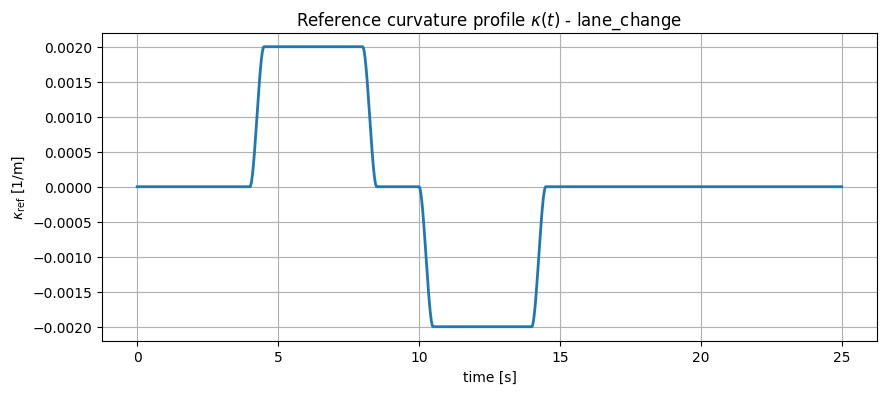

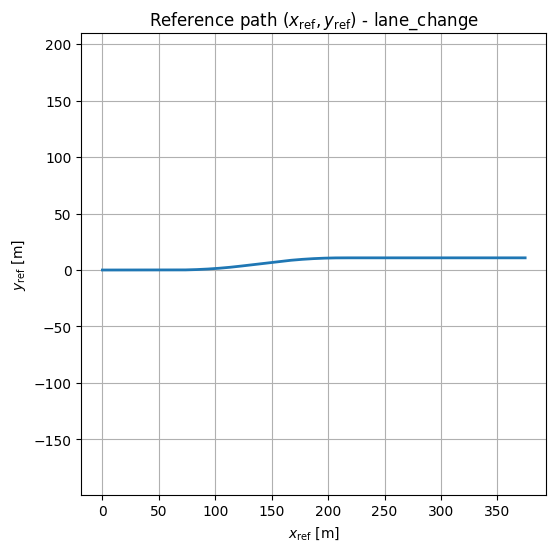

Reference generated:
- maneuver = lane_change
- saved: 01_kappa_profile.png, 01_reference_path_xy.png
- kappa max = 0.0020 1/m
- final (x_ref, y_ref) = (374.50, 10.78) m


In [3]:
# === 1) Reference generation from curvature kappa(t) ===

def smooth_step(t: np.ndarray, t0: float, t1: float) -> np.ndarray:
    """
    Smooth 0 -> 1 transition on [t0, t1] using a cubic smoothstep polynomial.
    """
    t = np.asarray(t, dtype=float)

    if t1 < t0:
        raise ValueError("t1 must be greater than or equal to t0.")

    denom = t1 - t0
    if abs(denom) < 1e-12:
        return (t >= t1).astype(float)

    s = np.clip((t - t0) / denom, 0.0, 1.0)
    return s**2 * (3.0 - 2.0 * s)


def pulse(t: np.ndarray, t_on: float, t_off: float, edge: float = 0.5) -> np.ndarray:
    """
    Smooth rectangular pulse that is approximately 1 on [t_on, t_off]
    with smooth rise and fall edges of width `edge`.
    """
    t = np.asarray(t, dtype=float)

    if edge <= 0:
        raise ValueError("edge must be positive.")
    if t_off < t_on:
        raise ValueError("t_off must be greater than or equal to t_on.")

    return smooth_step(t, t_on, t_on + edge) - smooth_step(t, t_off, t_off + edge)


def make_curvature_profile(
    t: np.ndarray,
    kind: str,
    *,
    kappa_max: float = 0.002,
) -> np.ndarray:
    """
    Construct a reference curvature profile kappa(t) [1/m].

    Supported maneuvers
    -------------------
    - "straight"
    - "lane_change"
    - "slalom"
    """
    t = np.asarray(t, dtype=float)

    if t.ndim != 1:
        raise ValueError("t must be a 1D array.")
    if kappa_max < 0:
        raise ValueError("kappa_max must be nonnegative.")

    if kind == "straight":
        return np.zeros_like(t, dtype=float)

    if kind == "lane_change":
        # Two opposite smooth pulses -> S-shaped path with near-zero final heading
        k1 = kappa_max * pulse(t, 4.0, 8.0, edge=0.5)
        k2 = -kappa_max * pulse(t, 10.0, 14.0, edge=0.5)
        return k1 + k2

    if kind == "slalom":
        f = 0.12  # Hz
        return kappa_max * np.sin(2.0 * np.pi * f * t)

    raise ValueError(f"Unknown maneuver kind: {kind!r}")


def integrate_reference_from_curvature(
    t: np.ndarray,
    kappa_ref: np.ndarray,
    Vx: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Integrate curvature to generate reference yaw rate, heading, and XY path.

    Returns
    -------
    r_ref : np.ndarray
        Reference yaw rate.
    psi_ref : np.ndarray
        Reference heading angle.
    x_ref : np.ndarray
        Reference x-position.
    y_ref : np.ndarray
        Reference y-position.
    """
    t = np.asarray(t, dtype=float)
    kappa_ref = np.asarray(kappa_ref, dtype=float)

    if t.ndim != 1 or kappa_ref.ndim != 1:
        raise ValueError("t and kappa_ref must be 1D arrays.")
    if len(t) != len(kappa_ref):
        raise ValueError("t and kappa_ref must have the same length.")
    if len(t) < 2:
        raise ValueError("t must contain at least two samples.")
    if Vx <= 0:
        raise ValueError("Vx must be positive.")

    dt_all = np.diff(t)
    if not np.allclose(dt_all, dt_all[0], atol=1e-12, rtol=0.0):
        raise ValueError("t must be uniformly sampled.")

    dt = float(dt_all[0])

    r_ref = Vx * kappa_ref
    psi_ref = np.zeros_like(t, dtype=float)
    x_ref = np.zeros_like(t, dtype=float)
    y_ref = np.zeros_like(t, dtype=float)

    # Forward-Euler cumulative integration
    psi_ref[1:] = np.cumsum(r_ref[:-1]) * dt
    x_ref[1:] = np.cumsum(Vx * np.cos(psi_ref[:-1])) * dt
    y_ref[1:] = np.cumsum(Vx * np.sin(psi_ref[:-1])) * dt

    return r_ref, psi_ref, x_ref, y_ref


# --- Generate time grid and a demo maneuver ---
t = np.arange(cfg.t0, cfg.tf + cfg.dt, cfg.dt)

maneuver = "lane_change"  # options: "straight", "lane_change", "slalom"
kappa_ref = make_curvature_profile(t, maneuver, kappa_max=0.002)
r_ref, psi_ref, x_ref, y_ref = integrate_reference_from_curvature(t, kappa_ref, cfg.Vx)

# --- Plot and save: curvature profile ---
fig1 = plt.figure(figsize=(10, 4))
plt.plot(t, kappa_ref, linewidth=2.0)
plt.xlabel("time [s]")
plt.ylabel(r"$\kappa_{\mathrm{ref}}$ [1/m]")
plt.title(rf"Reference curvature profile $\kappa(t)$ - {maneuver}")
plt.grid(True)
save_path1 = save_fig(fig1, "01_kappa_profile.png")
if "register_artifact" in globals():
    register_artifact(save_path1, "figure")
plt.show()
plt.close(fig1)

# --- Plot and save: XY reference path ---
fig2 = plt.figure(figsize=(6, 6))
plt.plot(x_ref, y_ref, linewidth=2.0)
plt.axis("equal")
plt.xlabel(r"$x_{\mathrm{ref}}$ [m]")
plt.ylabel(r"$y_{\mathrm{ref}}$ [m]")
plt.title(rf"Reference path $(x_{{\mathrm{{ref}}}}, y_{{\mathrm{{ref}}}})$ - {maneuver}")
plt.grid(True)
save_path2 = save_fig(fig2, "01_reference_path_xy.png")
if "register_artifact" in globals():
    register_artifact(save_path2, "figure")
plt.show()
plt.close(fig2)

print("Reference generated:")
print(f"- maneuver = {maneuver}")
print(f"- saved: {save_path1.name}, {save_path2.name}")
print(f"- kappa max = {np.max(np.abs(kappa_ref)):.4f} 1/m")
print(f"- final (x_ref, y_ref) = ({x_ref[-1]:.2f}, {y_ref[-1]:.2f}) m")

## 2) Ground-Truth Simulator: Dynamic Bicycle Model in Error Coordinates

We now implement the **ground-truth model** used to:

1. generate training, validation, and test rollouts, and  
2. evaluate controllers in closed loop.

We use a dynamic bicycle model with **linear tire forces** under the small-slip approximation, expressed in **road-aligned error coordinates**.

### State

$$
x =
\begin{bmatrix}
e_y \\
e_\psi \\
v_y \\
r
\end{bmatrix}
$$

where:

- $e_y$ is the lateral error relative to the reference path,
- $e_\psi$ is the heading error relative to the reference heading,
- $v_y$ is the lateral velocity,
- $r$ is the yaw rate.

### Input

The physical control input is the front steering angle

$$
u = \delta.
$$

### Exogenous / known signals

- $V_x$: longitudinal speed, treated as constant over each rollout in this notebook,
- $\kappa_{\mathrm{ref}}(t)$: reference curvature.

---

## Continuous-time dynamics

### Linear tire model

$$
F_{yf} = C_{af}\alpha_f,\qquad
F_{yr} = C_{ar}\alpha_r
$$

Using the small-angle slip approximations,

$$
\alpha_f \approx \delta - \frac{v_y + l_f r}{V_x},
\qquad
\alpha_r \approx -\frac{v_y - l_r r}{V_x},
$$

the lateral and yaw dynamics are

$$
\dot v_y = \frac{F_{yf}+F_{yr}}{m} - V_x r,
\qquad
\dot r = \frac{l_f F_{yf}-l_r F_{yr}}{I_z}.
$$

The road-aligned error kinematics are

$$
\dot e_y = v_y + V_x e_\psi,
\qquad
\dot e_\psi = r - V_x \kappa_{\mathrm{ref}}(t).
$$

**Numerical note:** in code, $V_x$ is clamped below by a small positive value such as $0.1$ m/s to avoid division by zero in the slip-angle formulas.

---

## Discretization

Using forward Euler with timestep $\Delta t$,

$$
x_{k+1} = x_k + \Delta t\,\dot x_k.
$$

---

## Deliverables

This section provides:

- `bike_step(x, delta, kappa_ref, Vx, cfg) -> x_next`
- `rollout_open_loop(x0, delta_seq, kappa_seq, Vx, cfg) -> X`

A quick sanity test is also included:

- open-loop rollout with $\delta(t)=0$ under the chosen reference curvature $\kappa_{\mathrm{ref}}(t)$.

Expected behavior: the heading error evolves during the maneuver and returns close to zero after the symmetric curvature pulses, while the lateral error grows because the vehicle does not steer to follow the curved reference.

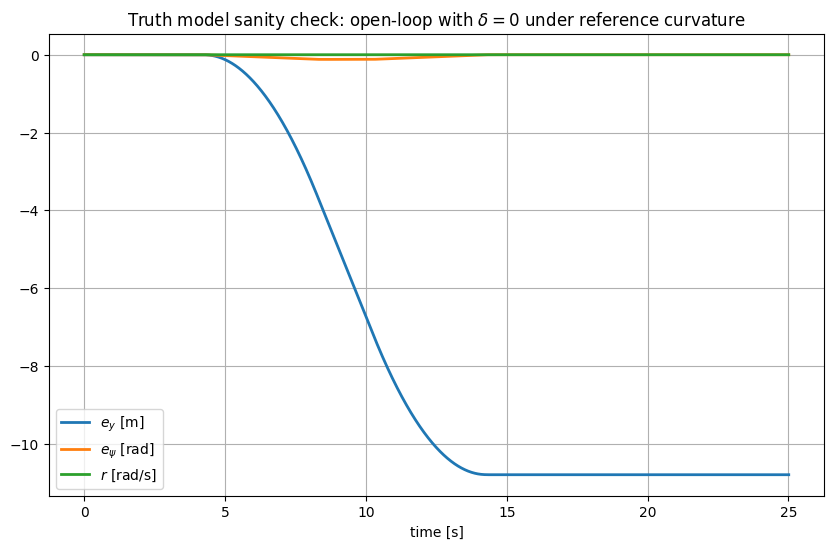

Truth model step + rollout ready.
- saved: 02_truthmodel_openloop_sanity.png
- final e_y = -10.800 m, final e_psi = -0.000 rad


In [4]:
# === 2) Ground-truth model: dynamic bicycle model in error coordinates ===

def bike_step(
    x: np.ndarray,
    delta: float,
    kappa_ref: float,
    Vx: float,
    cfg: CFG,
) -> np.ndarray:
    """
    One forward-Euler step of the dynamic bicycle model in road-aligned error coordinates.

    State
    -----
    x = [e_y, e_psi, v_y, r]

    Inputs
    ------
    delta     : front steering angle [rad]
    kappa_ref : reference curvature [1/m]
    Vx        : longitudinal speed [m/s]

    Returns
    -------
    x_next : np.ndarray of shape (4,)
        Next state after one timestep.
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.shape != (4,):
        raise ValueError("x must have shape (4,).")
    if not np.isfinite(delta):
        raise ValueError("delta must be finite.")
    if not np.isfinite(kappa_ref):
        raise ValueError("kappa_ref must be finite.")
    if not np.isfinite(Vx):
        raise ValueError("Vx must be finite.")

    ey, epsi, vy, r = x
    dt = float(cfg.dt)

    # Avoid division by zero in slip-angle calculations
    Vx_eff = max(0.1, float(Vx))

    # Small-angle slip approximations
    alpha_f = float(delta) - (vy + cfg.lf * r) / Vx_eff
    alpha_r = -(vy - cfg.lr * r) / Vx_eff

    # Linear tire forces
    Fyf = cfg.Caf * alpha_f
    Fyr = cfg.Car * alpha_r

    # Continuous-time bicycle dynamics
    vy_dot = (Fyf + Fyr) / cfg.m - Vx_eff * r
    r_dot = (cfg.lf * Fyf - cfg.lr * Fyr) / cfg.Iz

    # Road-aligned error kinematics
    ey_dot = vy + Vx_eff * epsi
    epsi_dot = r - Vx_eff * float(kappa_ref)

    x_dot = np.array([ey_dot, epsi_dot, vy_dot, r_dot], dtype=float)

    # Forward Euler step
    x_next = x + dt * x_dot
    return x_next


def rollout_open_loop(
    x0: np.ndarray,
    delta_seq: np.ndarray,
    kappa_seq: np.ndarray,
    Vx: float,
    cfg: CFG,
) -> np.ndarray:
    """
    Open-loop rollout for prescribed steering and curvature sequences.

    Parameters
    ----------
    x0 : np.ndarray of shape (4,)
        Initial state.
    delta_seq : np.ndarray of shape (T,)
        Steering sequence.
    kappa_seq : np.ndarray of shape (T,)
        Reference-curvature sequence.
    Vx : float
        Longitudinal speed [m/s].
    cfg : CFG
        Configuration object.

    Returns
    -------
    X : np.ndarray of shape (T + 1, 4)
        State trajectory.
    """
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    delta_seq = np.asarray(delta_seq, dtype=float).reshape(-1)
    kappa_seq = np.asarray(kappa_seq, dtype=float).reshape(-1)

    if x0.shape != (4,):
        raise ValueError("x0 must have shape (4,).")
    if len(delta_seq) != len(kappa_seq):
        raise ValueError("delta_seq and kappa_seq must have the same length.")
    if not np.isfinite(Vx):
        raise ValueError("Vx must be finite.")

    T = len(delta_seq)
    X = np.zeros((T + 1, 4), dtype=float)
    X[0] = x0

    for k in range(T):
        X[k + 1] = bike_step(X[k], delta_seq[k], kappa_seq[k], Vx, cfg)

    return X


# --- Quick sanity test: zero steering under the chosen reference curvature ---
x0 = np.zeros(4, dtype=float)
delta_seq = np.zeros_like(kappa_ref, dtype=float)
X_ol = rollout_open_loop(x0, delta_seq, kappa_ref, cfg.Vx, cfg)

# State-aligned time vector
t_state = np.arange(X_ol.shape[0], dtype=float) * cfg.dt

ey_ol = X_ol[:, 0]
epsi_ol = X_ol[:, 1]
r_ol = X_ol[:, 3]

fig = plt.figure(figsize=(10, 6))
plt.plot(t_state, ey_ol, label=r"$e_y$ [m]", linewidth=2.0)
plt.plot(t_state, epsi_ol, label=r"$e_\psi$ [rad]", linewidth=2.0)
plt.plot(t_state, r_ol, label=r"$r$ [rad/s]", linewidth=2.0)
plt.xlabel("time [s]")
plt.title(r"Truth model sanity check: open-loop with $\delta = 0$ under reference curvature")
plt.grid(True)
plt.legend()
save_path = save_fig(fig, "02_truthmodel_openloop_sanity.png")
if "register_artifact" in globals():
    register_artifact(save_path, "figure")
plt.show()
plt.close(fig)

print("Truth model step + rollout ready.")
print(f"- saved: {save_path.name}")
print(f"- final e_y = {ey_ol[-1]:.3f} m, final e_psi = {epsi_ol[-1]:.3f} rad")

## 3) Baseline Controller: Feedforward + LQR Feedback

Before introducing the learned predictive controller, we establish a strong classical baseline for comparison.

The baseline combines:

- **feedforward steering** $\delta_{ff}$ from a steady-state curvature-to-steering relation,
- **LQR state feedback** on the error state
  $$
  x = \begin{bmatrix} e_y & e_\psi & v_y & r \end{bmatrix}^T.
  $$

The desired yaw rate associated with the reference curvature is

$$
r_{\mathrm{ref}} = V_x \kappa_{\mathrm{ref}}.
$$

The feedforward term $\delta_{ff}$ is approximated using a wheelbase-based curvature-to-steer relation with an understeer-gradient correction.  
The feedback term is

$$
\delta_{fb} = -Kx,
$$

where $K$ is designed from a linearized bicycle model at a fixed operating speed $V_x$.

The total steering command is therefore

$$
\delta = \mathrm{sat}(\delta_{ff} + \delta_{fb}),
$$

with an additional discrete-time steering-rate constraint

$$
|\delta_k - \delta_{k-1}| \le \dot{\delta}_{\max}\Delta t.
$$

### Outputs

This section produces:

- closed-loop plots of $e_y$, $e_\psi$, and $\delta$,
- the saved figure `results/figures/03_baseline_lqr_closedloop.png`,
- and summary metrics for baseline tracking performance.

This controller serves as the main classical benchmark against which Koopman-MPC will be compared later.

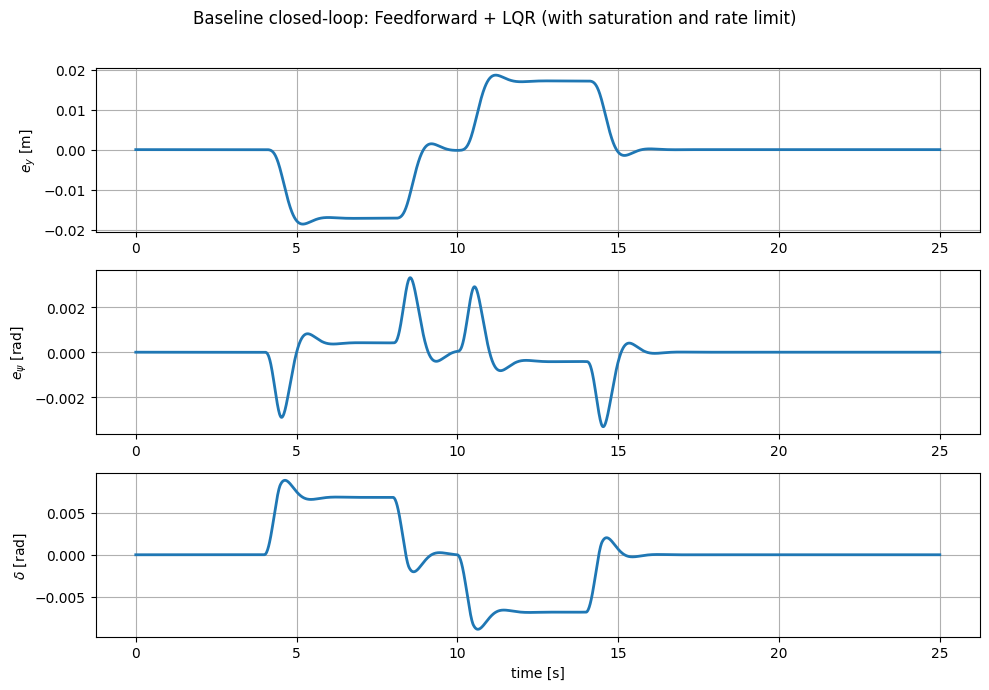

Baseline controller simulated.
- saved: 03_baseline_lqr_closedloop.png
- K_lqr = [[ 2.86879611 13.21151935  0.57880045  1.57672832]]
- RMS e_y = 0.010 m, max |e_y| = 0.019 m
- RMS e_psi = 0.0008 rad
- max |delta| = 0.009 rad


In [5]:
# === 3) Baseline controller: feedforward + LQR feedback ===

def clamp(x: float, lo: float, hi: float) -> float:
    return float(np.clip(x, lo, hi))


def rms(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x**2)))


def linear_bicycle_matrices(Vx: float, cfg: CFG) -> tuple[np.ndarray, np.ndarray]:
    """
    Continuous-time linear bicycle model for the error-state vector
    x = [e_y, e_psi, v_y, r].

    The reference curvature enters as an exogenous term in e_psi_dot and
    therefore does not appear directly in A or B.
    """
    if not np.isfinite(Vx):
        raise ValueError("Vx must be finite.")

    m, Iz = cfg.m, cfg.Iz
    lf, lr = cfg.lf, cfg.lr
    Caf, Car = cfg.Caf, cfg.Car
    Vx_eff = max(0.1, float(Vx))

    a11 = -(Caf + Car) / (m * Vx_eff)
    a12 = -(Caf * lf - Car * lr) / (m * Vx_eff) - Vx_eff
    a21 = -(Caf * lf - Car * lr) / (Iz * Vx_eff)
    a22 = -(Caf * lf**2 + Car * lr**2) / (Iz * Vx_eff)

    b1 = Caf / m
    b2 = Caf * lf / Iz

    A = np.zeros((4, 4), dtype=float)
    A[0, 1] = Vx_eff     # e_y_dot = v_y + Vx * e_psi
    A[0, 2] = 1.0
    A[1, 3] = 1.0        # e_psi_dot = r - Vx * kappa_ref
    A[2, 2] = a11
    A[2, 3] = a12
    A[3, 2] = a21
    A[3, 3] = a22

    B = np.zeros((4, 1), dtype=float)
    B[2, 0] = b1
    B[3, 0] = b2

    return A, B


def dlqr(
    A: np.ndarray,
    B: np.ndarray,
    Q: np.ndarray,
    R: np.ndarray,
    max_iter: int = 2000,
    tol: float = 1e-9,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Solve the discrete-time LQR problem via Riccati iteration.

    Returns
    -------
    K : np.ndarray
        Optimal feedback gain.
    P : np.ndarray
        Riccati solution matrix.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    Q = np.asarray(Q, dtype=float)
    R = np.asarray(R, dtype=float)

    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A must be square.")
    if B.ndim != 2 or B.shape[0] != A.shape[0]:
        raise ValueError("B must have compatible dimensions with A.")
    if Q.shape != A.shape:
        raise ValueError("Q must have the same shape as A.")
    if R.ndim != 2 or R.shape[0] != R.shape[1]:
        raise ValueError("R must be square.")

    Q = 0.5 * (Q + Q.T)
    R = 0.5 * (R + R.T)

    P = Q.copy()
    converged = False

    for _ in range(max_iter):
        BT_P = B.T @ P
        S = R + BT_P @ B
        K = np.linalg.solve(S, BT_P @ A)
        P_next = A.T @ P @ A - A.T @ P @ B @ K + Q

        if np.max(np.abs(P_next - P)) < tol:
            P = P_next
            converged = True
            break

        P = P_next

    if not converged:
        print("Warning: dlqr Riccati iteration reached max_iter without strict convergence.")

    BT_P = B.T @ P
    S = R + BT_P @ B
    K = np.linalg.solve(S, BT_P @ A)

    return K, P


def discretize_euler(Ac: np.ndarray, Bc: np.ndarray, dt: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Forward-Euler discretization of continuous-time linear dynamics.
    """
    if dt <= 0:
        raise ValueError("dt must be positive.")

    Ac = np.asarray(Ac, dtype=float)
    Bc = np.asarray(Bc, dtype=float)

    Ad = np.eye(Ac.shape[0]) + dt * Ac
    Bd = dt * Bc
    return Ad, Bd


def steer_feedforward_from_curvature(kappa: float, Vx: float, cfg: CFG) -> float:
    """
    Practical curvature-to-steering feedforward relation:

        delta_ff = L * kappa + K_us * Vx^2 * kappa

    where K_us is an approximate understeer gradient.
    """
    if not np.isfinite(kappa) or not np.isfinite(Vx):
        raise ValueError("kappa and Vx must be finite.")

    m, lf, lr = cfg.m, cfg.lf, cfg.lr
    Caf, Car = cfg.Caf, cfg.Car
    L = cfg.L

    Kus = (m * (lr / Car - lf / Caf)) / L
    return float((L * kappa) + (Kus * Vx**2 * kappa))


def simulate_baseline_lqr(
    x0: np.ndarray,
    kappa_ref: np.ndarray,
    Vx: float,
    cfg: CFG,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Closed-loop simulation of feedforward + LQR steering.

    Returns
    -------
    X : np.ndarray, shape (T + 1, 4)
        State trajectory.
    U : np.ndarray, shape (T,)
        Steering trajectory.
    K : np.ndarray, shape (1, 4)
        LQR feedback gain.
    """
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    kappa_ref = np.asarray(kappa_ref, dtype=float).reshape(-1)

    if x0.shape != (4,):
        raise ValueError("x0 must have shape (4,).")
    if not np.isfinite(Vx):
        raise ValueError("Vx must be finite.")

    T = len(kappa_ref)
    X = np.zeros((T + 1, 4), dtype=float)
    U = np.zeros(T, dtype=float)
    X[0] = x0

    # Linear model for LQR design
    Ac, Bc = linear_bicycle_matrices(Vx, cfg)
    Ad, Bd = discretize_euler(Ac, Bc, cfg.dt)

    # LQR weights
    Q = np.diag([cfg.q_ey, cfg.q_epsi, cfg.q_vy, cfg.q_r])
    R = np.array([[cfg.r_delta]], dtype=float)
    K, _ = dlqr(Ad, Bd, Q, R)

    delta_prev = 0.0
    max_step = cfg.delta_rate_max * cfg.dt

    for k in range(T):
        xk = X[k]

        delta_ff = steer_feedforward_from_curvature(kappa_ref[k], Vx, cfg)
        delta_fb = -(K @ xk.reshape(-1, 1)).item()
        delta_cmd = delta_ff + delta_fb

        # Steering magnitude saturation
        delta_cmd = clamp(delta_cmd, -cfg.delta_max, cfg.delta_max)

        # Steering-rate limit
        delta_cmd = clamp(delta_cmd, delta_prev - max_step, delta_prev + max_step)

        U[k] = delta_cmd
        X[k + 1] = bike_step(xk, delta_cmd, kappa_ref[k], Vx, cfg)
        delta_prev = delta_cmd

    return X, U, K


# --- Run baseline on the current reference maneuver ---
X_cl, U_cl, K_lqr = simulate_baseline_lqr(np.zeros(4), kappa_ref, cfg.Vx, cfg)

ey = X_cl[:-1, 0]
epsi = X_cl[:-1, 1]

fig = plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(t, ey, linewidth=2.0)
plt.ylabel(r"$e_y$ [m]")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, epsi, linewidth=2.0)
plt.ylabel(r"$e_\psi$ [rad]")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, U_cl, linewidth=2.0)
plt.ylabel(r"$\delta$ [rad]")
plt.xlabel("time [s]")
plt.grid(True)

plt.suptitle("Baseline closed-loop: Feedforward + LQR (with saturation and rate limit)")
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_path = save_fig(fig, "03_baseline_lqr_closedloop.png")
if "register_artifact" in globals():
    register_artifact(save_path, "figure")
plt.show()
plt.close(fig)

print("Baseline controller simulated.")
print(f"- saved: {save_path.name}")
print(f"- K_lqr = {K_lqr}")
print(f"- RMS e_y = {rms(ey):.3f} m, max |e_y| = {np.max(np.abs(ey)):.3f} m")
print(f"- RMS e_psi = {rms(epsi):.4f} rad")
print(f"- max |delta| = {np.max(np.abs(U_cl)):.3f} rad")

## 4) Data Generation for Koopman/EDMD (Train/Val/Test by Trajectory)

The quality of Koopman/EDMD depends strongly on the richness and diversity of the training data.

In this section, we generate a dataset of **open-loop rollouts** from the ground-truth model using **persistently exciting steering inputs**. The goal is not path tracking, but broad state-space coverage for system identification.

The excitation design includes:

- multi-sine steering mixtures,
- randomized phase and frequency content,
- bounded steering amplitude,
- bounded steering-rate profiles,
- and multiple maneuver types such as `straight`, `lane_change`, and `slalom`.

To avoid information leakage, the dataset is split **by trajectory**, not by individual samples.

### Dataset format

For each rollout, we store:

- `X`: state trajectory with shape `(T+1, 4)` for
  $$
  x = [e_y,\ e_\psi,\ v_y,\ r]
  $$
- `U`: steering input sequence with shape `(T, 1)` for steering angle $\delta$
- `K`: reference-curvature sequence with shape `(T,)` for $\kappa_{\mathrm{ref}}(t)$

The curvature signal is later combined with steering to form the augmented EDMD input

$$
u_k =
\begin{bmatrix}
\delta_k \\
\kappa_{\mathrm{ref},k}
\end{bmatrix},
$$

so that the learned predictor can account for changing references.

### Outputs

This section produces:

- a dataset saved to `results/data/edmd_dataset.npz`,
- train/validation/test trajectory indices,
- and an example trajectory plot saved to `results/figures/04_dataset_example.png`.

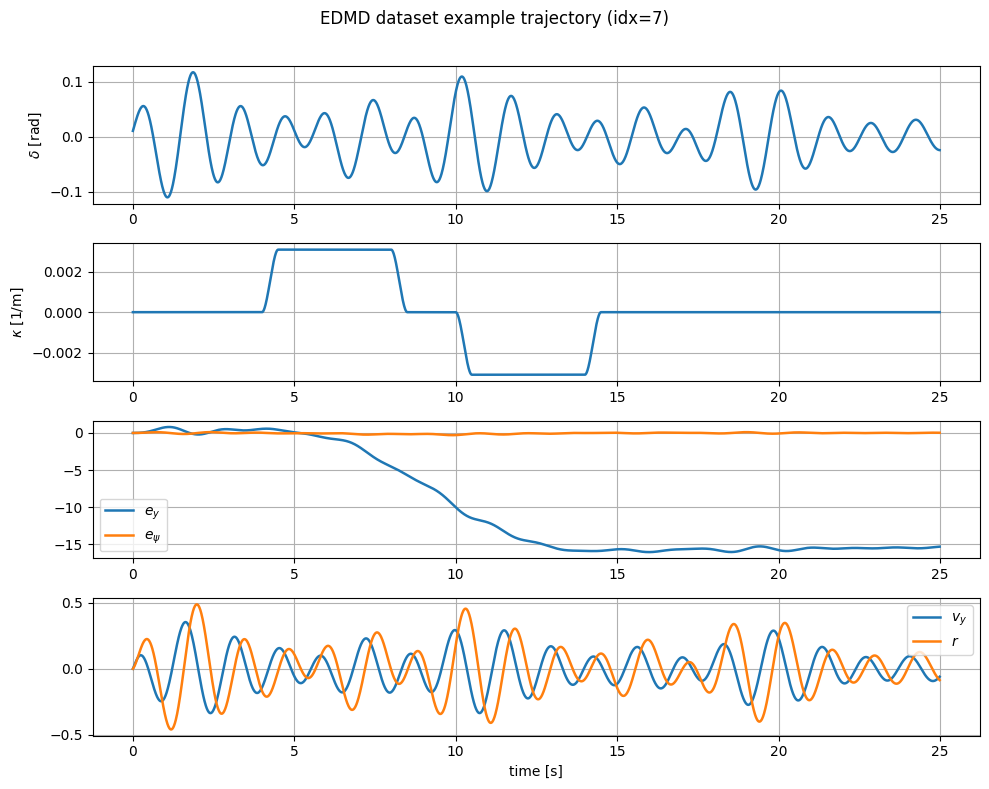

EDMD dataset created.
- saved: C:\Users\sansk\OneDrive\Documents\GitHub\koopman-mpc-lateral-control\notebooks\results\data\edmd_dataset.npz
- trajectories: 30 (train=21, val=4, test=5)
- example saved plot: 04_dataset_example.png


In [6]:
# === 4) Data generation for EDMD ===
# Assumes already defined:
#   cfg, SEED, rng, DIRS
#   make_curvature_profile, rollout_open_loop

def gen_pe_steering(
    t_state: np.ndarray,
    rng: np.random.Generator,
    amp: float = 0.12,
    n_sines: int = 6,
    fmin: float = 0.05,
    fmax: float = 0.8,
) -> np.ndarray:
    """
    Generate a persistently exciting steering signal on the state time grid.

    Parameters
    ----------
    t_state : np.ndarray
        State-aligned time grid of shape (T+1,).
    rng : np.random.Generator
        Random number generator.
    amp : float
        Steering amplitude limit before rate limiting.
    n_sines : int
        Number of sine components.
    fmin, fmax : float
        Minimum and maximum excitation frequencies [Hz].

    Returns
    -------
    u_state : np.ndarray
        Steering sequence on the state grid, shape (T+1,).
    """
    t_state = np.asarray(t_state, dtype=float).reshape(-1)

    if t_state.ndim != 1 or len(t_state) < 2:
        raise ValueError("t_state must be a 1D array with at least two samples.")
    if amp < 0:
        raise ValueError("amp must be nonnegative.")
    if n_sines < 1:
        raise ValueError("n_sines must be at least 1.")
    if fmin <= 0 or fmax < fmin:
        raise ValueError("Require 0 < fmin <= fmax.")

    u = np.zeros_like(t_state, dtype=float)

    freqs = rng.uniform(fmin, fmax, size=n_sines)
    phases = rng.uniform(0.0, 2.0 * np.pi, size=n_sines)
    weights = rng.uniform(0.2, 1.0, size=n_sines)
    weights = weights / (np.sum(weights) + 1e-12)

    for w, f, ph in zip(weights, freqs, phases):
        u += w * np.sin(2.0 * np.pi * f * t_state + ph)

    # Normalize and scale
    u = u / (np.max(np.abs(u)) + 1e-12)
    u = amp * u

    # Mild first-order smoothing
    alpha = 0.05
    for k in range(1, len(u)):
        u[k] = (1.0 - alpha) * u[k] + alpha * u[k - 1]

    return u


def apply_rate_limit(u: np.ndarray, dt: float, rate_max: float) -> np.ndarray:
    """
    Enforce |u[k] - u[k-1]| <= rate_max * dt.
    """
    u = np.asarray(u, dtype=float).reshape(-1)

    if dt <= 0:
        raise ValueError("dt must be positive.")
    if rate_max < 0:
        raise ValueError("rate_max must be nonnegative.")

    u_rl = u.copy()
    max_step = float(rate_max) * float(dt)

    for k in range(1, len(u_rl)):
        u_rl[k] = float(np.clip(u_rl[k], u_rl[k - 1] - max_step, u_rl[k - 1] + max_step))

    return u_rl


def make_rollout(
    t_state: np.ndarray,
    cfg: CFG,
    rng: np.random.Generator,
    maneuver_kind: str,
    kappa_max: float,
    steer_amp: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Create one open-loop identification rollout.

    Returns
    -------
    X : np.ndarray, shape (T+1, 4)
        State trajectory.
    U : np.ndarray, shape (T, 1)
        Steering sequence.
    K : np.ndarray, shape (T,)
        Curvature sequence.
    """
    if steer_amp < 0:
        raise ValueError("steer_amp must be nonnegative.")
    if kappa_max < 0:
        raise ValueError("kappa_max must be nonnegative.")

    # Curvature on state grid (T+1), then convert to step-aligned sequence (T,)
    kappa_state = make_curvature_profile(t_state, maneuver_kind, kappa_max=kappa_max)
    kappa_seq = kappa_state[:-1]

    # Steering on state grid (T+1), then convert to step-aligned sequence (T,)
    delta_state = gen_pe_steering(t_state, rng, amp=steer_amp)
    delta_state = apply_rate_limit(delta_state, cfg.dt, cfg.delta_rate_max)
    delta_state = np.clip(delta_state, -cfg.delta_max, cfg.delta_max)
    delta_seq = delta_state[:-1]

    X = rollout_open_loop(np.zeros(4, dtype=float), delta_seq, kappa_seq, cfg.Vx, cfg)
    U = delta_seq.reshape(-1, 1)

    return X, U, kappa_seq


def save_dataset_npz(name: str, **arrays) -> Path:
    path = DIRS["data"] / name
    np.savez(path, **arrays)
    return path


# -------------------------
# Time grid (state-aligned): length T+1
# -------------------------
t = np.arange(cfg.t0, cfg.tf + cfg.dt, cfg.dt)

# -------------------------
# Create trajectories
# -------------------------
n_traj = 30
Xs, Us, Ks = [], [], []
traj_cfgs = []

maneuvers = ["straight", "lane_change", "slalom"]

for i in range(n_traj):
    kind = maneuvers[i % len(maneuvers)]
    kappa_max_i = rng.uniform(0.0, 0.006) if kind != "straight" else 0.0
    steer_amp_i = rng.uniform(0.05, 0.18)

    X_i, U_i, K_i = make_rollout(
        t_state=t,
        cfg=cfg,
        rng=rng,
        maneuver_kind=kind,
        kappa_max=kappa_max_i,
        steer_amp=steer_amp_i,
    )

    Xs.append(X_i)
    Us.append(U_i)
    Ks.append(K_i)
    traj_cfgs.append(
        {
            "kind": kind,
            "kappa_max": float(kappa_max_i),
            "steer_amp": float(steer_amp_i),
            "Vx": float(cfg.Vx),
        }
    )

# -------------------------
# Train/val/test split by trajectory
# -------------------------
idx = np.arange(n_traj)
rng.shuffle(idx)

n_train = int(0.70 * n_traj)
n_val = int(0.15 * n_traj)
n_test = n_traj - n_train - n_val

train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

assert len(train_idx) + len(val_idx) + len(test_idx) == n_traj

# -------------------------
# Save dataset
# -------------------------
dataset_path = save_dataset_npz(
    "edmd_dataset.npz",
    X=np.array(Xs, dtype=object),
    U=np.array(Us, dtype=object),
    K=np.array(Ks, dtype=object),
    Xs=np.array(Xs, dtype=object),
    Us=np.array(Us, dtype=object),
    Ks=np.array(Ks, dtype=object),
    traj_cfgs=np.array(traj_cfgs, dtype=object),
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    t=t,
    cfg=asdict(cfg),
    seed=SEED,
)
if "register_artifact" in globals():
    register_artifact(dataset_path, "data")

# -------------------------
# Example trajectory plot
# -------------------------
ex = int(train_idx[0])
X_ex = Xs[ex]
U_ex = Us[ex].reshape(-1)
K_ex = Ks[ex]

fig = plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(t[:-1], U_ex, linewidth=1.8)
plt.ylabel(r"$\delta$ [rad]")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t[:-1], K_ex, linewidth=1.8)
plt.ylabel(r"$\kappa$ [1/m]")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t[:-1], X_ex[:-1, 0], label=r"$e_y$", linewidth=1.8)
plt.plot(t[:-1], X_ex[:-1, 1], label=r"$e_\psi$", linewidth=1.8)
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t[:-1], X_ex[:-1, 2], label=r"$v_y$", linewidth=1.8)
plt.plot(t[:-1], X_ex[:-1, 3], label=r"$r$", linewidth=1.8)
plt.legend()
plt.grid(True)
plt.xlabel("time [s]")

plt.suptitle(f"EDMD dataset example trajectory (idx={ex})")
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_path = save_fig(fig, "04_dataset_example.png")
if "register_artifact" in globals():
    register_artifact(save_path, "figure")
plt.show()
plt.close(fig)

print("EDMD dataset created.")
print(f"- saved: {dataset_path}")
print(f"- trajectories: {n_traj} (train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)})")
print(f"- example saved plot: {save_path.name}")

## 5) Koopman / EDMD Identification (Learn Lifted Linear Model)

We learn a linear predictor in a **lifted observable space**. Starting from nonlinear discrete-time dynamics,
$$
x_{k+1} = F(x_k, u_k),
$$
we define a lifting map (dictionary of observables)
$$
z_k = \psi(x_k),
$$
and approximate the lifted dynamics as linear:
$$
z_{k+1} \approx A z_k + B u_k.
$$

---

### Inputs (augmented control)

We include both steering and reference curvature as inputs:
$$
u_k =
\begin{bmatrix}
\delta_k \\
\kappa_{\text{ref},k}
\end{bmatrix}.
$$

This matters because the true continuous-time error dynamics contain curvature as an exogenous term:
$$
\dot e_\psi = r - V_x\,\kappa_{\text{ref}}(t),
$$
so providing $\kappa_{\text{ref},k}$ improves prediction under changing references.

---

### Outputs / reconstruction (state is embedded in the lift)

Our dictionary $\psi(x)$ explicitly includes the physical state components $[e_y,\ e_\psi,\ v_y,\ r]$ as entries of $z$, for example
$$
z = [1,\ e_y,\ e_\psi,\ v_y,\ r,\ \ldots]^\top.
$$

Therefore, we reconstruct the state using a **fixed selector**:
$$
x_k =
\begin{bmatrix}
e_y \\
e_\psi \\
v_y \\
r
\end{bmatrix}
=
C_{\text{sel}}\,z_k.
$$

No learned reconstruction is required.

---

### EDMD model fit in standardized lifted coordinates

For numerical conditioning, we learn EDMD in standardized coordinates:
$$
z_s = \frac{z-\mu_z}{\sigma_z}, \qquad
u_s = \frac{u-\mu_u}{\sigma_u},
$$
and fit
$$
z_{s,k+1} \approx A\,z_{s,k} + B\,u_{s,k}.
$$

We solve the ridge regression problem:
$$
\min_{A,B}\left\|Z_{s,+} - [A\;B]\begin{bmatrix}Z_s\\U_s\end{bmatrix}\right\|_F^2
+ \lambda\left\|[A\;B]\right\|_F^2.
$$

During prediction:
1. lift $x_k \mapsto z_k = \psi(x_k)$  
2. scale $z_k \mapsto z_{s,k}$ and $u_k \mapsto u_{s,k}$  
3. propagate $z_{s,k+1} = A z_{s,k} + B u_{s,k}$  
4. unscale $z_{k+1} = z_{s,k+1}\odot\sigma_z + \mu_z$  
5. reconstruct $x_{k+1} = C_{\text{sel}}\,z_{k+1}$

---

### What we check in this section

1. fit $A$ and $B$ on training trajectories  
2. report **raw 1-step validation RMSE** on validation trajectories  
3. report the **mean prediction error (bias)** as a diagnostic  
4. report the **zero-mean 1-step RMSE** after removing bias  
5. visualize both the **raw error distribution** and the **zero-mean residual distribution** for \(e_y\)  
6. save $(A,B)$, scalers $(\mu_z,\sigma_z,\mu_u,\sigma_u)$, and $C_{\text{sel}}$ to `results/models/edmd_model.npz`

The **raw validation RMSE** is the main predictive metric in this section.  
The zero-mean residuals are shown separately to visualize the spread of the error distribution after removing any constant bias.

EDMD model learned.
- saved: edmd_model.npz
- lift dimension n_z = 17
- validation 1-step RMSE (raw) [e_y, e_psi, v_y, r] = [1.58832497e-09 7.36823305e-10 2.74330040e-12 2.39963748e-11]
- validation error mean (bias) [e_y, e_psi, v_y, r] = [5.14785587e-10 1.49386187e-10 1.37909426e-13 7.61638143e-13]
- validation 1-step RMSE (zero-mean) [e_y, e_psi, v_y, r] = [1.50258844e-09 7.21520859e-10 2.73983176e-12 2.39842847e-11]
- metrics table saved: 05_edmd_val_onestep_metrics.csv


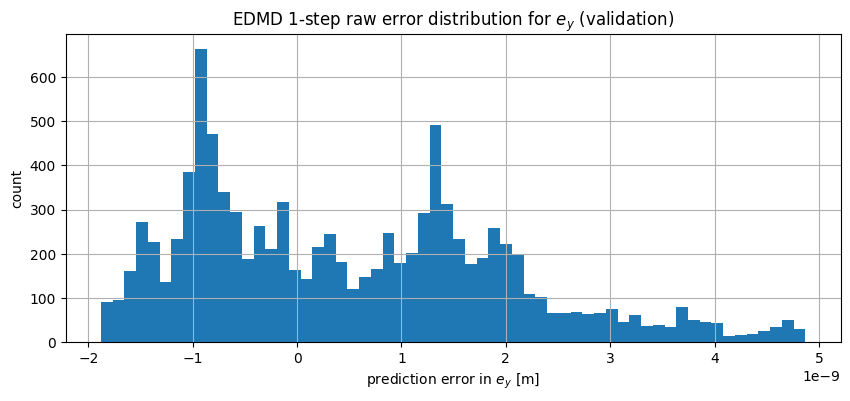

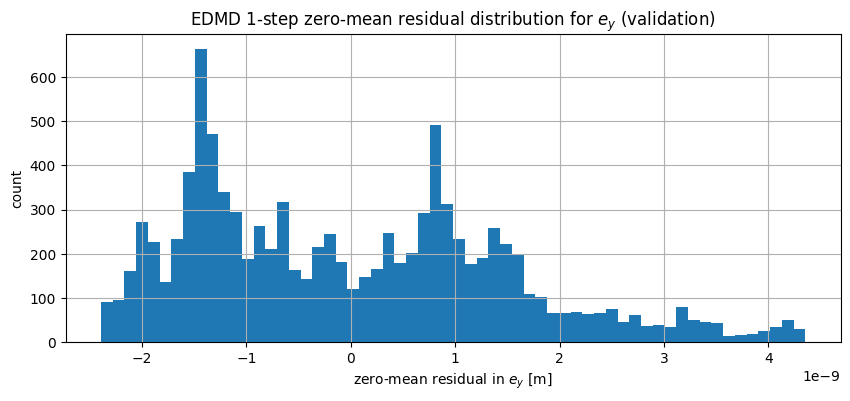

- saved: 05_edmd_val_onestep_error_hist_ey_raw.png
- saved: 05_edmd_val_onestep_error_hist_ey_zeromean.png


In [8]:
# === 5) Koopman / EDMD identification in standardized lifted coordinates ===
# Assumes already defined:
#   Xs, Us, Ks, train_idx, val_idx
#   save_npz, save_fig, save_csv

from matplotlib.ticker import ScalarFormatter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# -------------------------
# 1) Lifting dictionary psi(x)
# -------------------------
def lift_features(x: np.ndarray) -> np.ndarray:
    """
    Lift the physical state x = [e_y, e_psi, v_y, r] into an observable vector z.
    The physical states are embedded explicitly so that reconstruction is exact.
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.shape != (4,):
        raise ValueError("lift_features expects x with shape (4,).")

    ey, epsi, vy, r = x

    z = np.array(
        [
            1.0,               # bias term
            ey, epsi, vy, r,   # physical states embedded in z
            ey**2, epsi**2, vy**2, r**2,
            ey * epsi, ey * vy, ey * r,
            epsi * vy, epsi * r, vy * r,
            np.sin(epsi), np.cos(epsi),
        ],
        dtype=float,
    )
    return z


n_z = len(lift_features(np.zeros(4, dtype=float)))

# Exact selector: x = C_sel z
C_sel = np.zeros((4, n_z), dtype=float)
C_sel[0, 1] = 1.0  # e_y
C_sel[1, 2] = 1.0  # e_psi
C_sel[2, 3] = 1.0  # v_y
C_sel[3, 4] = 1.0  # r


# -------------------------
# 2) Build stacked EDMD matrices
# -------------------------
def build_edmd_matrices(
    X_list,
    U_list,
    K_list,
    indices,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build stacked matrices for EDMD.

    Returns
    -------
    Z   : (n_z, N)  lifted current states
    Zp  : (n_z, N)  lifted next states
    U   : (2, N)    augmented inputs [delta, kappa_ref]
    """
    Z_cols, Zp_cols, U_cols = [], [], []

    for idx in indices:
        X = np.asarray(X_list[idx], dtype=float)
        U = np.asarray(U_list[idx], dtype=float)
        K = np.asarray(K_list[idx], dtype=float).reshape(-1)

        if X.ndim != 2 or X.shape[1] != 4:
            raise ValueError(f"Trajectory X at idx={idx} must have shape (T+1, 4).")
        if U.ndim != 2 or U.shape[1] != 1:
            raise ValueError(f"Trajectory U at idx={idx} must have shape (T, 1).")
        if len(K) != U.shape[0]:
            raise ValueError(f"K at idx={idx} must have length equal to len(U).")
        if X.shape[0] != U.shape[0] + 1:
            raise ValueError(f"X at idx={idx} must have one more row than U.")

        T = U.shape[0]
        for k in range(T):
            Z_cols.append(lift_features(X[k]))
            Zp_cols.append(lift_features(X[k + 1]))
            U_cols.append([U[k, 0], K[k]])

    if not Z_cols:
        raise ValueError("No EDMD samples were built. Check indices and dataset contents.")

    Z = np.stack(Z_cols, axis=1)
    Zp = np.stack(Zp_cols, axis=1)
    Umat = np.asarray(U_cols, dtype=float).T

    return Z, Zp, Umat


def row_stats(M: np.ndarray, eps: float = 1e-9) -> tuple[np.ndarray, np.ndarray]:
    """
    Row-wise mean and std for standardization.

    Important:
    - The first row is the constant bias feature and is intentionally NOT standardized.
      We keep mu=0 and sig=1 there so the affine capability is preserved.
    """
    M = np.asarray(M, dtype=float)
    if M.ndim != 2:
        raise ValueError("row_stats expects a 2D array.")

    mu = np.mean(M, axis=1, keepdims=True)
    sig = np.std(M, axis=1, keepdims=True)
    sig = np.maximum(sig, eps)

    # Preserve constant bias feature exactly
    mu[0, 0] = 0.0
    sig[0, 0] = 1.0

    return mu, sig


def row_stats_input(M: np.ndarray, eps: float = 1e-9) -> tuple[np.ndarray, np.ndarray]:
    """
    Row-wise mean and std for input standardization.
    """
    M = np.asarray(M, dtype=float)
    if M.ndim != 2:
        raise ValueError("row_stats_input expects a 2D array.")

    mu = np.mean(M, axis=1, keepdims=True)
    sig = np.std(M, axis=1, keepdims=True)
    sig = np.maximum(sig, eps)
    return mu, sig


def standardize(M: np.ndarray, mu: np.ndarray, sig: np.ndarray) -> np.ndarray:
    return (M - mu) / sig


def unstandardize(Ms: np.ndarray, mu: np.ndarray, sig: np.ndarray) -> np.ndarray:
    return Ms * sig + mu


# -------------------------
# 3) Ridge EDMD in standardized coordinates
# -------------------------
def ridge_edmd(
    Z: np.ndarray,
    Zp: np.ndarray,
    U: np.ndarray,
    lam: float = 1e-6,
) -> tuple[np.ndarray, np.ndarray, dict]:
    """
    Fit EDMD in standardized lifted coordinates using ridge regression.

    Solves:
        Zp_s ≈ [A B] [Z_s; U_s]
    """
    if lam < 0:
        raise ValueError("lam must be nonnegative.")
    if Z.ndim != 2 or Zp.ndim != 2 or U.ndim != 2:
        raise ValueError("Z, Zp, and U must be 2D arrays.")
    if Z.shape != Zp.shape:
        raise ValueError("Z and Zp must have the same shape.")
    if Z.shape[1] != U.shape[1]:
        raise ValueError("Z and U must have the same number of samples.")

    # Preserve the constant bias feature in Z/Zp scaling
    mu_z, sig_z = row_stats(Z)
    mu_u, sig_u = row_stats_input(U)

    Zs = standardize(Z, mu_z, sig_z)
    Zps = standardize(Zp, mu_z, sig_z)
    Us = standardize(U, mu_u, sig_u)

    Xreg = np.vstack([Zs, Us])   # (n_z + 2, N)
    Yreg = Zps                   # (n_z, N)

    G = Xreg @ Xreg.T
    rhs = Yreg @ Xreg.T
    reg = G + lam * np.eye(G.shape[0], dtype=float)

    # Numerically safer solve
    W = np.linalg.solve(reg.T, rhs.T).T

    A = W[:, :n_z]
    B = W[:, n_z:]

    scaler = {
        "mu_z": mu_z,
        "sig_z": sig_z,
        "mu_u": mu_u,
        "sig_u": sig_u,
    }
    return A, B, scaler


# -------------------------
# 4) One-step validation + metrics
# -------------------------
def one_step_predictions_and_errors(
    X_list,
    U_list,
    K_list,
    indices,
    A: np.ndarray,
    B: np.ndarray,
    scaler: dict,
    C: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute one-step predictions and errors in physical coordinates.

    Returns
    -------
    Y_true : (N, 4)
        True next states.
    Y_pred : (N, 4)
        Predicted next states.
    E : (N, 4)
        Prediction error = Y_pred - Y_true.
    """
    mu_z, sig_z = scaler["mu_z"], scaler["sig_z"]
    mu_u, sig_u = scaler["mu_u"], scaler["sig_u"]

    y_true_list = []
    y_pred_list = []
    err_list = []

    for idx in indices:
        X = np.asarray(X_list[idx], dtype=float)
        U = np.asarray(U_list[idx], dtype=float)
        K = np.asarray(K_list[idx], dtype=float).reshape(-1)

        T = U.shape[0]
        if X.shape[0] != T + 1:
            raise ValueError(f"Validation trajectory X at idx={idx} must have length T+1.")

        for k in range(T):
            zk = lift_features(X[k]).reshape(-1, 1)
            uk = np.array([U[k, 0], K[k]], dtype=float).reshape(-1, 1)

            zks = standardize(zk, mu_z, sig_z)
            uks = standardize(uk, mu_u, sig_u)

            zkps = A @ zks + B @ uks
            zkp = unstandardize(zkps, mu_z, sig_z)

            x_true = X[k + 1]
            x_pred = (C @ zkp).ravel()
            err = x_pred - x_true

            y_true_list.append(x_true)
            y_pred_list.append(x_pred)
            err_list.append(err)

    if not err_list:
        raise ValueError("No validation errors were computed. Check val_idx.")

    Y_true = np.asarray(y_true_list, dtype=float)
    Y_pred = np.asarray(y_pred_list, dtype=float)
    E = np.asarray(err_list, dtype=float)
    return Y_true, Y_pred, E


def rmse_per_state(E: np.ndarray) -> np.ndarray:
    E = np.asarray(E, dtype=float)
    if E.ndim != 2:
        raise ValueError("rmse_per_state expects a 2D array.")
    return np.sqrt(np.mean(E**2, axis=0))


# -------------------------
# 5) Fit + validate + save
# -------------------------
Ztr, Zptr, Utr = build_edmd_matrices(Xs, Us, Ks, train_idx)

lam = 1e-6
A_edmd, B_edmd, scaler = ridge_edmd(Ztr, Zptr, Utr, lam=lam)

Y_val_true, Y_val_pred, E_val = one_step_predictions_and_errors(
    Xs, Us, Ks, val_idx, A_edmd, B_edmd, scaler, C_sel
)

rmse_raw = rmse_per_state(E_val)
bias_mean = np.mean(E_val, axis=0)
E_val_zm = E_val - bias_mean
rmse_zm = rmse_per_state(E_val_zm)

state_names = ["e_y", "e_psi", "v_y", "r"]
metrics_df = pd.DataFrame({
    "state": state_names,
    "rmse_raw": rmse_raw,
    "bias_mean": bias_mean,
    "rmse_zero_mean": rmse_zm,
})

metrics_path = save_csv(metrics_df, "05_edmd_val_onestep_metrics.csv")
if "register_artifact" in globals():
    register_artifact(metrics_path, "table")

model_path = save_npz(
    "edmd_model.npz",
    A=A_edmd,
    B=B_edmd,
    lam=np.array([lam], dtype=float),
    mu_z=scaler["mu_z"],
    sig_z=scaler["sig_z"],
    mu_u=scaler["mu_u"],
    sig_u=scaler["sig_u"],
    C_sel=C_sel,
    C=C_sel,
)
if "register_artifact" in globals():
    register_artifact(model_path, "model")

print("EDMD model learned.")
print(f"- saved: {model_path.name}")
print(f"- lift dimension n_z = {A_edmd.shape[0]}")
print(f"- validation 1-step RMSE (raw) [e_y, e_psi, v_y, r] = {rmse_raw}")
print(f"- validation error mean (bias) [e_y, e_psi, v_y, r] = {bias_mean}")
print(f"- validation 1-step RMSE (zero-mean) [e_y, e_psi, v_y, r] = {rmse_zm}")
print(f"- metrics table saved: {metrics_path.name}")

# -------------------------
# 6) Validation plots
# -------------------------
fig = plt.figure(figsize=(10, 4))
plt.hist(E_val[:, 0], bins=60)
plt.title(r"EDMD 1-step raw error distribution for $e_y$ (validation)")
plt.xlabel(r"prediction error in $e_y$ [m]")
plt.ylabel("count")
plt.grid(True)

ax = plt.gca()
fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(True)
ax.xaxis.set_major_formatter(fmt)

save_path_raw = save_fig(fig, "05_edmd_val_onestep_error_hist_ey_raw.png")
if "register_artifact" in globals():
    register_artifact(save_path_raw, "figure")
plt.show()
plt.close(fig)

fig = plt.figure(figsize=(10, 4))
plt.hist(E_val_zm[:, 0], bins=60)
plt.title(r"EDMD 1-step zero-mean residual distribution for $e_y$ (validation)")
plt.xlabel(r"zero-mean residual in $e_y$ [m]")
plt.ylabel("count")
plt.grid(True)

ax = plt.gca()
fmt = ScalarFormatter(useOffset=False)
fmt.set_scientific(True)
ax.xaxis.set_major_formatter(fmt)

save_path_zm = save_fig(fig, "05_edmd_val_onestep_error_hist_ey_zeromean.png")
if "register_artifact" in globals():
    register_artifact(save_path_zm, "figure")
plt.show()
plt.close(fig)

print(f"- saved: {save_path_raw.name}")
print(f"- saved: {save_path_zm.name}")

The raw one-step validation errors are extremely small and show negligible mean bias, indicating that the lifted linear EDMD model captures the local one-step dynamics of the simulated system very accurately in this operating regime. Because the dataset is simulation-based and noise-free, one-step accuracy alone is not sufficient; later sections therefore evaluate multi-step rollout behavior and closed-loop control performance.

## 6) Multi-step Open-loop Prediction (Truth vs EDMD)

One-step error can be misleading: a model may look accurate over a single step but still drift when rolled out over a longer horizon.

Here we test **multi-step open-loop prediction**:

- select a few trajectories from the **test set**
- roll out the truth model using the recorded inputs $(\delta_k,\kappa_{\text{ref},k})$
- roll out the EDMD model in lifted standardized coordinates:
  $$
  z_{s,k+1} = A z_{s,k} + B u_{s,k},
  \qquad
  u_{s,k} = \frac{u_k-\mu_u}{\sigma_u},\;
  z_{s,k} = \frac{z_k-\mu_z}{\sigma_z}
  $$
- unscale and reconstruct the physical state:
  $$
  z_k = z_{s,k}\odot\sigma_z+\mu_z,
  \qquad
  x_k =
  \begin{bmatrix}
  e_y \\ e_\psi \\ v_y \\ r
  \end{bmatrix}
  = C_{\text{sel}}\, z_k
  $$
- compare predicted and true trajectories over the chosen horizon

We also check a stability indicator:

- eigenvalues of $A$ (lifted dynamics), plotted against the unit circle

### What we check in this section

- qualitative agreement between truth and EDMD over a multi-step horizon
- RMSE over the horizon for each physical state
- whether the learned lifted dynamics matrix is near or beyond the unit-circle stability boundary

### Outputs

Saved figures:

- `results/figures/06_edmd_multistep_test_compare.png`
- `results/figures/06_edmd_eigs.png`

Saved table:

- `results/tables/06_edmd_multistep_rmse_summary.csv`

Printed metrics:

- mean RMSE over the chosen horizon for $[e_y,\ e_\psi,\ v_y,\ r]$
- maximum eigenvalue magnitude of the learned lifted dynamics matrix

In this notebook, the multi-step rollout evaluation is more informative than one-step error alone because it reveals accumulated drift over time.

Loaded EDMD model:
- file: C:\Users\sansk\OneDrive\Documents\GitHub\koopman-mpc-lateral-control\notebooks\results\models\edmd_model.npz
- A: (17, 17), B: (17, 2)
- scalers: FOUND
- C_sel: (4, 17)


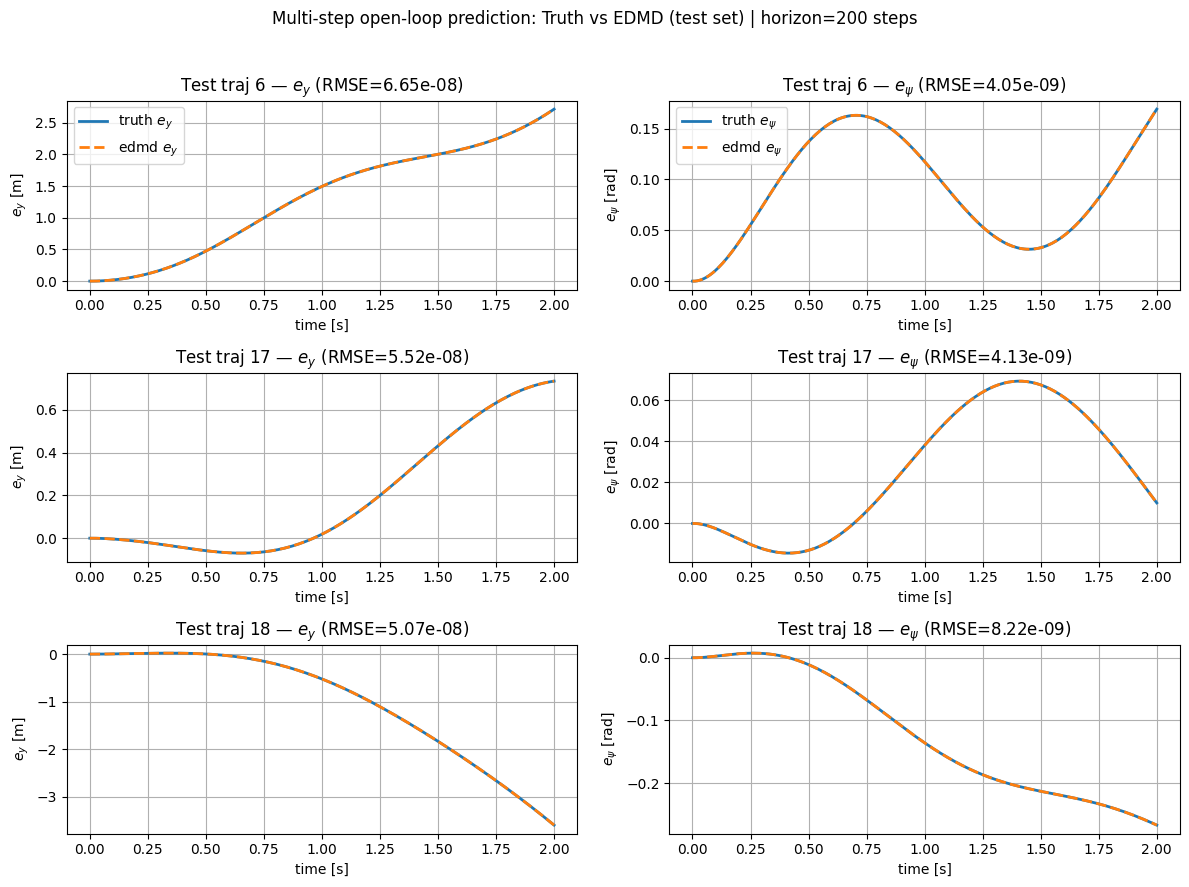

Multi-step EDMD rollout check complete.
- saved: 06_edmd_multistep_test_compare.png
- mean RMSE over horizon=200 steps [e_y, e_psi, v_y, r] = [5.74583000e-08 5.46579707e-09 4.94326288e-10 3.09493641e-10]
- summary table saved: 06_edmd_multistep_rmse_summary.csv


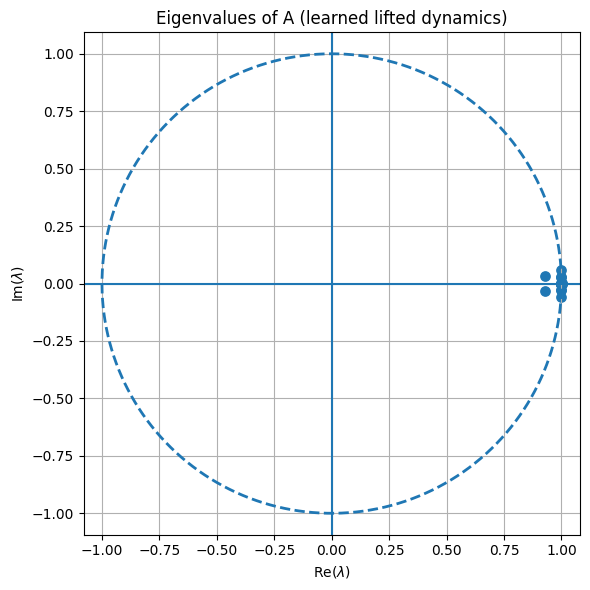

- saved: 06_edmd_eigs.png
- max |eig(A)| = 1.000818


In [9]:
# === 6) Multi-step EDMD rollout vs truth on test trajectories ===
# Uses C_sel only (exact selector reconstruction).
# Assumes already defined:
#   DIRS, save_fig, save_csv, lift_features, cfg
#   Xs, Us, Ks, test_idx

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------
# 0) Load EDMD model (+ scalers + C_sel)
# -------------------------
model_file = DIRS["models"] / "edmd_model.npz"

with np.load(model_file, allow_pickle=True) as m:
    A = np.asarray(m["A"], dtype=float)
    B = np.asarray(m["B"], dtype=float)

    has_scalers = all(k in m.files for k in ["mu_z", "sig_z", "mu_u", "sig_u"])
    mu_z = np.asarray(m["mu_z"], dtype=float) if has_scalers else None
    sig_z = np.asarray(m["sig_z"], dtype=float) if has_scalers else None
    mu_u = np.asarray(m["mu_u"], dtype=float) if has_scalers else None
    sig_u = np.asarray(m["sig_u"], dtype=float) if has_scalers else None

    if "C_sel" in m.files:
        C_sel_model = np.asarray(m["C_sel"], dtype=float)
    elif "C" in m.files:
        C_sel_model = np.asarray(m["C"], dtype=float)
    else:
        raise KeyError("Neither C_sel nor C found in edmd_model.npz. Re-run Section 5.")

print("Loaded EDMD model:")
print(f"- file: {model_file}")
print(f"- A: {A.shape}, B: {B.shape}")
print(f"- scalers: {'FOUND' if has_scalers else 'NOT FOUND'}")
print(f"- C_sel: {C_sel_model.shape}")


# -------------------------
# 1) Helpers
# -------------------------
def _col(v: np.ndarray) -> np.ndarray:
    return np.asarray(v, dtype=float).reshape(-1, 1)


def z_unscaled_from_x(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.shape != (4,):
        raise ValueError("x must have shape (4,).")
    return lift_features(x)


def reconstruct_x_from_z(z_unscaled: np.ndarray) -> np.ndarray:
    z_unscaled = np.asarray(z_unscaled, dtype=float).reshape(-1)
    return (C_sel_model @ z_unscaled.reshape(-1, 1)).ravel()


def edmd_rollout(
    x0: np.ndarray,
    U_seq: np.ndarray,
    K_seq: np.ndarray,
    *,
    use_scaling: bool = True,
) -> np.ndarray:
    """
    Roll out EDMD for the provided input sequences.

    Parameters
    ----------
    x0 : np.ndarray, shape (4,)
        Initial physical state.
    U_seq : np.ndarray, shape (T, 1)
        Steering sequence.
    K_seq : np.ndarray, shape (T,)
        Curvature sequence.
    use_scaling : bool
        Whether to use saved standardization scalers.

    Returns
    -------
    Xhat : np.ndarray, shape (T + 1, 4)
        Predicted state trajectory.
    """
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    U_seq = np.asarray(U_seq, dtype=float)
    K_seq = np.asarray(K_seq, dtype=float).reshape(-1)

    if x0.shape != (4,):
        raise ValueError("x0 must have shape (4,).")
    if U_seq.ndim != 2 or U_seq.shape[1] != 1:
        raise ValueError("U_seq must have shape (T, 1).")
    if len(K_seq) != U_seq.shape[0]:
        raise ValueError("K_seq must have length T where U_seq has shape (T, 1).")

    T = int(U_seq.shape[0])

    if use_scaling and not has_scalers:
        raise ValueError("use_scaling=True but scalers were not found in edmd_model.npz.")

    Xhat = np.zeros((T + 1, 4), dtype=float)

    z_un = z_unscaled_from_x(x0)

    if use_scaling:
        z_s = (z_un.reshape(-1, 1) - mu_z) / sig_z
        Xhat[0] = reconstruct_x_from_z(z_un)
    else:
        z_s = z_un.reshape(-1, 1)
        Xhat[0] = reconstruct_x_from_z(z_un)

    for k in range(T):
        u_un = np.array([float(U_seq[k, 0]), float(K_seq[k])], dtype=float).reshape(-1, 1)

        if use_scaling:
            u_s = (u_un - mu_u) / sig_u
            z_s = A @ z_s + B @ u_s
            z_un = (z_s * sig_z + mu_z).ravel()
        else:
            z_s = A @ z_s + B @ u_un
            z_un = z_s.ravel()

        Xhat[k + 1] = reconstruct_x_from_z(z_un)

    return Xhat


def rmse_vec(X_true: np.ndarray, X_pred: np.ndarray) -> np.ndarray:
    X_true = np.asarray(X_true, dtype=float)
    X_pred = np.asarray(X_pred, dtype=float)
    if X_true.shape != X_pred.shape:
        raise ValueError("X_true and X_pred must have the same shape.")
    E = X_pred - X_true
    return np.sqrt(np.mean(E**2, axis=0))


# -------------------------
# 2) Compare on a few test trajectories
# -------------------------
use_scaling = has_scalers
horizon_steps = 200
n_show = min(3, len(test_idx))
pick = list(test_idx[:n_show])

fig = plt.figure(figsize=(12, 9))
all_rmse = []
rows = []

for j, idx_traj in enumerate(pick):
    X_true_full = np.asarray(Xs[idx_traj], dtype=float)   # (T+1, 4)
    U_full = np.asarray(Us[idx_traj], dtype=float)        # (T, 1)
    K_full = np.asarray(Ks[idx_traj], dtype=float)        # (T,)

    T_full = U_full.shape[0]
    T_use = int(min(horizon_steps, T_full))

    X_true = X_true_full[:T_use + 1]
    U_seq = U_full[:T_use]
    K_seq = K_full[:T_use]

    X_pred = edmd_rollout(X_true[0], U_seq, K_seq, use_scaling=use_scaling)
    r = rmse_vec(X_true, X_pred)
    all_rmse.append(r)

    rows.append({
        "traj_idx": int(idx_traj),
        "rmse_e_y": float(r[0]),
        "rmse_e_psi": float(r[1]),
        "rmse_v_y": float(r[2]),
        "rmse_r": float(r[3]),
        "horizon_steps": int(T_use),
    })

    t_roll = np.arange(T_use + 1, dtype=float) * cfg.dt

    plt.subplot(n_show, 2, 2 * j + 1)
    plt.plot(t_roll, X_true[:, 0], label="truth $e_y$", linewidth=2.0)
    plt.plot(t_roll, X_pred[:, 0], "--", label="edmd $e_y$", linewidth=2.0)
    plt.grid(True)
    plt.xlabel("time [s]")
    plt.ylabel(r"$e_y$ [m]")
    plt.title(f"Test traj {idx_traj} — $e_y$ (RMSE={r[0]:.2e})")
    if j == 0:
        plt.legend()

    plt.subplot(n_show, 2, 2 * j + 2)
    plt.plot(t_roll, X_true[:, 1], label="truth $e_\\psi$", linewidth=2.0)
    plt.plot(t_roll, X_pred[:, 1], "--", label="edmd $e_\\psi$", linewidth=2.0)
    plt.grid(True)
    plt.xlabel("time [s]")
    plt.ylabel(r"$e_\psi$ [rad]")
    plt.title(f"Test traj {idx_traj} — $e_\\psi$ (RMSE={r[1]:.2e})")
    if j == 0:
        plt.legend()

plt.suptitle(f"Multi-step open-loop prediction: Truth vs EDMD (test set) | horizon={T_use} steps")
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path_cmp = save_fig(fig, "06_edmd_multistep_test_compare.png")
if "register_artifact" in globals():
    register_artifact(save_path_cmp, "figure")
plt.show()
plt.close(fig)

all_rmse = np.vstack(all_rmse)
rmse_mean = np.mean(all_rmse, axis=0)

summary_df = pd.DataFrame(rows)
summary_df.loc[len(summary_df)] = {
    "traj_idx": "mean",
    "rmse_e_y": float(rmse_mean[0]),
    "rmse_e_psi": float(rmse_mean[1]),
    "rmse_v_y": float(rmse_mean[2]),
    "rmse_r": float(rmse_mean[3]),
    "horizon_steps": int(T_use),
}

summary_path = save_csv(summary_df, "06_edmd_multistep_rmse_summary.csv")
if "register_artifact" in globals():
    register_artifact(summary_path, "table")

print("Multi-step EDMD rollout check complete.")
print(f"- saved: {save_path_cmp.name}")
print(f"- mean RMSE over horizon={T_use} steps [e_y, e_psi, v_y, r] = {rmse_mean}")
print(f"- summary table saved: {summary_path.name}")


# -------------------------
# 3) Eigenvalue stability check
# -------------------------
eigvals = np.linalg.eigvals(A)

fig2 = plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), s=45)
theta = np.linspace(0.0, 2.0 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", linewidth=2.0)
plt.axhline(0.0, linewidth=1.5)
plt.axvline(0.0, linewidth=1.5)
plt.axis("equal")
plt.grid(True)
plt.title("Eigenvalues of A (learned lifted dynamics)")
plt.xlabel(r"Re($\lambda$)")
plt.ylabel(r"Im($\lambda$)")
plt.tight_layout()
save_path_eigs = save_fig(fig2, "06_edmd_eigs.png")
if "register_artifact" in globals():
    register_artifact(save_path_eigs, "figure")
plt.show()
plt.close(fig2)

print(f"- saved: {save_path_eigs.name}")
print(f"- max |eig(A)| = {np.max(np.abs(eigvals)):.6f}")

The EDMD model achieves extremely accurate multi-step open-loop prediction over the tested 200-step horizon on held-out trajectories. Although the lifted dynamics matrix has a largest eigenvalue magnitude slightly above one, the observed finite-horizon rollout error remains negligible on these test cases, indicating that the learned model is practically reliable over the prediction horizons used here.

## 7) Koopman-MPC (QP on the Learned EDMD Model)

We now build a Model Predictive Controller (MPC) using the learned EDMD model in **standardized lifted coordinates**:

$$
z_{s,k+1} = A\,z_{s,k} + B\,u_{s,k},
$$

with standardization

$$
z_{s,k}=\frac{z_k-\mu_z}{\sigma_z},\qquad
u_{s,k}=\frac{u_k-\mu_u}{\sigma_u}.
$$

The lifted input is

$$
u_k=
\begin{bmatrix}
\delta_k\\
\kappa_{\text{ref},k}
\end{bmatrix},
$$

but inside MPC, the reference curvature $\kappa_{\text{ref},k}$ is treated as a **known preview signal**, so the only optimization variable is the steering input.

---

### Practical stabilization note

In the previous section, the learned lifted dynamics were found to be **very close to the unit-circle stability boundary**, with a spectral radius slightly above one. To improve numerical robustness inside MPC, we therefore apply a **minimal spectral shrink** to the learned matrix before closed-loop optimization.

This is a pragmatic controller-design step rather than a re-identification step:

- the EDMD model itself remains the learned model from Section 5,
- the shrink is only used inside the controller to avoid a marginally unstable lifted predictor from degrading optimization performance.

This preserves the learned structure as closely as possible while making the MPC implementation more reliable.

---

### Feedforward-centered control formulation

To reduce steady-state tracking bias, Koopman-MPC is formulated around a nominal **feedforward steering sequence** computed from the known previewed curvature. The optimizer then computes only the **corrective steering action** around that nominal input.

Thus, the applied steering is

$$
\delta_k = \delta^{\mathrm{ff}}_k + \delta^{\mathrm{corr}}_k,
$$

where:

- $\delta^{\mathrm{ff}}_k$ is the previewed feedforward steering from the reference curvature,
- $\delta^{\mathrm{corr}}_k$ is the correction generated by MPC.

This makes the optimization problem easier because the nominal steering needed for the maneuver is already supplied, and the controller only needs to correct residual tracking error.

---

### MPC formulation

#### Decision variables

- lifted state trajectory: $z_{s,0},\dots,z_{s,N}$
- corrective steering sequence: $\delta^{\mathrm{corr}}_0,\dots,\delta^{\mathrm{corr}}_{N-1}$

#### Dynamics

Partition the lifted input matrix as

$$
B = \begin{bmatrix} B_\delta & B_\kappa \end{bmatrix}.
$$

The controller uses the stabilized lifted matrix $A_{\mathrm{mpc}}$ together with the previewed feedforward steering and curvature sequence. The optimizer acts through the steering-correction channel while the reference curvature remains a known preview signal.

#### State reconstruction

The physical state is embedded in the lift and recovered through the fixed selector:

$$
x_k=
\begin{bmatrix}
e_y\\
e_\psi\\
v_y\\
r
\end{bmatrix}
=
C_{\text{sel}}\,z_k,
\qquad
z_k=\sigma_z\odot z_{s,k}+\mu_z.
$$

#### Cost

We regulate the physical state toward zero while penalizing total steering effort, corrective steering effort, and steering-rate variation:

$$
\sum_{k=0}^{N-1}
\left(
\|x_k\|_Q^2
+
\|\delta_k\|_R^2
+
\|\delta_k^{\mathrm{corr}}\|_{R_u}^2
+
\|\delta_k-\delta_{k-1}\|_{R_\Delta}^2
\right)
+
\|x_N\|_{Q_f}^2.
$$

#### Constraints

The total applied steering satisfies

$$
|\delta_k|\le\delta_{\max},
\qquad
|\delta_k-\delta_{k-1}|\le\dot\delta_{\max}\Delta t.
$$

---

### What we check in this section

- closed-loop tracking performance of Koopman-MPC
- comparison against the baseline feedforward + LQR controller
- RMS tracking errors in $e_y$ and $e_\psi$
- steering magnitude and smoothness
- the effect of using the learned lifted model inside the controller

### Outputs

Saved figure:

- `results/figures/07_koopman_mpc_closedloop.png`

Saved table:

- `results/tables/07_koopman_mpc_metrics.csv`

Printed metrics:

- baseline and Koopman-MPC RMS tracking errors
- maximum steering magnitude for both controllers
- raw and stabilized spectral radius used inside MPC

### Interpretation of the result

In this nominal lane-change experiment, the feedforward-centered Koopman-MPC reduces but does not eliminate the steady-state lateral offset observed in the earlier formulation. The controller remains stable and feasible, but it still underperforms the classical feedforward + LQR benchmark in both lateral tracking accuracy and steering economy.

This result highlights an important practical conclusion of the project:

> **strong predictive accuracy of a learned model does not automatically guarantee superior closed-loop control performance.**

Loaded EDMD model:
- file: C:\Users\sansk\OneDrive\Documents\GitHub\koopman-mpc-lateral-control\notebooks\results\models\edmd_model.npz
- A: (17, 17), B: (17, 2)
- C_sel: (4, 17)
Using A_mpc with raw rho(A) = 1.000818 and MPC rho(A_mpc) = 0.999999
MPC run config: dt=0.01 tf=25.0 N=200 steps=2501


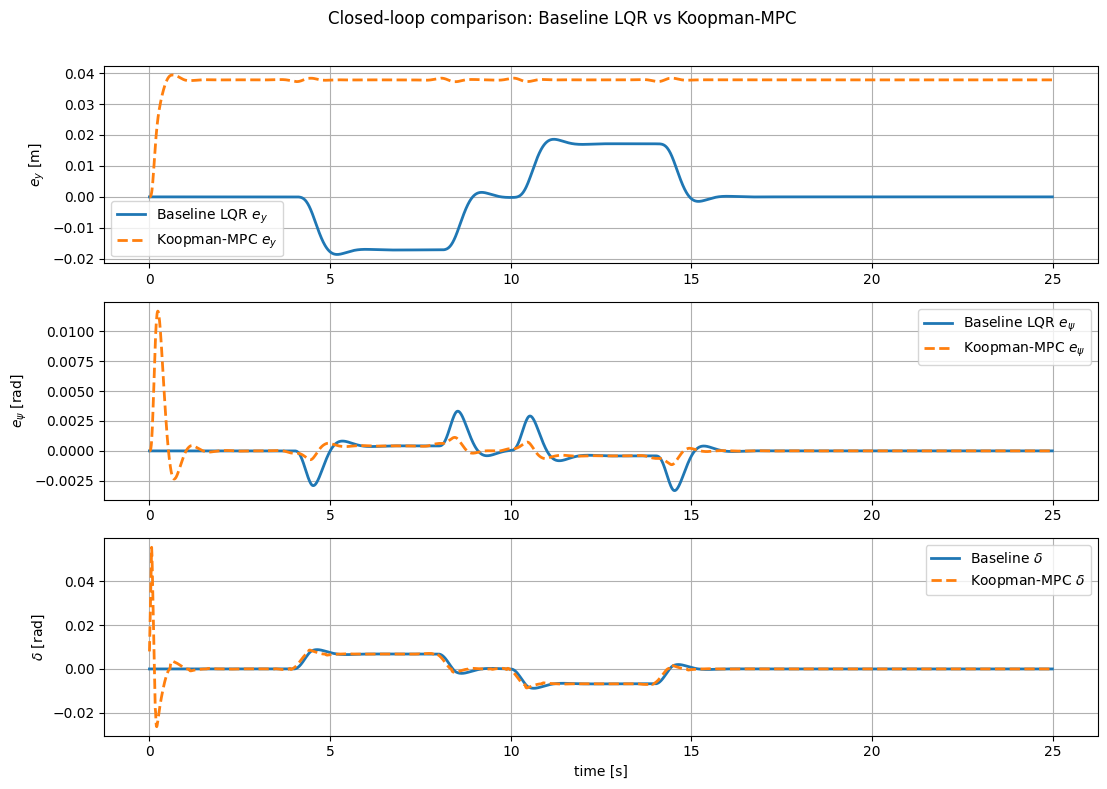

Koopman-MPC closed-loop complete.
- saved: 07_koopman_mpc_closedloop.png
- metrics table saved: 07_koopman_mpc_metrics.csv
- Baseline RMS e_y = 0.0095 m, RMS e_psi = 0.00081 rad
- Koopman  RMS e_y = 0.0376 m, RMS e_psi = 0.00111 rad
- max |delta| baseline = 0.009, koopman = 0.056
- raw rho(A) = 1.000818, MPC rho(A_mpc) = 0.999999


In [11]:
# =========================
# 7) Koopman-MPC (QP on the learned EDMD model)
# Feedforward-centered formulation
# =========================

import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def rms(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x**2)))


def stabilize_A(A: np.ndarray, eps: float = 1e-6) -> tuple[np.ndarray, float]:
    """
    Minimal spectral shrink used only inside MPC.
    Returns the stabilized matrix and the original spectral radius.
    """
    A = np.asarray(A, dtype=float)
    eig = np.linalg.eigvals(A)
    rho = float(np.max(np.abs(eig)))
    if rho > 1.0:
        return A / (rho + eps), rho
    return A.copy(), rho


OSQP_KW = dict(
    warm_start=True,
    verbose=False,
    max_iter=80000,
    eps_abs=1e-4,
    eps_rel=1e-4,
    polish=True,
    adaptive_rho=True,
)

# -------------------------
# 0) Load EDMD model
# -------------------------
model_file = DIRS["models"] / "edmd_model.npz"

with np.load(model_file, allow_pickle=True) as m:
    A_edmd = np.asarray(m["A"], dtype=float)
    B_edmd = np.asarray(m["B"], dtype=float)

    required = ["mu_z", "sig_z", "mu_u", "sig_u"]
    if not all(k in m.files for k in required):
        raise KeyError(f"Missing scalers in {model_file.name}. Re-run Section 5.")

    mu_z = np.asarray(m["mu_z"], dtype=float).reshape(-1)
    sig_z = np.asarray(m["sig_z"], dtype=float).reshape(-1)
    mu_u = np.asarray(m["mu_u"], dtype=float).reshape(-1)
    sig_u = np.asarray(m["sig_u"], dtype=float).reshape(-1)

    if "C_sel" in m.files:
        C_sel_model = np.asarray(m["C_sel"], dtype=float)
    elif "C" in m.files:
        C_sel_model = np.asarray(m["C"], dtype=float)
    else:
        raise KeyError("Neither C_sel nor C found in edmd_model.npz. Re-run Section 5.")

n_z = A_edmd.shape[0]

print("Loaded EDMD model:")
print(f"- file: {model_file}")
print(f"- A: {A_edmd.shape}, B: {B_edmd.shape}")
print(f"- C_sel: {C_sel_model.shape}")

A_mpc, rhoA_raw = stabilize_A(A_edmd, eps=1e-6)
rhoA_mpc = float(np.max(np.abs(np.linalg.eigvals(A_mpc))))
print(f"Using A_mpc with raw rho(A) = {rhoA_raw:.6f} and MPC rho(A_mpc) = {rhoA_mpc:.6f}")

mu_delta, mu_kappa = float(mu_u[0]), float(mu_u[1])
sig_delta, sig_kappa = float(sig_u[0]), float(sig_u[1])

if abs(sig_delta) < 1e-12 or abs(sig_kappa) < 1e-12:
    raise ValueError("Input scalers are too small; cannot safely standardize MPC inputs.")

Bdel = B_edmd[:, 0].reshape(-1, 1)
Bkap = B_edmd[:, 1].reshape(-1, 1)

SigZ = np.diag(sig_z)
M = C_sel_model @ SigZ
x_bias = (C_sel_model @ mu_z.reshape(-1, 1)).reshape(4)

# Stronger output-tracking emphasis, weaker vy/r regulation
Qx = np.diag([140.0, 100.0, 1.0, 1.0])
Qx_terminal = np.diag([220.0, 180.0, 1.0, 1.0])

# Penalize correction more than total steering
R_delta_total = 0.5
R_du = 8.0
R_drate = 30.0

Qx = 0.5 * (Qx + Qx.T)
Qx_terminal = 0.5 * (Qx_terminal + Qx_terminal.T)


def to_zs_from_x(x: np.ndarray) -> np.ndarray:
    z = lift_features(np.asarray(x, dtype=float)).reshape(-1)
    return (z - mu_z) / np.maximum(sig_z, 1e-12)


def predict_affine_terms(delta_raw: float, kappa_raw: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Return the lifted-state input contribution for raw (unscaled) delta and kappa:
        B[:,0] * delta_s + B[:,1] * kappa_s
    where delta_s = (delta_raw - mu_delta)/sig_delta and similarly for kappa.
    """
    delta_s = (float(delta_raw) - mu_delta) / sig_delta
    kappa_s = (float(kappa_raw) - mu_kappa) / sig_kappa
    term = (Bdel[:, 0] * delta_s + Bkap[:, 0] * kappa_s)
    term_du = Bdel[:, 0] / sig_delta
    return term, term_du


class KoopmanMPC:
    def __init__(self, cfg: CFG):
        self.cfg = cfg
        self.N = int(cfg.N)
        self.n_z = n_z

        self.zs = cp.Variable((self.n_z, self.N + 1))
        self.du = cp.Variable(self.N)  # correction around feedforward steering

        self.zs0 = cp.Parameter(self.n_z)
        self.delta_prev = cp.Parameter()
        self.delta_ff_preview = cp.Parameter(self.N)
        self.kappa_preview = cp.Parameter(self.N)

        constr = [self.zs[:, 0] == self.zs0]
        cost = 0

        for k in range(self.N):
            delta_total_k = self.delta_ff_preview[k] + self.du[k]

            aff_nom, aff_du = predict_affine_terms(0.0, 0.0)
            # aff_nom for zero is not used directly; build symbolic affine dynamics explicitly
            # using raw preview values:
            delta_ff_k = self.delta_ff_preview[k]
            kappa_k = self.kappa_preview[k]

            # standardized affine term for previewed nominal input
            delta_ff_s = (delta_ff_k - mu_delta) / sig_delta
            kappa_s = (kappa_k - mu_kappa) / sig_kappa

            constr += [
                self.zs[:, k + 1]
                == A_mpc @ self.zs[:, k]
                + Bdel[:, 0] * delta_ff_s
                + Bkap[:, 0] * kappa_s
                + (Bdel[:, 0] / sig_delta) * self.du[k]
            ]

            xk = M @ self.zs[:, k] + x_bias
            cost += cp.quad_form(xk, Qx)
            cost += R_delta_total * cp.square(delta_total_k)
            cost += R_du * cp.square(self.du[k])

            if k == 0:
                ddelta = delta_total_k - self.delta_prev
            else:
                ddelta = delta_total_k - (self.delta_ff_preview[k - 1] + self.du[k - 1])

            cost += R_drate * cp.square(ddelta)

            constr += [cp.abs(delta_total_k) <= cfg.delta_max]
            constr += [cp.abs(ddelta) <= cfg.delta_rate_max * cfg.dt]

        xN = M @ self.zs[:, self.N] + x_bias
        cost += cp.quad_form(xN, Qx_terminal)

        self.prob = cp.Problem(cp.Minimize(cost), constr)

    def solve(self, zs0_val, delta_prev_val, delta_ff_preview_val, kappa_preview_val) -> float:
        self.zs0.value = np.asarray(zs0_val, dtype=float).reshape(-1)
        self.delta_prev.value = float(delta_prev_val)
        self.delta_ff_preview.value = np.asarray(delta_ff_preview_val, dtype=float).reshape(-1)
        self.kappa_preview.value = np.asarray(kappa_preview_val, dtype=float).reshape(-1)

        try:
            self.prob.solve(solver=cp.OSQP, **OSQP_KW)
        except Exception:
            try:
                self.prob.solve(solver=cp.SCS, verbose=False, max_iters=20000)
            except Exception:
                return float(delta_prev_val)

        if self.du.value is None or self.prob.status not in ("optimal", "optimal_inaccurate"):
            try:
                self.prob.solve(solver=cp.SCS, verbose=False, max_iters=20000)
            except Exception:
                return float(delta_prev_val)

        if self.du.value is None:
            return float(delta_prev_val)

        return float(self.delta_ff_preview.value[0] + self.du.value[0])


def simulate_koopman_mpc(
    x0: np.ndarray,
    kappa_seq: np.ndarray,
    Vx: float,
    cfg: CFG,
    horizon_steps=None,
) -> tuple[np.ndarray, np.ndarray]:
    kappa_seq = np.asarray(kappa_seq, dtype=float).reshape(-1)

    T_full = len(kappa_seq)
    T = T_full if horizon_steps is None else int(min(horizon_steps, T_full))

    X = np.zeros((T + 1, 4), dtype=float)
    U = np.zeros(T, dtype=float)
    X[0] = np.asarray(x0, dtype=float).reshape(4)

    delta_prev = 0.0
    mpc = KoopmanMPC(cfg)

    for k in range(T):
        zs0 = to_zs_from_x(X[k])

        k_end = min(T, k + cfg.N)
        kappa_preview = kappa_seq[k:k_end]

        if len(kappa_preview) < cfg.N:
            fill_val = kappa_seq[min(T - 1, max(k, k_end - 1))]
            kappa_preview = np.concatenate(
                [kappa_preview, np.full(cfg.N - len(kappa_preview), fill_val)]
            )

        delta_ff_preview = np.array(
            [steer_feedforward_from_curvature(kap, Vx, cfg) for kap in kappa_preview],
            dtype=float
        )

        delta_cmd = mpc.solve(zs0, delta_prev, delta_ff_preview, kappa_preview)

        U[k] = delta_cmd
        X[k + 1] = bike_step(X[k], delta_cmd, kappa_seq[k], Vx, cfg)
        delta_prev = delta_cmd

    return X, U


if "t" not in globals() or "kappa_ref" not in globals():
    raise NameError("t and kappa_ref must already exist from earlier cells.")

kappa_seq = np.asarray(kappa_ref[:-1], dtype=float)
t_ctrl = np.asarray(t[:-1], dtype=float)

print(f"MPC run config: dt={cfg.dt} tf={cfg.tf} N={cfg.N} steps={len(t)}")

x0 = np.zeros(4, dtype=float)

# Koopman-MPC
X_mpc, U_mpc = simulate_koopman_mpc(x0, kappa_seq, cfg.Vx, cfg)
ey_mpc = X_mpc[:-1, 0]
epsi_mpc = X_mpc[:-1, 1]

# Baseline
X_lqr, U_lqr, _ = simulate_baseline_lqr(x0, kappa_seq, cfg.Vx, cfg)
ey_lqr = X_lqr[:-1, 0]
epsi_lqr = X_lqr[:-1, 1]

# -------------------------
# Plot comparison
# -------------------------
fig = plt.figure(figsize=(11, 8))

plt.subplot(3, 1, 1)
plt.plot(t_ctrl, ey_lqr, label=r"Baseline LQR $e_y$", linewidth=2.0)
plt.plot(t_ctrl, ey_mpc, "--", label=r"Koopman-MPC $e_y$", linewidth=2.0)
plt.ylabel(r"$e_y$ [m]")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_ctrl, epsi_lqr, label=r"Baseline LQR $e_\psi$", linewidth=2.0)
plt.plot(t_ctrl, epsi_mpc, "--", label=r"Koopman-MPC $e_\psi$", linewidth=2.0)
plt.ylabel(r"$e_\psi$ [rad]")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_ctrl, U_lqr, label=r"Baseline $\delta$", linewidth=2.0)
plt.plot(t_ctrl, U_mpc, "--", label=r"Koopman-MPC $\delta$", linewidth=2.0)
plt.ylabel(r"$\delta$ [rad]")
plt.xlabel("time [s]")
plt.grid(True)
plt.legend()

plt.suptitle("Closed-loop comparison: Baseline LQR vs Koopman-MPC")
plt.tight_layout(rect=[0, 0, 1, 0.97])
save_path = save_fig(fig, "07_koopman_mpc_closedloop.png")
if "register_artifact" in globals():
    register_artifact(save_path, "figure")
plt.show()
plt.close(fig)

# -------------------------
# Save metrics table
# -------------------------
metrics_df = pd.DataFrame([
    {
        "controller": "baseline_lqr",
        "rms_e_y": rms(ey_lqr),
        "rms_e_psi": rms(epsi_lqr),
        "max_abs_delta": float(np.max(np.abs(U_lqr))),
        "rho_A_raw": rhoA_raw,
        "rho_A_mpc": rhoA_mpc,
    },
    {
        "controller": "koopman_mpc",
        "rms_e_y": rms(ey_mpc),
        "rms_e_psi": rms(epsi_mpc),
        "max_abs_delta": float(np.max(np.abs(U_mpc))),
        "rho_A_raw": rhoA_raw,
        "rho_A_mpc": rhoA_mpc,
    },
])

metrics_path = save_csv(metrics_df, "07_koopman_mpc_metrics.csv")
if "register_artifact" in globals():
    register_artifact(metrics_path, "table")

print("Koopman-MPC closed-loop complete.")
print(f"- saved: {save_path.name}")
print(f"- metrics table saved: {metrics_path.name}")
print(f"- Baseline RMS e_y = {rms(ey_lqr):.4f} m, RMS e_psi = {rms(epsi_lqr):.5f} rad")
print(f"- Koopman  RMS e_y = {rms(ey_mpc):.4f} m, RMS e_psi = {rms(epsi_mpc):.5f} rad")
print(f"- max |delta| baseline = {np.max(np.abs(U_lqr)):.3f}, koopman = {np.max(np.abs(U_mpc)):.3f}")
print(f"- raw rho(A) = {rhoA_raw:.6f}, MPC rho(A_mpc) = {rhoA_mpc:.6f}")

## 8) Evaluation Suite: Lane-change + Slalom (Baseline vs Koopman-MPC)

To make the notebook presentation-ready, we run a small evaluation suite and save:
- side-by-side comparison plots for each maneuver
- a clean metrics table (CSV) for the report section

We evaluate two controllers on the same truth plant:
1. **Baseline** (feedforward + LQR)
2. **Koopman-MPC** (EDMD lifted linear model + QP)

### Maneuvers
- `lane_change`
- `slalom`

### Metrics (per maneuver × controller)
Let the error-state be $x_k = [e_y,\ e_\psi,\ v_y,\ r]^\top$ and steering be $\delta_k$.

**Tracking quality**
- RMS lateral error: $\mathrm{RMS}(e_y)$
- max lateral error: $\max_k |e_{y,k}|$
- RMS heading error: $\mathrm{RMS}(e_\psi)$
- max heading error: $\max_k |e_{\psi,k}|$

**Control effort**
- RMS steering: $\mathrm{RMS}(\delta)$
- max steering: $\max_k |\delta_k|$

**Smoothness**
- RMS steering increment: $\mathrm{RMS}(\Delta\delta)$, where $\Delta\delta_k = \delta_k - \delta_{k-1}$
- RMS steering rate: $\mathrm{RMS}(\dot\delta)$, where $\dot\delta_k \approx \Delta\delta_k / \Delta t$

### Artifacts saved
- figure: `results/figures/08_compare_lanechange_slalom.png`
- table (CSV): `results/tables/metrics_baseline_vs_koopman.csv`

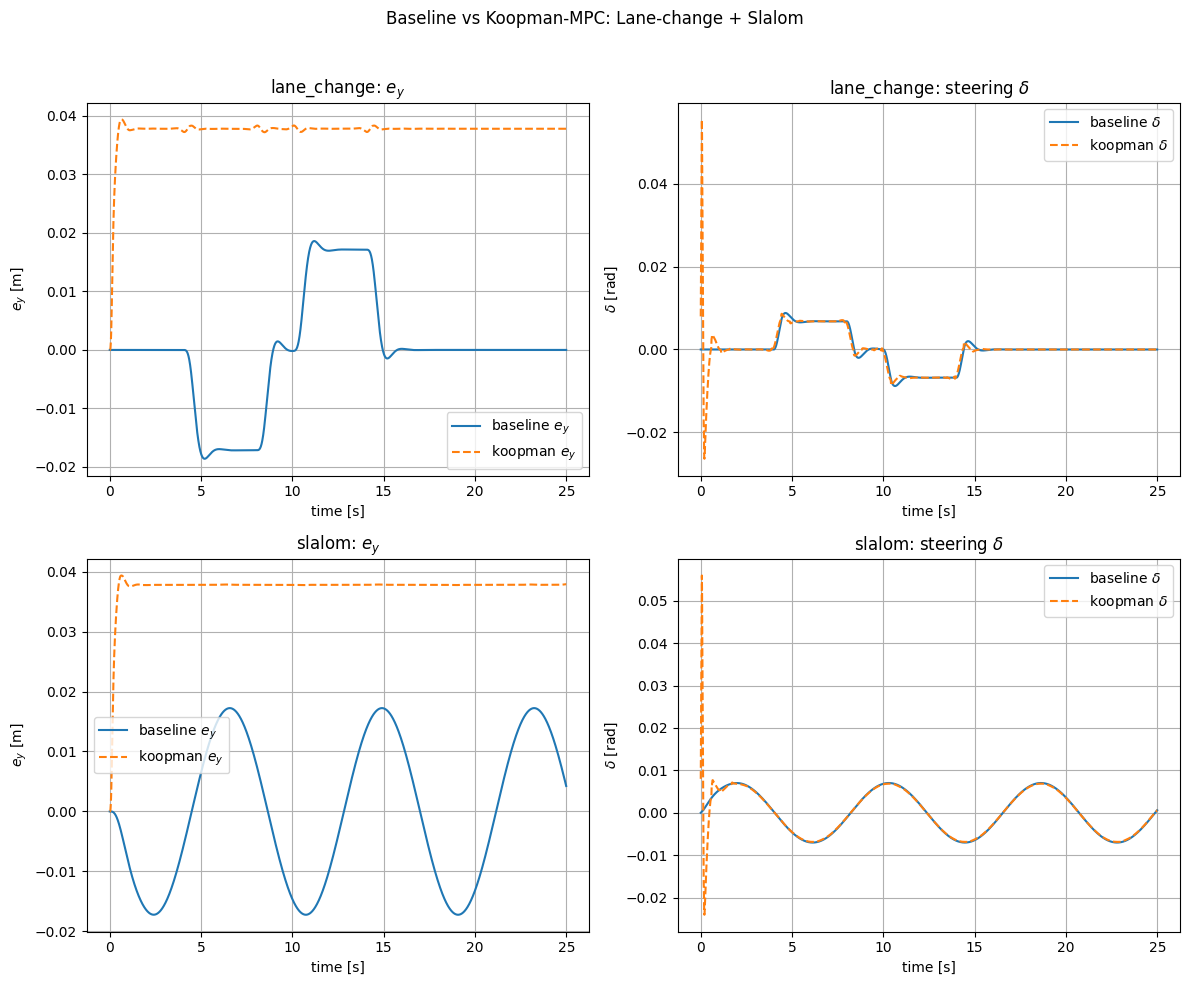

Evaluation suite complete.
- saved figure: 08_compare_lanechange_slalom.png
- saved metrics: metrics_baseline_vs_koopman.csv


,maneuver,controller,RMS_e_y_m,MAX_abs_e_y_m,RMS_e_psi_rad,MAX_abs_e_psi_rad,RMS_delta_rad,MAX_abs_delta_rad,RMS_deltastep_rad,MAX_abs_deltastep_rad,RMS_deltarate_rads,MAX_abs_deltarate_rads
0,lane_change,baseline_lqr,0.009534,0.018609,0.000813,0.003320,0.003945,0.008832,0.000053,0.000244,0.005263,0.024397
1,lane_change,koopman_mpc,0.037620,0.039390,0.001108,0.011686,0.004991,0.055586,0.000633,0.008030,0.063269,0.802991
2,slalom,baseline_lqr,0.012183,0.017238,0.000842,0.001205,0.004964,0.007022,0.000038,0.000067,0.003783,0.006693
3,slalom,koopman_mpc,0.037619,0.039362,0.001098,0.011395,0.005757,0.055964,0.000628,0.008033,0.062808,0.803315


In [12]:
# === 8) Multi-maneuver evaluation + metrics table ===
# Evaluates baseline LQR vs Koopman-MPC on the truth plant
# Maneuvers: lane_change, slalom
# Saves:
#   results/figures/08_compare_lanechange_slalom.png
#   results/tables/metrics_baseline_vs_koopman.csv

def delta_rate(delta: np.ndarray, dt: float) -> np.ndarray:
    delta = np.asarray(delta, dtype=float).reshape(-1)
    d = np.diff(delta, prepend=delta[0])
    return d / dt


def compute_metrics(X: np.ndarray, U: np.ndarray, cfg: CFG) -> dict:
    X = np.asarray(X, dtype=float)
    U = np.asarray(U, dtype=float).reshape(-1)

    ey = X[:-1, 0]
    epsi = X[:-1, 1]
    ddelta = np.diff(U, prepend=U[0])
    drate = delta_rate(U, cfg.dt)

    return {
        "RMS_e_y_m": rms(ey),
        "MAX_abs_e_y_m": float(np.max(np.abs(ey))),
        "RMS_e_psi_rad": rms(epsi),
        "MAX_abs_e_psi_rad": float(np.max(np.abs(epsi))),
        "RMS_delta_rad": rms(U),
        "MAX_abs_delta_rad": float(np.max(np.abs(U))),
        "RMS_deltastep_rad": rms(ddelta),
        "MAX_abs_deltastep_rad": float(np.max(np.abs(ddelta))),
        "RMS_deltarate_rads": rms(drate),
        "MAX_abs_deltarate_rads": float(np.max(np.abs(drate))),
    }


def run_controller_suite(maneuver_name: str, kappa_max: float, cfg: CFG):
    t_local = np.arange(cfg.t0, cfg.tf + cfg.dt, cfg.dt)
    kappa_local = make_curvature_profile(t_local, maneuver_name, kappa_max=kappa_max)

    X_mpc, U_mpc = simulate_koopman_mpc(np.zeros(4), kappa_local[:-1], cfg.Vx, cfg)
    X_lqr, U_lqr, _ = simulate_baseline_lqr(np.zeros(4), kappa_local[:-1], cfg.Vx, cfg)

    return t_local, kappa_local, (X_lqr, U_lqr), (X_mpc, U_mpc)


# ---- Evaluation scenarios ----
scenarios = [
    {"maneuver": "lane_change", "kappa_max": 0.002},
    {"maneuver": "slalom", "kappa_max": 0.002},
]

rows = []
fig = plt.figure(figsize=(12, 10))

for i, sc in enumerate(scenarios, start=1):
    man = sc["maneuver"]
    kmax = sc["kappa_max"]

    t_eval, kappa_eval, (X_lqr, U_lqr), (X_mpc, U_mpc) = run_controller_suite(man, kmax, cfg)

    rows.append({"maneuver": man, "controller": "baseline_lqr", **compute_metrics(X_lqr, U_lqr, cfg)})
    rows.append({"maneuver": man, "controller": "koopman_mpc", **compute_metrics(X_mpc, U_mpc, cfg)})

    ax1 = plt.subplot(len(scenarios), 2, 2 * (i - 1) + 1)
    ax1.plot(t_eval[:-1], X_lqr[:-1, 0], label="baseline $e_y$")
    ax1.plot(t_eval[:-1], X_mpc[:-1, 0], "--", label="koopman $e_y$")
    ax1.set_title(f"{man}: $e_y$")
    ax1.set_xlabel("time [s]")
    ax1.set_ylabel(r"$e_y$ [m]")
    ax1.grid(True)
    ax1.legend()

    ax2 = plt.subplot(len(scenarios), 2, 2 * (i - 1) + 2)
    ax2.plot(t_eval[:-1], U_lqr, label="baseline $\\delta$")
    ax2.plot(t_eval[:-1], U_mpc, "--", label="koopman $\\delta$")
    ax2.set_title(f"{man}: steering $\\delta$")
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel(r"$\delta$ [rad]")
    ax2.grid(True)
    ax2.legend()

plt.suptitle("Baseline vs Koopman-MPC: Lane-change + Slalom")
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path_fig = save_fig(fig, "08_compare_lanechange_slalom.png")
if "register_artifact" in globals():
    register_artifact(save_path_fig, "figure")
plt.show()
plt.close(fig)

df_metrics = pd.DataFrame(rows)
save_path_csv = save_csv(df_metrics, "metrics_baseline_vs_koopman.csv")
if "register_artifact" in globals():
    register_artifact(save_path_csv, "table")

print("Evaluation suite complete.")
print(f"- saved figure: {save_path_fig.name}")
print(f"- saved metrics: {save_path_csv.name}")
display(df_metrics)

Across both lane-change and slalom maneuvers, the baseline feedforward + LQR controller achieves lower RMS lateral tracking error than Koopman-MPC. Koopman-MPC remains feasible and stable, but it exhibits a persistent lateral offset and substantially less smooth steering, as reflected by the larger steering-step and steering-rate metrics. These results reinforce a central conclusion of the notebook: very accurate learned prediction does not automatically imply superior closed-loop control performance.

## 9) Robustness Sweep: Multiple Speeds (Baseline vs Koopman-MPC)

To assess generalization, we evaluate both controllers across different longitudinal speeds:
$$
V_x \in \{10,\ 15,\ 20,\ 25\}\ \text{m/s}.
$$

For each speed and maneuver (`lane_change`, `slalom`), we compute the same metrics and save:

- `results/tables/metrics_speed_sweep.csv`
- a compact summary plot of RMS lateral error versus speed:
  `results/figures/09_speed_sweep_rms_ey.png`

This sweep is especially important because the EDMD model was learned at a nominal operating condition rather than jointly across all speeds. Therefore, it reveals how well Koopman-MPC generalizes as the operating speed changes.

For computational efficiency, the robustness sweep is run with a shorter simulation horizon and a coarser timestep than the main nominal experiments. This does not change the qualitative comparison, but it makes the sweep practical to execute inside a single end-to-end notebook.

### Outputs

- full metrics table across speed, maneuver, and controller
- summary plot of RMS lateral error versus speed

### Interpretation

The speed sweep confirms that the fixed-speed Koopman-MPC controller has limited operating-point robustness. While it remains finite at lower and moderate speeds, its lateral tracking performance is consistently worse than the baseline controller, and it degrades catastrophically at 25 m/s on both lane-change and slalom maneuvers. In contrast, the baseline feedforward + LQR controller remains stable across the tested range. This provides strong evidence that the learned Koopman/EDMD controller is sensitive to operating speed and motivates a speed-aware extension.

[sweep cfg] dt=0.05, tf=10.0, N_sweep=30
Patched KoopmanMPC.solve (OSQP-first, minimal fallback).
Speed sweep complete.
- saved metrics CSV: metrics_speed_sweep.csv


,Vx,maneuver,controller,RMS_e_y_m,MAX_abs_e_y_m,RMS_e_psi_rad,MAX_abs_e_psi_rad,RMS_delta_rad,MAX_abs_delta_rad,RMS_deltastep_rad,MAX_abs_deltastep_rad,RMS_deltarate_rads,MAX_abs_deltarate_rads
0,10.0,lane_change,koopman_mpc,0.037084,0.040468,0.002154,0.014374,0.007017,0.046175,0.003599,0.032042,0.071978,0.640832
1,10.0,lane_change,baseline_lqr,0.001583,0.002693,0.001064,0.002263,0.003847,0.006548,0.000203,0.000846,0.004067,0.016927
2,10.0,slalom,koopman_mpc,0.035745,0.040220,0.002212,0.014675,0.007294,0.047892,0.003664,0.031816,0.073281,0.636324
3,10.0,slalom,baseline_lqr,0.001699,0.002563,0.001186,0.001696,0.004291,0.006203,0.000169,0.000236,0.003373,0.004721
4,15.0,lane_change,koopman_mpc,0.035643,0.038796,0.002490,0.016929,0.008144,0.046175,0.004062,0.034910,0.081237,0.698196
5,15.0,lane_change,baseline_lqr,0.011081,0.019521,0.000940,0.003447,0.004403,0.008756,0.000287,0.001172,0.005748,0.023434
6,15.0,slalom,koopman_mpc,0.035637,0.039610,0.002462,0.017095,0.008422,0.047856,0.004094,0.034900,0.081886,0.697997
7,15.0,slalom,baseline_lqr,0.012001,0.017907,0.000848,0.001232,0.004905,0.007017,0.000193,0.000331,0.003868,0.006610
8,20.0,lane_change,koopman_mpc,0.034917,0.046358,0.006832,0.018795,0.013147,0.046175,0.005440,0.034582,0.108801,0.691630
9,20.0,lane_change,baseline_lqr,0.033112,0.057937,0.002490,0.006899,0.005103,0.010561,0.000361,0.001497,0.007216,0.029949


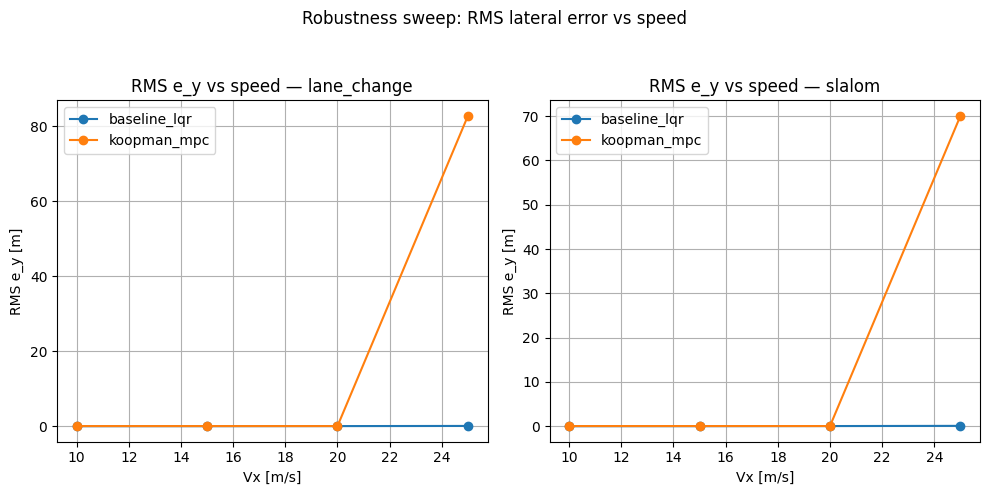

- saved summary plot: 09_speed_sweep_rms_ey.png
[restored cfg] dt=0.01, tf=25.0, Vx=15.0


In [14]:
# ============================================================
# 9) Robustness sweep over speed
# Baseline LQR vs Koopman-MPC across multiple Vx
#
# Saves:
#   results/tables/metrics_speed_sweep.csv
#   results/figures/09_speed_sweep_rms_ey.png
# ============================================================

import warnings
import inspect
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Fast sweep config
# ----------------------------
cfg_dt_old, cfg_tf_old, cfg_Vx_old = float(cfg.dt), float(cfg.tf), float(cfg.Vx)

try:
    cfg.dt = 0.05
    cfg.tf = 10.0

    N_sweep = int(round(1.5 / cfg.dt))
    print(f"[sweep cfg] dt={cfg.dt}, tf={cfg.tf}, N_sweep={N_sweep}")

    # ----------------------------
    # 1) Patch KoopmanMPC.solve
    #    Matches the CURRENT Section 7 signature:
    #    solve(zs0_val, delta_prev_val, delta_ff_preview_val, kappa_preview_val)
    # ----------------------------
    def _koopman_mpc_solve_fast(self, zs0_val, delta_prev_val, delta_ff_preview_val, kappa_preview_val):
        self.zs0.value = np.asarray(zs0_val, dtype=float).reshape(-1)
        self.delta_prev.value = float(delta_prev_val)
        self.delta_ff_preview.value = np.asarray(delta_ff_preview_val, dtype=float).reshape(-1)
        self.kappa_preview.value = np.asarray(kappa_preview_val, dtype=float).reshape(-1)

        osqp_kw = dict(
            warm_start=True,
            verbose=False,
            max_iter=40000,
            eps_abs=1e-4,
            eps_rel=1e-4,
            polish=True,
            adaptive_rho=True,
        )

        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="Solution may be inaccurate.*")
                self.prob.solve(solver=cp.OSQP, **osqp_kw)

            ok = self.prob.status in ["optimal", "optimal_inaccurate"]
            if (not ok) or (self.du.value is None):
                raise RuntimeError(f"OSQP failed (status={self.prob.status})")

        except Exception:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="Solution may be inaccurate.*")
                self.prob.solve(solver=cp.SCS, verbose=False, max_iters=8000, eps=2e-5)

        if self.du.value is None:
            return float(delta_prev_val)

        return float(self.delta_ff_preview.value[0] + self.du.value[0])

    KoopmanMPC.solve = _koopman_mpc_solve_fast
    print("Patched KoopmanMPC.solve (OSQP-first, minimal fallback).")

    # ----------------------------
    # 2) Helpers
    # ----------------------------
    def run_koopman_controller(x0, kappa_seq, cfg):
        if "simulate_koopman_mpc" in globals():
            return simulate_koopman_mpc(x0, kappa_seq, cfg.Vx, cfg)
        raise NameError("simulate_koopman_mpc is not defined. Run Section 7 first.")

    def call_compute_metrics(X, U, cfg):
        nparams = len(inspect.signature(compute_metrics).parameters)
        if nparams == 3:
            return compute_metrics(X, U, cfg)
        raise TypeError(f"compute_metrics has unexpected signature with {nparams} parameters.")

    def run_suite_for_speed(Vx_value, cfg, scenarios):
        old_Vx = float(cfg.Vx)
        cfg.Vx = float(Vx_value)

        rows = []
        t_eval = np.arange(cfg.t0, cfg.tf + cfg.dt, cfg.dt)

        for sc in scenarios:
            man = sc["maneuver"]
            kmax = sc["kappa_max"]

            kappa_state = make_curvature_profile(t_eval, man, kappa_max=kmax)
            kappa_seq = kappa_state[:-1]

            # Koopman-MPC
            X_mpc, U_mpc = run_koopman_controller(np.zeros(4), kappa_seq, cfg)

            if (not np.all(np.isfinite(X_mpc))) or (not np.all(np.isfinite(U_mpc))):
                print(f"[warn] non-finite Koopman-MPC at Vx={cfg.Vx}, maneuver={man}. Metrics set to NaN.")
                X_lqr_tmp, U_lqr_tmp, _ = simulate_baseline_lqr(np.zeros(4), kappa_seq, cfg.Vx, cfg)
                keys = list(call_compute_metrics(X_lqr_tmp, U_lqr_tmp, cfg).keys())
                m_mpc = {k: np.nan for k in keys}
            else:
                m_mpc = call_compute_metrics(X_mpc, U_mpc, cfg)

            rows.append({"Vx": cfg.Vx, "maneuver": man, "controller": "koopman_mpc", **m_mpc})

            # Baseline
            X_lqr, U_lqr, _ = simulate_baseline_lqr(np.zeros(4), kappa_seq, cfg.Vx, cfg)
            m_lqr = call_compute_metrics(X_lqr, U_lqr, cfg)
            rows.append({"Vx": cfg.Vx, "maneuver": man, "controller": "baseline_lqr", **m_lqr})

        cfg.Vx = old_Vx
        return rows

    # ----------------------------
    # 3) Run sweep
    # ----------------------------
    speeds = [10.0, 15.0, 20.0, 25.0]
    scenarios = [
        {"maneuver": "lane_change", "kappa_max": 0.002},
        {"maneuver": "slalom", "kappa_max": 0.002},
    ]

    all_rows = []
    for Vx in speeds:
        all_rows.extend(run_suite_for_speed(Vx, cfg, scenarios))

    df_sweep = pd.DataFrame(all_rows)
    save_path_csv = save_csv(df_sweep, "metrics_speed_sweep.csv")
    if "register_artifact" in globals():
        register_artifact(save_path_csv, "table")

    print("Speed sweep complete.")
    print(f"- saved metrics CSV: {save_path_csv.name}")
    display(df_sweep)

    # ----------------------------
    # 4) Summary plot
    # ----------------------------
    fig = plt.figure(figsize=(10, 5))

    for j, man in enumerate(["lane_change", "slalom"], start=1):
        plt.subplot(1, 2, j)
        for ctrl in ["baseline_lqr", "koopman_mpc"]:
            sub = df_sweep[
                (df_sweep["maneuver"] == man) & (df_sweep["controller"] == ctrl)
            ].sort_values("Vx")
            plt.plot(sub["Vx"].values, sub["RMS_e_y_m"].values, marker="o", label=ctrl)

        plt.title(f"RMS e_y vs speed — {man}")
        plt.xlabel("Vx [m/s]")
        plt.ylabel("RMS e_y [m]")
        plt.grid(True)
        plt.legend()

    plt.suptitle("Robustness sweep: RMS lateral error vs speed")
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    save_path_fig = save_fig(fig, "09_speed_sweep_rms_ey.png")
    if "register_artifact" in globals():
        register_artifact(save_path_fig, "figure")
    plt.show()
    plt.close(fig)

    print(f"- saved summary plot: {save_path_fig.name}")

finally:
    cfg.dt = cfg_dt_old
    cfg.tf = cfg_tf_old
    cfg.Vx = cfg_Vx_old
    print(f"[restored cfg] dt={cfg.dt}, tf={cfg.tf}, Vx={cfg.Vx}")

## 10) Robustness Sweep Summary + Failure Analysis

From Section 9, Koopman-MPC (trained at a single speed) can degrade badly as longitudinal speed increases.  
Here we summarize the sweep in a **report-friendly** way:

- load the sweep metrics table (`metrics_speed_sweep.csv`) or reuse `df_sweep` if it exists,
- define a simple failure rule for Koopman-MPC,
- print which speeds fail for each maneuver,
- save a compact summary CSV for the report,
- plot `RMS(e_y)` versus `V_x` using both:
  - linear scale, to show absolute error magnitude,
  - log scale, to show lower-speed trends when high-speed failures dominate.

### Failure rule

We mark Koopman-MPC as a **failure** if

$$
\mathrm{RMS}(e_y) > 2.0\ \text{m}
$$

or if the reported RMS value is non-finite.

This threshold is heuristic and is used only as a practical indicator of clearly unacceptable tracking.

### Outputs

Saved artifacts:

- `results/figures/10_speed_sweep_summary_linear.png`
- `results/figures/10_speed_sweep_summary_log.png`
- `results/tables/metrics_speed_sweep_summary.csv`

### Interpretation

The summary confirms that Koopman-MPC remains acceptable only over a limited operating region and fails at the highest tested speed on both maneuvers. This provides a concise robustness conclusion for the report and reinforces the need for a speed-aware or gain-scheduled learned controller.

=== Combo 10 Summary: Speed sweep robustness ===
Maneuvers: ['lane_change', 'slalom']
Speeds: [10.0, 15.0, 20.0, 25.0]
Failure threshold: RMS_e_y_m > 2.0 (or non-finite)
- Koopman-MPC: FAILURES for lane_change at Vx = [25.0] m/s
- Koopman-MPC: FAILURES for slalom at Vx = [25.0] m/s
- Saved summary CSV: metrics_speed_sweep_summary.csv


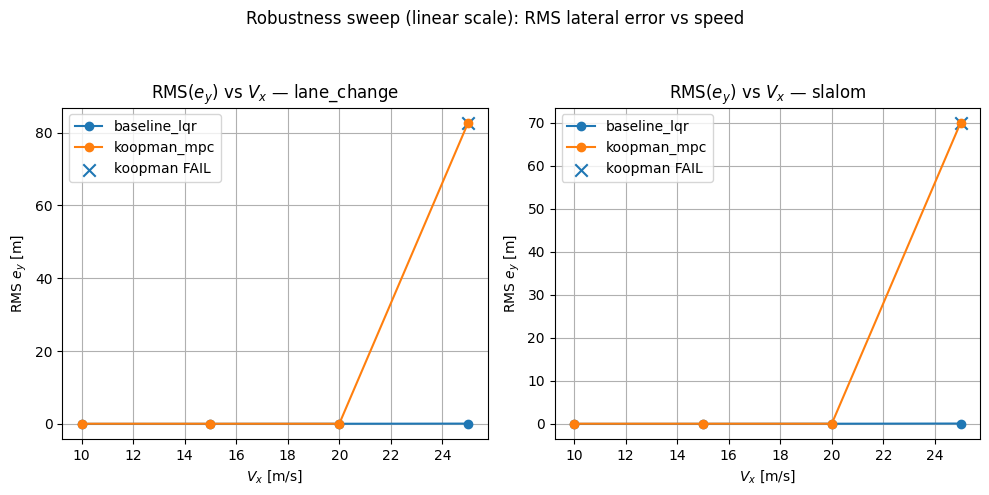

- Saved: 10_speed_sweep_summary_linear.png


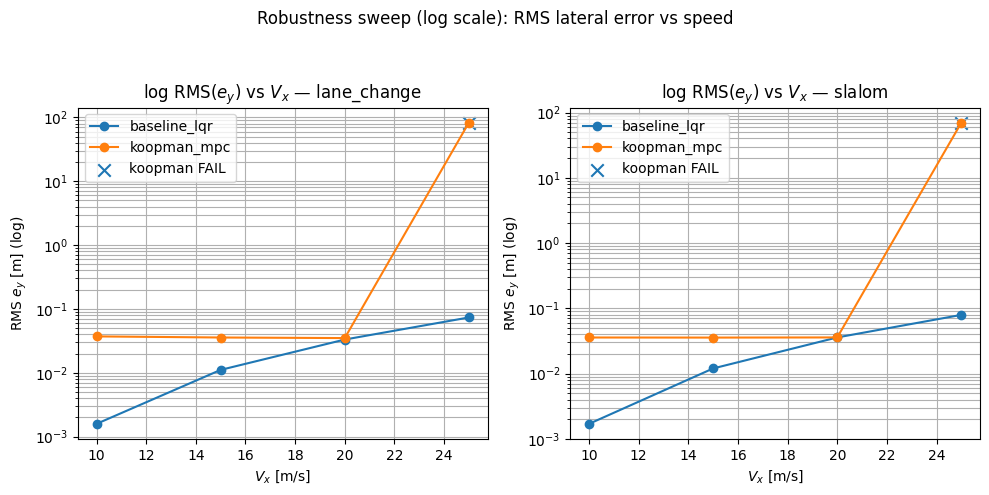

- Saved: 10_speed_sweep_summary_log.png

Combo 10 complete.


In [15]:
# ============================================================
# 10) Robustness Sweep Summary + Failure Analysis
# - Loads metrics_speed_sweep.csv (or uses df_sweep if present)
# - Creates clean plots (linear + log-scale)
# - Flags Koopman failure speeds automatically
# - Saves:
#   results/figures/10_speed_sweep_summary_linear.png
#   results/figures/10_speed_sweep_summary_log.png
#   results/tables/metrics_speed_sweep_summary.csv
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Load data
# ----------------------------
if "df_sweep" in globals() and isinstance(df_sweep, pd.DataFrame) and len(df_sweep) > 0:
    df = df_sweep.copy()
else:
    csv_path = DIRS["tables"] / "metrics_speed_sweep.csv"
    df = pd.read_csv(csv_path)

required_cols = {"Vx", "maneuver", "controller", "RMS_e_y_m"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"metrics_speed_sweep is missing columns: {missing}")

df["Vx"] = df["Vx"].astype(float)

# ----------------------------
# 1) Helper: detect Koopman failure
# ----------------------------
FAIL_RMS_EY = 2.0  # meters (heuristic threshold)

def is_failure(row: pd.Series) -> bool:
    val = row["RMS_e_y_m"]
    if not np.isfinite(val):
        return True
    return float(val) > FAIL_RMS_EY

df["koopman_failure"] = False
mask_k = df["controller"] == "koopman_mpc"
df.loc[mask_k, "koopman_failure"] = df.loc[mask_k].apply(is_failure, axis=1)

# ----------------------------
# 2) Print report-friendly summary
# ----------------------------
maneuvers = sorted(df["maneuver"].unique().tolist())
speeds = sorted(df["Vx"].unique().tolist())

print("=== Combo 10 Summary: Speed sweep robustness ===")
print("Maneuvers:", maneuvers)
print("Speeds:", speeds)
print(f"Failure threshold: RMS_e_y_m > {FAIL_RMS_EY} (or non-finite)")

for man in maneuvers:
    sub_k = df[(df["maneuver"] == man) & (df["controller"] == "koopman_mpc")].sort_values("Vx")
    fail_speeds = sub_k.loc[sub_k["koopman_failure"], "Vx"].tolist()
    if len(fail_speeds) == 0:
        print(f"- Koopman-MPC: no failures detected for {man}.")
    else:
        print(f"- Koopman-MPC: FAILURES for {man} at Vx = {fail_speeds} m/s")

# ----------------------------
# 3) Save compact summary table
# ----------------------------
keep_cols = [
    "Vx",
    "maneuver",
    "controller",
    "RMS_e_y_m",
    "RMS_e_psi_rad",
    "RMS_delta_rad",
    "koopman_failure",
]
keep_cols = [c for c in keep_cols if c in df.columns]
df_summary = df[keep_cols].copy()

save_path_summary = save_csv(df_summary, "metrics_speed_sweep_summary.csv")
if "register_artifact" in globals():
    register_artifact(save_path_summary, "table")
print(f"- Saved summary CSV: {save_path_summary.name}")

# ----------------------------
# 4) Plot: linear scale
# ----------------------------
fig = plt.figure(figsize=(10, 5))

for j, man in enumerate(maneuvers, start=1):
    plt.subplot(1, len(maneuvers), j)

    for ctrl in ["baseline_lqr", "koopman_mpc"]:
        sub = df[(df["maneuver"] == man) & (df["controller"] == ctrl)].sort_values("Vx")
        plt.plot(sub["Vx"].values, sub["RMS_e_y_m"].values, marker="o", label=ctrl)

        if ctrl == "koopman_mpc":
            sub_fail = sub[sub["koopman_failure"]]
            if len(sub_fail) > 0:
                plt.scatter(
                    sub_fail["Vx"].values,
                    sub_fail["RMS_e_y_m"].values,
                    marker="x",
                    s=80,
                    label="koopman FAIL",
                )

    plt.title(f"RMS($e_y$) vs $V_x$ — {man}")
    plt.xlabel(r"$V_x$ [m/s]")
    plt.ylabel(r"RMS $e_y$ [m]")
    plt.grid(True)
    plt.legend()

plt.suptitle("Robustness sweep (linear scale): RMS lateral error vs speed")
plt.tight_layout(rect=[0, 0, 1, 0.93])
save_path_lin = save_fig(fig, "10_speed_sweep_summary_linear.png")
if "register_artifact" in globals():
    register_artifact(save_path_lin, "figure")
plt.show()
plt.close(fig)
print(f"- Saved: {save_path_lin.name}")

# ----------------------------
# 5) Plot: log scale
# ----------------------------
fig2 = plt.figure(figsize=(10, 5))

for j, man in enumerate(maneuvers, start=1):
    plt.subplot(1, len(maneuvers), j)

    for ctrl in ["baseline_lqr", "koopman_mpc"]:
        sub = df[(df["maneuver"] == man) & (df["controller"] == ctrl)].sort_values("Vx")
        y = np.maximum(sub["RMS_e_y_m"].values, 1e-9)
        plt.plot(sub["Vx"].values, y, marker="o", label=ctrl)

        if ctrl == "koopman_mpc":
            sub_fail = sub[sub["koopman_failure"]]
            if len(sub_fail) > 0:
                y_fail = np.maximum(sub_fail["RMS_e_y_m"].values, 1e-9)
                plt.scatter(
                    sub_fail["Vx"].values,
                    y_fail,
                    marker="x",
                    s=80,
                    label="koopman FAIL",
                )

    plt.yscale("log")
    plt.title(f"log RMS($e_y$) vs $V_x$ — {man}")
    plt.xlabel(r"$V_x$ [m/s]")
    plt.ylabel(r"RMS $e_y$ [m] (log)")
    plt.grid(True, which="both")
    plt.legend()

plt.suptitle("Robustness sweep (log scale): RMS lateral error vs speed")
plt.tight_layout(rect=[0, 0, 1, 0.93])
save_path_log = save_fig(fig2, "10_speed_sweep_summary_log.png")
if "register_artifact" in globals():
    register_artifact(save_path_log, "figure")
plt.show()
plt.close(fig2)
print(f"- Saved: {save_path_log.name}")

print("\nCombo 10 complete.")

## 11) Speed-aware Koopman (LPV-EDMD): Learn a Model Across Multiple Speeds

Our original EDMD model was trained at a single longitudinal speed (fixed `Vx`), and the robustness sweep showed that the resulting Koopman-MPC can degrade badly at higher speeds, especially around 25 m/s.

To address this, we now train a **speed-aware** EDMD model by augmenting the input with speed:
$$
u_k = \begin{bmatrix}\delta_k\\ \kappa_k\\ V_x\end{bmatrix}.
$$

This yields a lifted predictor of the form
$$
z_{k+1} = A z_k + B_\delta \delta_k + B_\kappa \kappa_k + B_v V_x
\quad\equiv\quad
z_{k+1} = A z_k + B u_k.
$$

---

### Why this section matters

The fixed-speed EDMD model only learned dynamics near one operating condition.  
Here, we ask a harder question:

> Can a single lifted linear model capture the vehicle dynamics across a **range of speeds** rather than only at one nominal speed?

This is a more difficult identification problem, so it is normal for the one-step validation RMSE here to be worse than the fixed-speed EDMD numbers from Section 5.

---

### Model form

We again work in standardized lifted coordinates:
$$
z_s = \frac{z-\mu_z}{\sigma_z},
\qquad
u_s = \frac{u-\mu_u}{\sigma_u},
$$
and fit an **affine** lifted predictor:
$$
z_{s,k+1} \approx A z_{s,k} + B u_{s,k} + c.
$$

The physical state is still recovered by the fixed selector
$$
x_k =
\begin{bmatrix}
e_y\\ e_\psi\\ v_y\\ r
\end{bmatrix}
=
C_{\text{sel}}\, z_k.
$$

---

### Procedure

1. generate a **multi-speed dataset** with
   $$
   V_x \in \{10,\ 15,\ 20,\ 25\}\ \text{m/s}
   $$
2. build lifted regression matrices using the augmented input \(u=[\delta,\kappa,V_x]\)
3. fit affine EDMD \((A,B,c)\) using ridge regression in standardized coordinates
4. evaluate **1-step validation RMSE** on held-out trajectories
5. save the learned model to `results/models/edmd_model_vx.npz`
6. save a compact validation metrics table to `results/tables/11_edmd_vx_val_onestep_metrics.csv`

---

### Important interpretation

This section does **not** claim that the speed-aware model is already better than the fixed-speed model.  
Instead, it tests whether adding \(V_x\) creates a more general model for later controller design.

A worse one-step RMSE here is not automatically a bug; it may simply reflect that the model is being asked to represent a much broader operating envelope.

In the present results, the speed-aware EDMD model shows larger one-step validation error than the fixed-speed model, which is expected because a single affine lifted predictor is now being asked to represent dynamics across multiple operating speeds. This does not invalidate the approach; instead, it reflects the increased difficulty of learning a broader operating envelope.

The real question is answered in the next section:

**does the speed-aware model lead to better closed-loop behavior across speeds?**

In [17]:
# ============================================================
# 11) Speed-aware EDMD (LPV-EDMD)
# Learns EDMD in standardized lifted coordinates with affine term:
#   z_s(k+1) = A z_s(k) + B u_s(k) + c
# where u = [delta, kappa, Vx] and u_s = (u - mu_u) / sig_u
#
# Saves:
#   results/models/edmd_model_vx.npz
#   results/tables/11_edmd_vx_val_onestep_metrics.csv
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# 0) Sanity checks
# ----------------------------
required = [
    "cfg", "t", "rng", "DIRS",
    "lift_features", "make_curvature_profile", "rollout_open_loop", "save_csv"
]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required objects in kernel: {missing}")

# ----------------------------
# 1) Helper fallbacks
# ----------------------------
if "apply_rate_limit" not in globals():
    def apply_rate_limit(u, dt, rate_max):
        u = np.asarray(u, dtype=float).reshape(-1).copy()
        if dt <= 0:
            raise ValueError("dt must be positive.")
        if rate_max < 0:
            raise ValueError("rate_max must be nonnegative.")
        max_step = float(rate_max) * float(dt)
        for k in range(1, len(u)):
            u[k] = float(np.clip(u[k], u[k - 1] - max_step, u[k - 1] + max_step))
        return u

if "gen_pe_steering" not in globals():
    def gen_pe_steering(t_state, rng, amp=0.12, n_sines=6, fmin=0.05, fmax=0.8):
        t_state = np.asarray(t_state, dtype=float).reshape(-1)
        if len(t_state) < 2:
            raise ValueError("t_state must have at least two samples.")

        u = np.zeros_like(t_state, dtype=float)
        freqs = rng.uniform(fmin, fmax, size=int(n_sines))
        phases = rng.uniform(0.0, 2.0 * np.pi, size=int(n_sines))
        weights = rng.uniform(0.2, 1.0, size=int(n_sines))
        weights = weights / (np.sum(weights) + 1e-12)

        for w, f, ph in zip(weights, freqs, phases):
            u += w * np.sin(2.0 * np.pi * f * t_state + ph)

        u = u / (np.max(np.abs(u)) + 1e-12)
        return float(amp) * u

def save_npz_models(filename, **arrays):
    models_dir = Path(DIRS["models"])
    models_dir.mkdir(parents=True, exist_ok=True)
    path = models_dir / filename
    np.savez(path, **arrays)
    return path

# ----------------------------
# 2) Lift dimension + exact selector
# ----------------------------
n_z = int(len(lift_features(np.zeros(4, dtype=float))))

C_sel = np.zeros((4, n_z), dtype=float)
C_sel[0, 1] = 1.0  # e_y
C_sel[1, 2] = 1.0  # e_psi
C_sel[2, 3] = 1.0  # v_y
C_sel[3, 4] = 1.0  # r

# ----------------------------
# 3) Standardization helpers
# ----------------------------
def row_stats_z(M, eps=1e-9):
    """
    Row-wise mean/std for lifted-state standardization.
    Preserve the constant bias feature (first row).
    """
    M = np.asarray(M, dtype=float)
    if M.ndim != 2:
        raise ValueError("row_stats_z expects a 2D array.")

    mu = np.mean(M, axis=1, keepdims=True)
    sig = np.std(M, axis=1, keepdims=True)
    sig = np.maximum(sig, eps)

    mu[0, 0] = 0.0
    sig[0, 0] = 1.0
    return mu, sig


def row_stats_u(M, eps=1e-9):
    M = np.asarray(M, dtype=float)
    if M.ndim != 2:
        raise ValueError("row_stats_u expects a 2D array.")

    mu = np.mean(M, axis=1, keepdims=True)
    sig = np.std(M, axis=1, keepdims=True)
    sig = np.maximum(sig, eps)
    return mu, sig


def standardize(M, mu, sig):
    M = np.asarray(M, dtype=float)
    return (M - mu) / sig

# ----------------------------
# 4) Ridge solve for affine EDMD
# ----------------------------
def ridge_affine_solve(Zs, Zsp, Us, lam=1e-6):
    """
    Fit:
        Zsp = [A B c] [Zs; Us; 1]
    """
    Zs = np.asarray(Zs, dtype=float)
    Zsp = np.asarray(Zsp, dtype=float)
    Us = np.asarray(Us, dtype=float)

    if Zs.ndim != 2 or Zsp.ndim != 2 or Us.ndim != 2:
        raise ValueError("Zs, Zsp, and Us must be 2D arrays.")
    if lam < 0:
        raise ValueError("lam must be nonnegative.")

    n_z_local, N = Zs.shape
    m, N2 = Us.shape

    if Zsp.shape != (n_z_local, N):
        raise ValueError(f"Zsp has wrong shape: expected {(n_z_local, N)}, got {Zsp.shape}")
    if N2 != N:
        raise ValueError(f"Us has wrong shape: expected ({m}, {N}), got {Us.shape}")

    ones = np.ones((1, N), dtype=float)
    G = np.vstack([Zs, Us, ones])

    GGt = G @ G.T
    reg = GGt + lam * np.eye(GGt.shape[0], dtype=float)
    rhs = Zsp @ G.T

    W = np.linalg.solve(reg.T, rhs.T).T

    A = W[:, :n_z_local]
    B = W[:, n_z_local:n_z_local + m]
    c = W[:, -1]

    return A, B, c

# ----------------------------
# 5) Multi-speed rollout generator
# ----------------------------
def make_rollout_with_speed(
    t_state,
    cfg,
    rng,
    maneuver_kind,
    kappa_max,
    steer_amp,
    Vx_value,
):
    """
    Returns:
      X: (T+1, 4)
      U: (T, 1)
      K: (T,)
      Vx_value: float
    """
    t_state = np.asarray(t_state, dtype=float).reshape(-1)
    if kappa_max < 0:
        raise ValueError("kappa_max must be nonnegative.")
    if steer_amp < 0:
        raise ValueError("steer_amp must be nonnegative.")
    if Vx_value <= 0:
        raise ValueError("Vx_value must be positive.")

    kappa_state = make_curvature_profile(t_state, maneuver_kind, kappa_max=kappa_max)
    kappa_seq = np.asarray(kappa_state[:-1], dtype=float)

    delta_state = gen_pe_steering(t_state, rng, amp=steer_amp)
    delta_state = apply_rate_limit(delta_state, cfg.dt, cfg.delta_rate_max)
    delta_state = np.clip(delta_state, -cfg.delta_max, cfg.delta_max)
    delta_seq = np.asarray(delta_state[:-1], dtype=float)

    X = rollout_open_loop(np.zeros(4, dtype=float), delta_seq, kappa_seq, float(Vx_value), cfg)
    return X, delta_seq.reshape(-1, 1), kappa_seq, float(Vx_value)

# ----------------------------
# 6) Build EDMD matrices
# ----------------------------
def build_edmd_matrices_vx(X_list, U_list, K_list, Vx_list, indices):
    """
    Build unscaled matrices:
      Z, Zp: (n_z, N)
      U:     (3, N), where u = [delta, kappa, Vx]
    """
    Z_cols, Zp_cols, U_cols = [], [], []

    for idx in indices:
        X = np.asarray(X_list[idx], dtype=float)
        U = np.asarray(U_list[idx], dtype=float)
        K = np.asarray(K_list[idx], dtype=float).reshape(-1)
        Vx_val = float(Vx_list[idx])

        if X.ndim != 2 or X.shape[1] != 4:
            raise ValueError(f"X_list[{idx}] must have shape (T+1, 4).")
        if U.ndim != 2 or U.shape[1] != 1:
            raise ValueError(f"U_list[{idx}] must have shape (T, 1).")
        if len(K) != U.shape[0]:
            raise ValueError(f"K_list[{idx}] must have length T.")
        if X.shape[0] != U.shape[0] + 1:
            raise ValueError(f"X_list[{idx}] must have one more row than U_list[{idx}].")

        T_local = U.shape[0]
        for k in range(T_local):
            Z_cols.append(lift_features(X[k]))
            Zp_cols.append(lift_features(X[k + 1]))
            U_cols.append([U[k, 0], K[k], Vx_val])

    if not Z_cols:
        raise ValueError("No samples were built for speed-aware EDMD.")

    Z = np.stack(Z_cols, axis=1)
    Zp = np.stack(Zp_cols, axis=1)
    Umat = np.asarray(U_cols, dtype=float).T

    return Z, Zp, Umat

# ----------------------------
# 7) One-step RMSE in physical state
# ----------------------------
def one_step_rmse_physical_vx(
    X_list, U_list, K_list, Vx_list, indices,
    A, B, c, mu_z, sig_z, mu_u, sig_u, C_sel
):
    errs = []
    sig_z_safe = np.maximum(np.asarray(sig_z, dtype=float), 1e-12)
    sig_u_safe = np.maximum(np.asarray(sig_u, dtype=float), 1e-12)

    for idx in indices:
        X = np.asarray(X_list[idx], dtype=float)
        U = np.asarray(U_list[idx], dtype=float)
        K = np.asarray(K_list[idx], dtype=float).reshape(-1)
        Vx_val = float(Vx_list[idx])

        T_local = U.shape[0]
        for k in range(T_local):
            z_k = lift_features(X[k]).reshape(-1, 1)
            u_k = np.array([U[k, 0], K[k], Vx_val], dtype=float).reshape(-1, 1)

            z_s = (z_k - mu_z) / sig_z_safe
            u_s = (u_k - mu_u) / sig_u_safe

            z_kp_s = A @ z_s + B @ u_s + c.reshape(-1, 1)
            z_kp = z_kp_s * sig_z_safe + mu_z

            x_kp_pred = (C_sel @ z_kp).ravel()
            errs.append(x_kp_pred - X[k + 1])

    E = np.asarray(errs, dtype=float)
    if E.ndim != 2 or E.shape[1] != 4:
        raise ValueError("Unexpected error array shape while computing RMSE.")
    return np.sqrt(np.mean(E**2, axis=0))

# ----------------------------
# 8) Build multi-speed dataset
# ----------------------------
speeds_train = [10.0, 15.0, 20.0, 25.0]
n_traj_per_speed = 10
maneuvers = ["straight", "lane_change", "slalom"]

Xs_vx, Us_vx, Ks_vx, Vxs_vx = [], [], [], []

for Vx_val in speeds_train:
    for i in range(n_traj_per_speed):
        kind = maneuvers[i % len(maneuvers)]
        kappa_max_i = rng.uniform(0.0, 0.006) if kind != "straight" else 0.0
        steer_amp_i = rng.uniform(0.05, 0.18)

        X_i, U_i, K_i, Vx_i = make_rollout_with_speed(
            t_state=t,
            cfg=cfg,
            rng=rng,
            maneuver_kind=kind,
            kappa_max=kappa_max_i,
            steer_amp=steer_amp_i,
            Vx_value=Vx_val,
        )

        Xs_vx.append(X_i)
        Us_vx.append(U_i)
        Ks_vx.append(K_i)
        Vxs_vx.append(Vx_i)

n_traj = len(Xs_vx)
idx = np.arange(n_traj)
rng.shuffle(idx)

n_train = int(0.70 * n_traj)
n_val = int(0.15 * n_traj)

train_idx_vx = idx[:n_train]
val_idx_vx = idx[n_train:n_train + n_val]
test_idx_vx = idx[n_train + n_val:]

print("Multi-speed dataset built:")
print(f"- total={n_traj}, train={len(train_idx_vx)}, val={len(val_idx_vx)}, test={len(test_idx_vx)}")
print(f"- speeds used: {speeds_train}")

# ----------------------------
# 9) Fit standardized affine EDMD
# ----------------------------
Ztr, Zptr, Utr = build_edmd_matrices_vx(Xs_vx, Us_vx, Ks_vx, Vxs_vx, train_idx_vx)

mu_z, sig_z = row_stats_z(Ztr)
mu_u, sig_u = row_stats_u(Utr)

Zs_tr = standardize(Ztr, mu_z, sig_z)
Zsp_tr = standardize(Zptr, mu_z, sig_z)
Us_tr = standardize(Utr, mu_u, sig_u)

lam = 1e-3
A_vx, B_vx, c_vx = ridge_affine_solve(Zs_tr, Zsp_tr, Us_tr, lam=lam)

# ----------------------------
# 10) Validate 1-step RMSE
# ----------------------------
rmse_val_vx = one_step_rmse_physical_vx(
    X_list=Xs_vx,
    U_list=Us_vx,
    K_list=Ks_vx,
    Vx_list=Vxs_vx,
    indices=val_idx_vx,
    A=A_vx,
    B=B_vx,
    c=c_vx,
    mu_z=mu_z,
    sig_z=sig_z,
    mu_u=mu_u,
    sig_u=sig_u,
    C_sel=C_sel,
)

# ----------------------------
# 11) Save model + metrics
# ----------------------------
model_path = save_npz_models(
    "edmd_model_vx.npz",
    A=A_vx,
    B=B_vx,
    c=c_vx,
    lam=np.array([lam], dtype=float),
    mu_z=mu_z,
    sig_z=sig_z,
    mu_u=mu_u,
    sig_u=sig_u,
    C_sel=C_sel,
    speeds=np.array(speeds_train, dtype=float),
    rmse_val_vx=rmse_val_vx,
    train_idx_vx=train_idx_vx,
    val_idx_vx=val_idx_vx,
    test_idx_vx=test_idx_vx,
)

rmse_df_vx = pd.DataFrame({
    "state": ["e_y", "e_psi", "v_y", "r"],
    "rmse_val_vx": rmse_val_vx,
})
rmse_csv_path = save_csv(rmse_df_vx, "11_edmd_vx_val_onestep_metrics.csv")

if "register_artifact" in globals():
    register_artifact(model_path, "model")
    register_artifact(rmse_csv_path, "table")

print("Speed-aware EDMD model learned (standardized + affine).")
print(f"- saved: {model_path.name}")
print(f"- n_z = {A_vx.shape[0]}, input_dim = {B_vx.shape[1]} (should be 3)")
print(f"- validation 1-step RMSE [e_y, e_psi, v_y, r] = {rmse_val_vx}")
print(f"- validation metrics table saved: {rmse_csv_path.name}")
print("- note: this validation problem is harder than the fixed-speed case because one model must cover multiple operating speeds.")

Multi-speed dataset built:
- total=40, train=28, val=6, test=6
- speeds used: [10.0, 15.0, 20.0, 25.0]
Speed-aware EDMD model learned (standardized + affine).
- saved: edmd_model_vx.npz
- n_z = 17, input_dim = 3 (should be 3)
- validation 1-step RMSE [e_y, e_psi, v_y, r] = [0.01153149 0.00012162 0.00989414 0.00441424]
- validation metrics table saved: 11_edmd_vx_val_onestep_metrics.csv
- note: this validation problem is harder than the fixed-speed case because one model must cover multiple operating speeds.


## 12) Speed-aware Koopman-MPC Attempt: Results, Evaluation, and Honest Postmortem

In Section 11, we learned a **speed-aware EDMD** model using the augmented input
$$
u_k=\begin{bmatrix}\delta_k\\ \kappa_k\\ V_x\end{bmatrix},
$$
with standardized affine lifted dynamics
$$
z_{s,k+1}=A z_{s,k}+B u_{s,k}+c.
$$

A natural next step is to use this model inside MPC, treating curvature \(\kappa_k\) and speed \(V_x\) as known parameters and steering \(\delta_k\) as the decision variable.

### Purpose of this section

This section presents the **closed-loop evaluation results** of that speed-aware Koopman-MPC attempt.

It is intentionally written as an **exploratory extension**, not as a final success result. The goal is to test whether the speed-aware learned model improves robustness over the fixed-speed Koopman-MPC.

### What is summarized here

We summarize the previously computed speed sweep over
$$
V_x \in \{10,15,20,25\}\ \text{m/s}
$$
for the two reference maneuvers:
- `lane_change`
- `slalom`

using the saved artifacts:
- `results/tables/metrics_speed_sweep_vxaware.csv`
- `results/figures/12_speed_sweep_vxaware_rms_ey.png`

### Outcome to interpret carefully

In our experiments, the vx-aware controller **did not improve** robustness and instead produced substantially worse closed-loop tracking than the baseline controller across the tested speed range.

Therefore, this section should be interpreted as a **negative but informative result**:

> Simply adding \(V_x\) to the EDMD input was not sufficient to obtain a reliable speed-aware Koopman-MPC controller.

### Takeaway

This result suggests that a successful speed-aware learned controller will likely require more than input augmentation alone. Possible next steps include better regularization, stronger model stabilization, improved lifting design, gain scheduling, or more structured LPV control formulations.

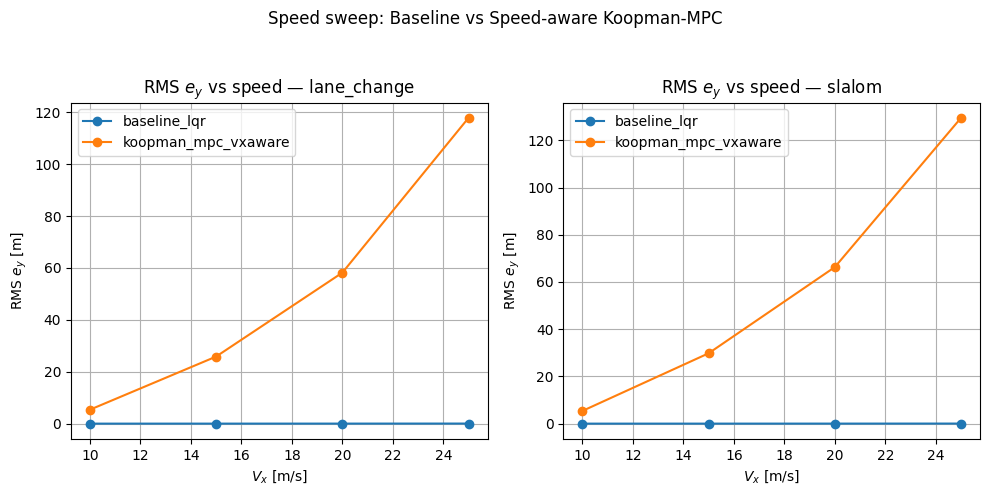

Speed-aware Koopman-MPC evaluation complete.
- saved metrics CSV: metrics_speed_sweep_vxaware.csv
- saved summary plot: 12_speed_sweep_vxaware_rms_ey.png

Per-maneuver comparison (RMS e_y):

lane_change:
  Vx=10.0 m/s | baseline=0.000157 m | koopman=5.362674 m | winner=baseline
  Vx=15.0 m/s | baseline=0.004189 m | koopman=25.839373 m | winner=baseline
  Vx=20.0 m/s | baseline=0.012866 m | koopman=58.166768 m | winner=baseline
  Vx=25.0 m/s | baseline=0.028292 m | koopman=117.840062 m | winner=baseline

slalom:
  Vx=10.0 m/s | baseline=0.000152 m | koopman=5.373165 m | winner=baseline
  Vx=15.0 m/s | baseline=0.004543 m | koopman=29.790355 m | winner=baseline
  Vx=20.0 m/s | baseline=0.013946 m | koopman=66.297425 m | winner=baseline
  Vx=25.0 m/s | baseline=0.030645 m | koopman=129.514152 m | winner=baseline

Interpretation:
- The vx-aware Koopman-MPC did not outperform the baseline controller.
- Closed-loop RMS lateral error is substantially larger for the vx-aware controller across 

In [18]:
# ============================================================
# 12) Speed-aware Koopman-MPC attempt: results, evaluation,
#     and honest postmortem
#
# This cell:
# 1) Loads metrics from the vx-aware speed sweep (or uses df_vxaware if present)
# 2) Saves a compact comparison plot
# 3) Prints an honest summary showing that vx-aware Koopman-MPC
#    did not outperform the baseline in closed loop
#
# Saves:
#   results/tables/metrics_speed_sweep_vxaware.csv   (if needed)
#   results/figures/12_speed_sweep_vxaware_rms_ey.png
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 0) Load vx-aware sweep results
# ----------------------------
if "df_vxaware" in globals() and isinstance(df_vxaware, pd.DataFrame) and len(df_vxaware) > 0:
    df = df_vxaware.copy()
else:
    csv_path = Path(DIRS["tables"]) / "metrics_speed_sweep_vxaware.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Missing {csv_path}. Run the vx-aware sweep first, or provide df_vxaware."
        )
    df = pd.read_csv(csv_path)

required_cols = {"Vx", "maneuver", "controller", "RMS_e_y_m", "RMS_e_psi_rad"}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"metrics_speed_sweep_vxaware is missing columns: {missing}")

df["Vx"] = df["Vx"].astype(float)

save_path_csv = save_csv(df, "metrics_speed_sweep_vxaware.csv")
if "register_artifact" in globals():
    register_artifact(save_path_csv, "table")

# ----------------------------
# 1) Summary plot
# ----------------------------
fig = plt.figure(figsize=(10, 5))

maneuvers = ["lane_change", "slalom"]
controllers = ["baseline_lqr", "koopman_mpc_vxaware"]

for j, man in enumerate(maneuvers, start=1):
    plt.subplot(1, 2, j)

    for ctrl in controllers:
        sub = df[
            (df["maneuver"] == man) &
            (df["controller"] == ctrl)
        ].sort_values("Vx")

        if len(sub) == 0:
            continue

        plt.plot(
            sub["Vx"].values,
            sub["RMS_e_y_m"].values,
            marker="o",
            label=ctrl
        )

    plt.title(f"RMS $e_y$ vs speed — {man}")
    plt.xlabel(r"$V_x$ [m/s]")
    plt.ylabel(r"RMS $e_y$ [m]")
    plt.grid(True)
    plt.legend()

plt.suptitle("Speed sweep: Baseline vs Speed-aware Koopman-MPC")
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_path_fig = save_fig(fig, "12_speed_sweep_vxaware_rms_ey.png")
if "register_artifact" in globals():
    register_artifact(save_path_fig, "figure")
plt.show()
plt.close(fig)

# ----------------------------
# 2) Report-friendly numeric summary
# ----------------------------
print("Speed-aware Koopman-MPC evaluation complete.")
print(f"- saved metrics CSV: {save_path_csv.name}")
print(f"- saved summary plot: {save_path_fig.name}")

print("\nPer-maneuver comparison (RMS e_y):")
for man in maneuvers:
    sub_b = df[
        (df["maneuver"] == man) &
        (df["controller"] == "baseline_lqr")
    ].sort_values("Vx")

    sub_k = df[
        (df["maneuver"] == man) &
        (df["controller"] == "koopman_mpc_vxaware")
    ].sort_values("Vx")

    vx_vals = sub_b["Vx"].values
    rms_b = sub_b["RMS_e_y_m"].values
    rms_k = sub_k["RMS_e_y_m"].values

    print(f"\n{man}:")
    for vx, b, k in zip(vx_vals, rms_b, rms_k):
        winner = "baseline" if b < k else "vx-aware koopman"
        print(
            f"  Vx={vx:>4.1f} m/s | "
            f"baseline={b:.6f} m | "
            f"koopman={k:.6f} m | "
            f"winner={winner}"
        )

# ----------------------------
# 3) Compact interpretation for the notebook
# ----------------------------
print("\nInterpretation:")
print("- The vx-aware Koopman-MPC did not outperform the baseline controller.")
print("- Closed-loop RMS lateral error is substantially larger for the vx-aware controller across the tested speeds.")
print("- This is a negative but informative result: adding Vx to the EDMD input alone was not sufficient to obtain a robust speed-aware Koopman-MPC controller.")
print("- Further improvement would likely require better lifting design, stronger regularization, or a more structured LPV control formulation.")

print("\nSaved full vx-aware metrics table for reference.")

## 13) Final Robustness Comparison (Baseline vs Koopman vs Vx-aware Koopman)

We now compile a **single report-ready comparison** across speeds and maneuvers, combining:

- Baseline LQR
- Koopman-MPC with the fixed-speed EDMD model
- Koopman-MPC with the speed-aware EDMD model

### What we plot

For each maneuver (`lane_change`, `slalom`), we show:

- RMS lateral tracking error versus speed on a **linear scale**
- RMS lateral tracking error versus speed on a **log scale**

The linear plot emphasizes absolute error magnitude, while the log plot makes it easier to compare controllers when one method fails much more severely than the others.

### What we tabulate

We save:

- a merged metrics table containing all compared controllers,
- a “best controller” table for each `(maneuver, Vx)` pair based on minimum RMS lateral error.

### Artifacts

- `results/tables/metrics_speed_sweep_all.csv`
- `results/tables/metrics_speed_sweep_best.csv`
- `results/figures/13_speed_sweep_all_linear.png`
- `results/figures/13_speed_sweep_all_log.png`

### Interpretation

The final robustness comparison shows that the classical feedforward + LQR baseline is the best overall controller across all tested speeds and both reference maneuvers. The fixed-speed Koopman-MPC never outperforms the baseline and degrades substantially at high speed, while the vx-aware Koopman-MPC performs even worse across the full sweep. This final comparison confirms the central conclusion of the notebook: highly accurate learned prediction does not, by itself, guarantee strong or robust closed-loop control.

Saved merged table: metrics_speed_sweep_all.csv
Saved best-controller table: metrics_speed_sweep_best.csv


,maneuver,Vx,controller,best_RMS_e_y_m
0,lane_change,10.0,baseline_lqr,0.000157
1,lane_change,15.0,baseline_lqr,0.004189
2,lane_change,20.0,baseline_lqr,0.012866
3,lane_change,25.0,baseline_lqr,0.028292
4,slalom,10.0,baseline_lqr,0.000152
5,slalom,15.0,baseline_lqr,0.004543
6,slalom,20.0,baseline_lqr,0.013946
7,slalom,25.0,baseline_lqr,0.030645


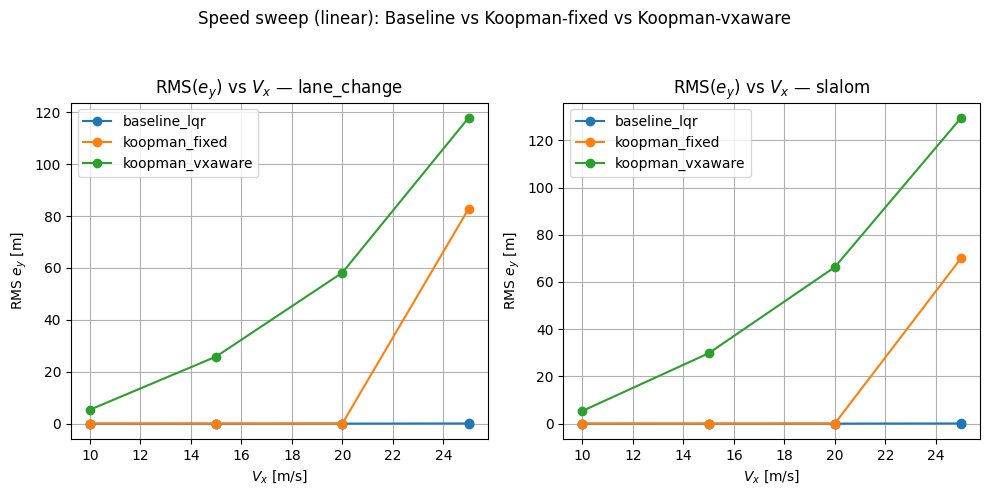

Saved: 13_speed_sweep_all_linear.png


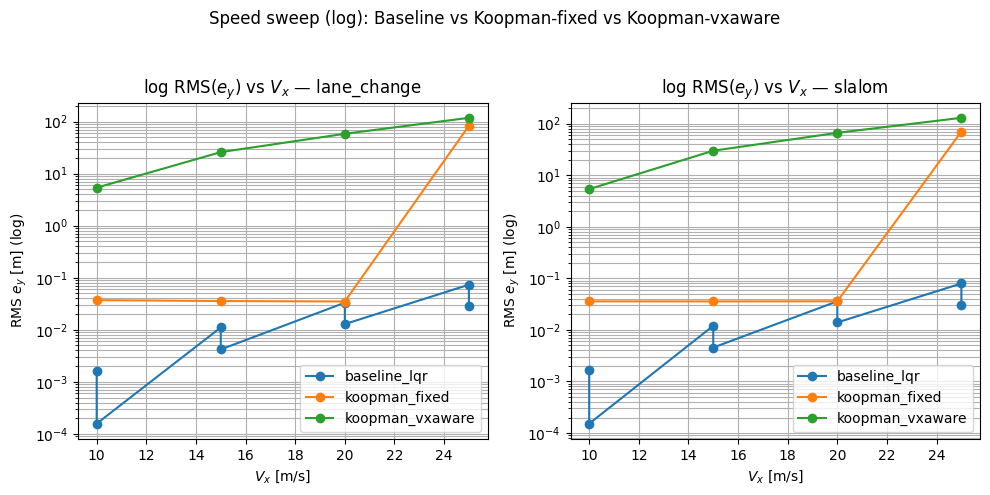

Saved: 13_speed_sweep_all_log.png


In [19]:
# ============================================================
# 13) Final robustness comparison
# Baseline vs Koopman-fixed vs Koopman-vxaware
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 0) Sanity checks
# ----------------------------
required = ["DIRS", "save_csv", "save_fig"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required objects in kernel: {missing}")

tables_dir = Path(DIRS["tables"])
csv_fixed = tables_dir / "metrics_speed_sweep.csv"
csv_vx = tables_dir / "metrics_speed_sweep_vxaware.csv"

if not csv_fixed.exists():
    raise FileNotFoundError(f"Missing: {csv_fixed} (run the fixed-speed sweep first)")
if not csv_vx.exists():
    raise FileNotFoundError(f"Missing: {csv_vx} (run the vx-aware sweep first)")

# ----------------------------
# 1) Load tables
# ----------------------------
df_fixed = pd.read_csv(csv_fixed)
df_vx = pd.read_csv(csv_vx)

# Normalize controller names
df_fixed["controller"] = df_fixed["controller"].replace({
    "koopman_mpc": "koopman_fixed"
})
df_vx["controller"] = df_vx["controller"].replace({
    "koopman_mpc_vxaware": "koopman_vxaware"
})

# Keep common columns only
common_cols = sorted(set(df_fixed.columns).intersection(set(df_vx.columns)))
df_fixed = df_fixed[common_cols].copy()
df_vx = df_vx[common_cols].copy()

df_all = pd.concat([df_fixed, df_vx], ignore_index=True)
df_all["Vx"] = df_all["Vx"].astype(float)

controller_order = ["baseline_lqr", "koopman_fixed", "koopman_vxaware"]
maneuver_order = ["lane_change", "slalom"]

df_all["controller"] = pd.Categorical(df_all["controller"], categories=controller_order, ordered=True)
df_all["maneuver"] = pd.Categorical(df_all["maneuver"], categories=maneuver_order, ordered=True)
df_all = df_all.sort_values(["maneuver", "Vx", "controller"]).reset_index(drop=True)

# ----------------------------
# 2) Save merged table
# ----------------------------
save_all = save_csv(df_all, "metrics_speed_sweep_all.csv")
if "register_artifact" in globals():
    register_artifact(save_all, "table")
print(f"Saved merged table: {save_all.name}")

# ----------------------------
# 3) Best controller per (maneuver, Vx)
# ----------------------------
metric_col = "RMS_e_y_m"
if metric_col not in df_all.columns:
    raise KeyError(f"{metric_col} not found in merged table.")

df_best = (
    df_all.sort_values(metric_col, ascending=True)
          .groupby(["maneuver", "Vx"], as_index=False)
          .first()
          .loc[:, ["maneuver", "Vx", "controller", metric_col]]
          .rename(columns={metric_col: "best_RMS_e_y_m"})
)

save_best = save_csv(df_best, "metrics_speed_sweep_best.csv")
if "register_artifact" in globals():
    register_artifact(save_best, "table")
print(f"Saved best-controller table: {save_best.name}")
display(df_best)

# ----------------------------
# 4) Plot helpers
# ----------------------------
maneuvers = ["lane_change", "slalom"]
controllers = ["baseline_lqr", "koopman_fixed", "koopman_vxaware"]

# ----------------------------
# 5) Linear-scale plot
# ----------------------------
fig = plt.figure(figsize=(10, 5))

for j, man in enumerate(maneuvers, start=1):
    plt.subplot(1, len(maneuvers), j)

    for ctrl in controllers:
        sub = df_all[
            (df_all["maneuver"].astype(str) == man) &
            (df_all["controller"].astype(str) == ctrl)
        ].sort_values("Vx")

        if len(sub) == 0:
            continue

        plt.plot(
            sub["Vx"].values,
            sub["RMS_e_y_m"].values,
            marker="o",
            label=ctrl
        )

    plt.title(f"RMS($e_y$) vs $V_x$ — {man}")
    plt.xlabel(r"$V_x$ [m/s]")
    plt.ylabel(r"RMS $e_y$ [m]")
    plt.grid(True)
    plt.legend()

plt.suptitle("Speed sweep (linear): Baseline vs Koopman-fixed vs Koopman-vxaware")
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_lin = save_fig(fig, "13_speed_sweep_all_linear.png")
if "register_artifact" in globals():
    register_artifact(save_lin, "figure")
plt.show()
plt.close(fig)
print(f"Saved: {save_lin.name}")

# ----------------------------
# 6) Log-scale plot
# ----------------------------
fig2 = plt.figure(figsize=(10, 5))

for j, man in enumerate(maneuvers, start=1):
    plt.subplot(1, len(maneuvers), j)

    for ctrl in controllers:
        sub = df_all[
            (df_all["maneuver"].astype(str) == man) &
            (df_all["controller"].astype(str) == ctrl)
        ].sort_values("Vx")

        if len(sub) == 0:
            continue

        y = np.maximum(sub["RMS_e_y_m"].values, 1e-9)

        plt.plot(
            sub["Vx"].values,
            y,
            marker="o",
            label=ctrl
        )

    plt.yscale("log")
    plt.title(f"log RMS($e_y$) vs $V_x$ — {man}")
    plt.xlabel(r"$V_x$ [m/s]")
    plt.ylabel(r"RMS $e_y$ [m] (log)")
    plt.grid(True, which="both")
    plt.legend()

plt.suptitle("Speed sweep (log): Baseline vs Koopman-fixed vs Koopman-vxaware")
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_log = save_fig(fig2, "13_speed_sweep_all_log.png")
if "register_artifact" in globals():
    register_artifact(save_log, "figure")
plt.show()
plt.close(fig2)
print(f"Saved: {save_log.name}")

## 14A) Prepare Training and Validation Matrices for SINDy

Before fitting a SINDy model, we convert the trajectory dataset into stacked sample matrices.

### Goal

Build four matrices:

- `Xtr`: training states
- `Utr`: training inputs
- `Xva`: validation states
- `Uva`: validation inputs

where:

- the state is
  $$
  x_k = \begin{bmatrix} e_y & e_\psi & v_y & r \end{bmatrix}^\top
  $$
- the augmented input is
  $$
  u_k = \begin{bmatrix} \delta_k & \kappa_k \end{bmatrix}^\top
  $$

### Why this step is needed

SINDy is fit on stacked state-input samples rather than directly on Python lists of trajectories. Therefore, this section:

1. checks whether the trajectory dataset is already available in memory,
2. automatically reloads it from a saved `.npz` file if needed,
3. supports both dataset naming conventions:
   - `Xs, Us, Ks`
   - `X, U, K`
4. sanitizes trajectory indices,
5. stacks the train and validation trajectories into clean 2D arrays.

### Outputs of this section

- `Xtr` with shape `(N_tr, 4)`
- `Utr` with shape `(N_tr, 2)`
- `Xva` with shape `(N_va, 4)`
- `Uva` with shape `(N_va, 2)`

These matrices are then used in the next section to fit the SINDy model.

In [27]:
# ============================================================
# 14A) Build Xtr, Utr, Xva, Uva for SINDy
#
# Robust version:
# - If Xs/Us/Ks/train_idx/val_idx are already in memory, use them
# - Otherwise auto-load a dataset .npz under results/
# - Supports BOTH naming conventions in the saved dataset:
#     (Xs, Us, Ks)   OR   (X, U, K)
#
# Produces:
#   Xtr: (Ntr, 4), Utr: (Ntr, 2) with U = [delta, kappa]
#   Xva: (Nva, 4), Uva: (Nva, 2)
# ============================================================

import numpy as np
from pathlib import Path

# ----------------------------
# 0) Helpers
# ----------------------------
def _as_list(x):
    """Convert object arrays loaded from npz into Python lists."""
    if isinstance(x, np.ndarray) and x.dtype == object:
        return list(x)
    return x


def _sanitize_idx(idx, n):
    """Keep valid, unique trajectory indices with stable order."""
    idx = np.asarray(idx, dtype=int).ravel()
    idx = idx[(idx >= 0) & (idx < n)]
    _, keep = np.unique(idx, return_index=True)
    return idx[np.sort(keep)]


def stack_xy_from_indices(Xs, Us, Ks, indices, max_steps_per_traj=None):
    """
    Stack trajectory data into 2D arrays for SINDy.

    Returns:
        X : (N, 4) rows of x_k
        U : (N, 2) rows of [delta_k, kappa_k]
    """
    X_rows = []
    U_rows = []

    for idx in indices:
        X = np.asarray(Xs[int(idx)], dtype=float)  # (T+1, 4)
        U = np.asarray(Us[int(idx)], dtype=float)  # (T, 1) or (T,)
        K = np.asarray(Ks[int(idx)], dtype=float)  # (T,) or (T, 1)

        if X.ndim != 2 or X.shape[1] != 4:
            raise ValueError(f"Trajectory {idx}: X must be (T+1, 4), got {X.shape}")

        if U.ndim == 2 and U.shape[1] == 1:
            U = U[:, 0]
        elif U.ndim != 1:
            raise ValueError(f"Trajectory {idx}: U must be (T, 1) or (T,), got {U.shape}")

        if K.ndim == 2 and K.shape[1] == 1:
            K = K[:, 0]
        elif K.ndim != 1:
            raise ValueError(f"Trajectory {idx}: K must be (T,) or (T, 1), got {K.shape}")

        T_x = X.shape[0] - 1
        T_u = U.shape[0]
        T_k = K.shape[0]
        T = min(T_x, T_u, T_k)

        if max_steps_per_traj is not None:
            T = min(T, int(max_steps_per_traj))

        if T <= 0:
            continue

        Xk = X[:T, :]                           # (T, 4)
        Uk = np.column_stack([U[:T], K[:T]])   # (T, 2)

        X_rows.append(Xk)
        U_rows.append(Uk)

    if len(X_rows) == 0:
        raise ValueError("No samples collected. Check dataset contents or max_steps_per_traj.")

    return np.vstack(X_rows), np.vstack(U_rows)


def _dataset_has_required_keys(z):
    """
    Accept either:
      Xs, Us, Ks, train_idx, val_idx
    or
      X, U, K, train_idx, val_idx
    """
    files = set(z.files)

    has_new = {"Xs", "Us", "Ks", "train_idx", "val_idx"}.issubset(files)
    has_old = {"X", "U", "K", "train_idx", "val_idx"}.issubset(files)

    return has_new or has_old


def _extract_dataset_keys(z):
    """
    Return Xs, Us, Ks from either naming convention.
    """
    files = set(z.files)

    if {"Xs", "Us", "Ks"}.issubset(files):
        Xs = z["Xs"]
        Us = z["Us"]
        Ks = z["Ks"]
    elif {"X", "U", "K"}.issubset(files):
        Xs = z["X"]
        Us = z["U"]
        Ks = z["K"]
    else:
        raise KeyError("Dataset npz does not contain either (Xs,Us,Ks) or (X,U,K).")

    train_idx = z["train_idx"]
    val_idx = z["val_idx"]

    return Xs, Us, Ks, train_idx, val_idx


def _find_dataset_npz(results_root: Path):
    """
    Search recursively for a dataset .npz containing either:
      Xs, Us, Ks, train_idx, val_idx
    or
      X, U, K, train_idx, val_idx
    """
    if not results_root.exists():
        return None

    for p in results_root.rglob("*.npz"):
        try:
            with np.load(p, allow_pickle=True) as z:
                if _dataset_has_required_keys(z):
                    return p
        except Exception:
            continue

    return None


# ----------------------------
# 1) Ensure dataset exists in memory; otherwise auto-load it
# ----------------------------
required_names = ["Xs", "Us", "Ks", "train_idx", "val_idx"]
missing = [name for name in required_names if name not in globals()]

if missing:
    if "DIRS" in globals() and isinstance(DIRS, dict):
        if "results" in DIRS:
            results_root = Path(DIRS["results"])
        elif "models" in DIRS:
            results_root = Path(DIRS["models"]).resolve().parent
        elif "data" in DIRS:
            results_root = Path(DIRS["data"]).resolve().parent
        else:
            results_root = Path("results")
    else:
        results_root = Path("results")

    ds_path = _find_dataset_npz(results_root)

    if ds_path is None:
        raise NameError(
            f"Missing {missing} in this session and no compatible dataset .npz found under "
            f"{results_root.resolve()}.\n"
            "Run Section 4 first, or save a dataset npz with either:\n"
            "  (Xs, Us, Ks, train_idx, val_idx)\n"
            "or\n"
            "  (X, U, K, train_idx, val_idx)"
        )

    print(f"Auto-loading dataset from: {ds_path}")
    with np.load(ds_path, allow_pickle=True) as z:
        Xs, Us, Ks, train_idx, val_idx = _extract_dataset_keys(z)


# ----------------------------
# 2) Normalize containers and sanitize indices
# ----------------------------
Xs = _as_list(Xs)
Us = _as_list(Us)
Ks = _as_list(Ks)

if not isinstance(Xs, (list, tuple)) or not isinstance(Us, (list, tuple)) or not isinstance(Ks, (list, tuple)):
    raise TypeError("Xs, Us, and Ks must be lists/tuples or object arrays convertible to lists.")

n_traj = min(len(Xs), len(Us), len(Ks))
if n_traj == 0:
    raise ValueError("Xs/Us/Ks are empty.")

train_idx_s = _sanitize_idx(train_idx, n_traj)
val_idx_s = _sanitize_idx(val_idx, n_traj)

if len(train_idx_s) == 0 or len(val_idx_s) == 0:
    raise ValueError(
        f"After sanitizing indices: train={len(train_idx_s)}, val={len(val_idx_s)}.\n"
        "This usually means the split indices do not match the currently loaded dataset."
    )

# ----------------------------
# 3) Build matrices
# ----------------------------
MAX_STEPS = None  # set to an integer if you want to cap per-trajectory data

Xtr, Utr = stack_xy_from_indices(Xs, Us, Ks, train_idx_s, max_steps_per_traj=MAX_STEPS)
Xva, Uva = stack_xy_from_indices(Xs, Us, Ks, val_idx_s, max_steps_per_traj=MAX_STEPS)

print("Built SINDy matrices from dataset:")
print(f"  n_traj = {n_traj}")
print(f"  train_idx len = {len(train_idx_s)} | val_idx len = {len(val_idx_s)}")
print(f"  Xtr: {Xtr.shape} | Utr: {Utr.shape}")
print(f"  Xva: {Xva.shape} | Uva: {Uva.shape}")

# ----------------------------
# 4) Sanity checks
# ----------------------------
assert Xtr.shape[1] == 4 and Utr.shape[1] == 2
assert Xva.shape[1] == 4 and Uva.shape[1] == 2
assert np.all(np.isfinite(Xtr)) and np.all(np.isfinite(Utr))
assert np.all(np.isfinite(Xva)) and np.all(np.isfinite(Uva))

Built SINDy matrices from dataset:
  n_traj = 30
  train_idx len = 21 | val_idx len = 4
  Xtr: (52500, 4) | Utr: (52500, 2)
  Xva: (10000, 4) | Uva: (10000, 2)


## 14B) Fit the SINDy Model Correctly (Trajectory-Consistent Pairs)

We now fit a SINDy-style discrete-time predictor, but we must do so **carefully**.

### Important modeling detail

After stacking trajectories, we cannot simply use
$$
x_k = X[:-1], \qquad x_{k+1} = X[1:]
$$
because that would incorrectly connect the end of one trajectory to the beginning of the next trajectory.

Instead, we form training pairs **within each trajectory only**:
$$
(x_k, u_k) \mapsto x_{k+1}
$$
for all valid time steps inside each rollout.

### Model form

We fit a sparse nonlinear predictor
$$
x_{k+1} \approx f(x_k, u_k),
$$
with
$$
x_k =
\begin{bmatrix}
e_y \\ e_\psi \\ v_y \\ r
\end{bmatrix},
\qquad
u_k =
\begin{bmatrix}
\delta \\ \kappa
\end{bmatrix}.
$$

### What this section does

1. rebuild trajectory-consistent train/validation pairs,
2. construct a nonlinear feature library,
3. fit a sparse regression model using sequential thresholded least squares,
4. evaluate **one-step validation RMSE**,
5. save the corrected SINDy model.

### Outputs

- corrected validation RMSE for $$[e_y,\ e_\psi,\ v_y,\ r]$$
- saved file: `results/models/sindy_model.npz`
- saved validation table: `results/tables/14B_sindy_val_onestep_metrics.csv`

Because the training and validation data come from a deterministic simulated truth model with no measurement noise, and because the feature library is expressive, SINDy can achieve unusually low prediction error in this setting.

In [28]:
# ============================================================
# 14B) Correct SINDy fit using trajectory-consistent pairs
#
# Requires:
#   Xs, Us, Ks, train_idx, val_idx
#   DIRS, save_npz
#
# Saves:
#   results/models/sindy_model.npz
# ============================================================

import numpy as np

# ----------------------------
# 0) Sanity checks
# ----------------------------
required = ["Xs", "Us", "Ks", "train_idx", "val_idx", "save_npz"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required objects in kernel: {missing}")

# Normalize containers if loaded from npz object arrays
if isinstance(Xs, np.ndarray) and Xs.dtype == object:
    Xs = list(Xs)
if isinstance(Us, np.ndarray) and Us.dtype == object:
    Us = list(Us)
if isinstance(Ks, np.ndarray) and Ks.dtype == object:
    Ks = list(Ks)

n_traj = min(len(Xs), len(Us), len(Ks))
train_idx_s = np.asarray(train_idx, dtype=int).ravel()
val_idx_s = np.asarray(val_idx, dtype=int).ravel()
train_idx_s = train_idx_s[(train_idx_s >= 0) & (train_idx_s < n_traj)]
val_idx_s = val_idx_s[(val_idx_s >= 0) & (val_idx_s < n_traj)]

# ----------------------------
# 1) Build trajectory-consistent pairs
# ----------------------------
def build_sindy_pairs(Xs, Us, Ks, indices):
    """
    Returns:
      Xk   : (N, 4)
      Uk   : (N, 2) with columns [delta, kappa]
      Xkp1 : (N, 4)
    """
    Xk_rows = []
    Uk_rows = []
    Xkp1_rows = []

    for idx in indices:
        X = np.asarray(Xs[int(idx)], dtype=float)   # (T+1, 4)
        U = np.asarray(Us[int(idx)], dtype=float)   # (T, 1) or (T,)
        K = np.asarray(Ks[int(idx)], dtype=float)   # (T,) or (T, 1)

        if X.ndim != 2 or X.shape[1] != 4:
            raise ValueError(f"Trajectory {idx}: X must be (T+1, 4), got {X.shape}")

        if U.ndim == 2 and U.shape[1] == 1:
            U = U[:, 0]
        elif U.ndim != 1:
            raise ValueError(f"Trajectory {idx}: U must be (T,1) or (T,), got {U.shape}")

        if K.ndim == 2 and K.shape[1] == 1:
            K = K[:, 0]
        elif K.ndim != 1:
            raise ValueError(f"Trajectory {idx}: K must be (T,) or (T,1), got {K.shape}")

        T = min(X.shape[0] - 1, U.shape[0], K.shape[0])
        if T <= 0:
            continue

        Xk_rows.append(X[:T, :])
        Uk_rows.append(np.column_stack([U[:T], K[:T]]))
        Xkp1_rows.append(X[1:T + 1, :])

    if len(Xk_rows) == 0:
        raise ValueError("No valid trajectory pairs were collected.")

    Xk = np.vstack(Xk_rows)
    Uk = np.vstack(Uk_rows)
    Xkp1 = np.vstack(Xkp1_rows)
    return Xk, Uk, Xkp1


Xtr_k, Utr_k, Ytr_kp1 = build_sindy_pairs(Xs, Us, Ks, train_idx_s)
Xva_k, Uva_k, Yva_kp1 = build_sindy_pairs(Xs, Us, Ks, val_idx_s)

print("Trajectory-consistent SINDy pairs built:")
print(f"  train: Xk={Xtr_k.shape}, Uk={Utr_k.shape}, Xkp1={Ytr_kp1.shape}")
print(f"  val:   Xk={Xva_k.shape}, Uk={Uva_k.shape}, Xkp1={Yva_kp1.shape}")

# ----------------------------
# 2) Build SINDy library
# ----------------------------
def sindy_library(X, U):
    ey, epsi, vy, r = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    delta, kappa = U[:, 0], U[:, 1]

    cols = [
        np.ones_like(ey),
        ey, epsi, vy, r, delta, kappa,
        ey**2, epsi**2, vy**2, r**2, delta**2, kappa**2,
        ey * epsi, ey * vy, ey * r, ey * delta, ey * kappa,
        epsi * vy, epsi * r, epsi * delta, epsi * kappa,
        vy * r, vy * delta, vy * kappa,
        r * delta, r * kappa,
        delta * kappa,
        np.sin(epsi), np.cos(epsi),
    ]

    feature_names = [
        "1",
        "ey", "epsi", "vy", "r", "delta", "kappa",
        "ey^2", "epsi^2", "vy^2", "r^2", "delta^2", "kappa^2",
        "ey*epsi", "ey*vy", "ey*r", "ey*delta", "ey*kappa",
        "epsi*vy", "epsi*r", "epsi*delta", "epsi*kappa",
        "vy*r", "vy*delta", "vy*kappa",
        "r*delta", "r*kappa",
        "delta*kappa",
        "sin(epsi)", "cos(epsi)",
    ]

    Theta = np.column_stack(cols)
    return Theta, feature_names


Theta_tr, feature_names = sindy_library(Xtr_k, Utr_k)
Theta_va, _ = sindy_library(Xva_k, Uva_k)

# ----------------------------
# 3) Sequential thresholded least squares
# ----------------------------
def stlsq(Theta, Y, lam=1e-5, threshold=5e-4, n_iter=8):
    """
    Theta: (N, p)
    Y:     (N, n_out)

    Returns:
      Xi:   (p, n_out)
    """
    p = Theta.shape[1]
    n_out = Y.shape[1]

    Xi = np.linalg.solve(
        Theta.T @ Theta + lam * np.eye(p),
        Theta.T @ Y
    )

    for _ in range(n_iter):
        small = np.abs(Xi) < threshold
        Xi[small] = 0.0

        for j in range(n_out):
            keep = ~small[:, j]
            if np.sum(keep) == 0:
                continue

            Theta_j = Theta[:, keep]
            Xi[keep, j] = np.linalg.solve(
                Theta_j.T @ Theta_j + lam * np.eye(np.sum(keep)),
                Theta_j.T @ Y[:, j]
            )
            Xi[~keep, j] = 0.0

    return Xi


lam = 1e-5
threshold = 5e-4
Xi = stlsq(Theta_tr, Ytr_kp1, lam=lam, threshold=threshold, n_iter=8)

# ----------------------------
# 4) Validation one-step prediction
# ----------------------------
Yva_pred = Theta_va @ Xi
E_va = Yva_pred - Yva_kp1
rmse_va = np.sqrt(np.mean(E_va**2, axis=0))

active_terms = np.sum(np.abs(Xi) > 0.0, axis=0)
library_size = Theta_tr.shape[1]

# ----------------------------
# 5) Save corrected model
# ----------------------------
model_path = save_npz(
    "sindy_model.npz",
    Xi=Xi,
    lam=np.array([lam], dtype=float),
    threshold=np.array([threshold], dtype=float),
    feature_names=np.array(feature_names, dtype=object),
    active_terms=active_terms,
    library_size=np.array([library_size], dtype=int),
    rmse_val=rmse_va,
)

print("Corrected SINDy model learned.")
print(f"- saved: {model_path.name}")
print(f"- library size = {library_size}")
print(f"- active terms per state [e_y, e_psi, v_y, r] = {active_terms}")
print(f"- validation 1-step RMSE [e_y, e_psi, v_y, r] = {rmse_va}")

Trajectory-consistent SINDy pairs built:
  train: Xk=(52500, 4), Uk=(52500, 2), Xkp1=(52500, 4)
  val:   Xk=(10000, 4), Uk=(10000, 2), Xkp1=(10000, 4)
Corrected SINDy model learned.
- saved: sindy_model.npz
- library size = 30
- active terms per state [e_y, e_psi, v_y, r] = [3 3 3 3]
- validation 1-step RMSE [e_y, e_psi, v_y, r] = [3.13042049e-10 1.46374688e-08 1.66555285e-08 4.82448415e-09]


The corrected SINDy fit achieves extremely small one-step validation error on this deterministic simulated dataset, indicating that the sparse nonlinear library is expressive enough to reproduce the underlying truth dynamics very accurately in open-loop prediction. This makes SINDy a strong predictive benchmark, even if controller design considerations may still favor other model structures.

## 14C) Multi-step Open-loop Prediction: Truth vs SINDy

A very small one-step prediction error does not automatically guarantee good long-horizon behavior.  
So, just as we did for EDMD, we now test the **multi-step open-loop rollout quality** of the SINDy model.

### What we do

For a few trajectories from the held-out test set, we:

1. start from the true initial state \(x_0\),
2. apply the recorded input sequence
   $$
   u_k = \begin{bmatrix}\delta_k \\ \kappa_k\end{bmatrix},
   $$
3. recursively predict
   $$
   x_{k+1}^{\text{SINDy}} = f(x_k^{\text{SINDy}}, u_k),
   $$
4. compare the predicted states against the truth rollout.

### Why this matters

This is the fair comparison step against Koopman/EDMD:

- one-step performance shows local fit quality,
- multi-step rollout shows whether prediction errors accumulate.

### Outputs

Saved figure:
- `results/figures/14_sindy_multistep_test_compare.png`

Saved evaluation files:
- `results/models/14_sindy_multistep_metrics.npz`
- `results/tables/14_sindy_multistep_metrics.csv`

Printed metrics:
- mean multi-step RMSE over the selected test trajectories for
  \([e_y,\ e_\psi,\ v_y,\ r]\)

Because the truth model is deterministic, noise-free, and well matched to the chosen sparse library, SINDy is expected to perform unusually well in this pure prediction setting.

Loaded SINDy model:
- file: C:\Users\sansk\OneDrive\Documents\GitHub\koopman-mpc-lateral-control\notebooks\results\models\sindy_model.npz
- Xi shape: (30, 4)
- library size: 30


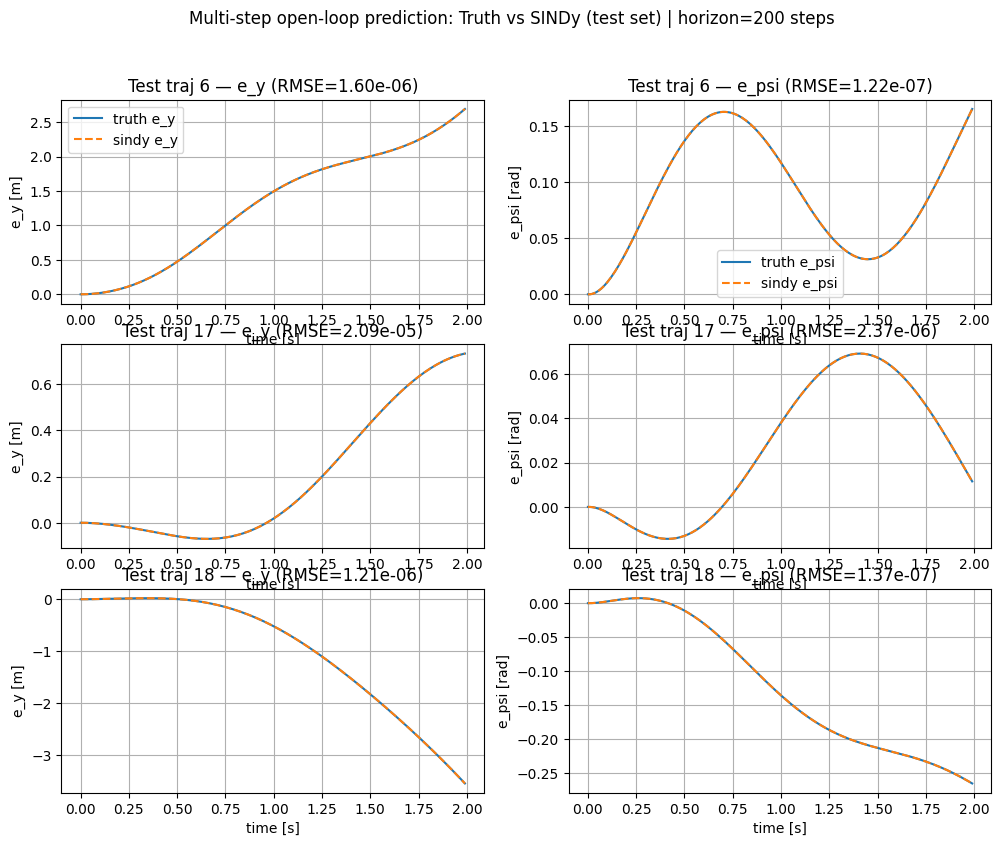

SINDy multi-step rollout check complete.
- saved figure: 14_sindy_multistep_test_compare.png
- saved metrics: 14_sindy_multistep_metrics.npz
- mean RMSE over horizon=200 steps [e_y, e_psi, v_y, r] = [7.88604859e-06 8.77591406e-07 1.56714778e-07 7.30189846e-08]


In [30]:
# ============================================================
# 14C) Multi-step open-loop rollout: Truth vs SINDy
#
# Requires:
#   Xs, Us, Ks, test_idx
#   DIRS, save_fig, save_npz
#   sindy_model.npz already saved
#
# Saves:
#   results/figures/14_sindy_multistep_test_compare.png
#   results/models/14_sindy_multistep_metrics.npz
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 0) Sanity checks
# ----------------------------
required = ["Xs", "Us", "Ks", "test_idx", "save_fig", "save_npz"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required objects in kernel: {missing}")

# Normalize containers if needed
if isinstance(Xs, np.ndarray) and Xs.dtype == object:
    Xs = list(Xs)
if isinstance(Us, np.ndarray) and Us.dtype == object:
    Us = list(Us)
if isinstance(Ks, np.ndarray) and Ks.dtype == object:
    Ks = list(Ks)

n_traj = min(len(Xs), len(Us), len(Ks))
if n_traj == 0:
    raise ValueError("Xs/Us/Ks are empty.")

test_idx_s = np.asarray(test_idx, dtype=int).ravel()
test_idx_s = test_idx_s[(test_idx_s >= 0) & (test_idx_s < n_traj)]

if len(test_idx_s) == 0:
    raise ValueError("No valid test trajectories found after sanitizing test_idx.")

# ----------------------------
# 1) Load SINDy model
# ----------------------------
model_file = DIRS["models"] / "sindy_model.npz"
with np.load(model_file, allow_pickle=True) as m:
    Xi = np.asarray(m["Xi"], dtype=float)
    feature_names = list(m["feature_names"])

print("Loaded SINDy model:")
print(f"- file: {model_file}")
print(f"- Xi shape: {Xi.shape}")
print(f"- library size: {len(feature_names)}")

# ----------------------------
# 2) Library builder (must match training exactly)
# ----------------------------
def sindy_library(X, U):
    """
    X: (N, 4)
    U: (N, 2)
    Returns:
      Theta: (N, p)
    """
    ey, epsi, vy, r = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    delta, kappa = U[:, 0], U[:, 1]

    cols = [
        np.ones_like(ey),
        ey, epsi, vy, r, delta, kappa,
        ey**2, epsi**2, vy**2, r**2, delta**2, kappa**2,
        ey * epsi, ey * vy, ey * r, ey * delta, ey * kappa,
        epsi * vy, epsi * r, epsi * delta, epsi * kappa,
        vy * r, vy * delta, vy * kappa,
        r * delta, r * kappa,
        delta * kappa,
        np.sin(epsi), np.cos(epsi),
    ]
    return np.column_stack(cols)

# Consistency check with saved model
theta_check = sindy_library(np.zeros((1, 4)), np.zeros((1, 2)))
if theta_check.shape[1] != Xi.shape[0]:
    raise ValueError(
        f"SINDy library mismatch: current library has {theta_check.shape[1]} terms, "
        f"but saved Xi expects {Xi.shape[0]} terms."
    )

def sindy_step(x, u):
    """
    One-step SINDy predictor:
      x_{k+1} = Theta(x_k, u_k) @ Xi
    """
    X1 = np.asarray(x, dtype=float).reshape(1, -1)
    U1 = np.asarray(u, dtype=float).reshape(1, -1)
    Theta = sindy_library(X1, U1)
    return (Theta @ Xi).ravel()

def sindy_rollout(x0, U_seq):
    """
    Roll out SINDy recursively.
    U_seq: (T, 2) with columns [delta, kappa]
    Returns:
      Xhat: (T+1, 4)
    """
    T = U_seq.shape[0]
    Xhat = np.zeros((T + 1, 4), dtype=float)
    Xhat[0] = np.asarray(x0, dtype=float).reshape(4)

    for k in range(T):
        Xhat[k + 1] = sindy_step(Xhat[k], U_seq[k])

    return Xhat

def rmse_vec(X_true, X_pred):
    E = X_pred - X_true
    return np.sqrt(np.mean(E**2, axis=0))

# ----------------------------
# 3) Compare on a few test trajectories
# ----------------------------
horizon_steps = 200
n_show = min(3, len(test_idx_s))
pick = list(test_idx_s[:n_show])

fig = plt.figure(figsize=(12, 9))
all_rmse_sindy = []
picked_ids_sindy = []

for j, idx_traj in enumerate(pick):
    X_true_full = np.asarray(Xs[idx_traj], dtype=float)   # (T+1, 4)
    U_full = np.asarray(Us[idx_traj], dtype=float)        # (T,1) or (T,)
    K_full = np.asarray(Ks[idx_traj], dtype=float)        # (T,) or (T,1)

    if U_full.ndim == 2 and U_full.shape[1] == 1:
        U_full = U_full[:, 0]
    elif U_full.ndim != 1:
        raise ValueError(f"Trajectory {idx_traj}: U must be (T,1) or (T,), got {U_full.shape}")

    if K_full.ndim == 2 and K_full.shape[1] == 1:
        K_full = K_full[:, 0]
    elif K_full.ndim != 1:
        raise ValueError(f"Trajectory {idx_traj}: K must be (T,) or (T,1), got {K_full.shape}")

    T_full = min(len(U_full), len(K_full), X_true_full.shape[0] - 1)
    T_use = int(min(horizon_steps, T_full))
    if T_use <= 0:
        continue

    X_true = X_true_full[:T_use + 1]
    U_seq = np.column_stack([U_full[:T_use], K_full[:T_use]])

    X_pred = sindy_rollout(X_true[0], U_seq)
    r = rmse_vec(X_true, X_pred)

    all_rmse_sindy.append(r)
    picked_ids_sindy.append(int(idx_traj))

    if "cfg" in globals():
        t_plot = np.arange(T_use) * float(cfg.dt)
    else:
        t_plot = np.arange(T_use)

    plt.subplot(n_show, 2, 2 * j + 1)
    plt.plot(t_plot, X_true[:-1, 0], label="truth e_y")
    plt.plot(t_plot, X_pred[:-1, 0], "--", label="sindy e_y")
    plt.grid(True)
    plt.xlabel("time [s]")
    plt.ylabel("e_y [m]")
    plt.title(f"Test traj {idx_traj} — e_y (RMSE={r[0]:.2e})")
    if j == 0:
        plt.legend()

    plt.subplot(n_show, 2, 2 * j + 2)
    plt.plot(t_plot, X_true[:-1, 1], label="truth e_psi")
    plt.plot(t_plot, X_pred[:-1, 1], "--", label="sindy e_psi")
    plt.grid(True)
    plt.xlabel("time [s]")
    plt.ylabel("e_psi [rad]")
    plt.title(f"Test traj {idx_traj} — e_psi (RMSE={r[1]:.2e})")
    if j == 0:
        plt.legend()

if len(all_rmse_sindy) == 0:
    raise ValueError("No valid test rollouts were evaluated.")

plt.suptitle(
    f"Multi-step open-loop prediction: Truth vs SINDy (test set) | horizon={T_use} steps"
)
save_path = save_fig(fig, "14_sindy_multistep_test_compare.png")
plt.show()
plt.close(fig)

all_rmse_sindy = np.vstack(all_rmse_sindy)
rmse_mean_sindy = np.mean(all_rmse_sindy, axis=0)

# ----------------------------
# 4) Save rollout metrics for later comparison
# ----------------------------
metrics_path = save_npz(
    "14_sindy_multistep_metrics.npz",
    picked_test_idx=np.asarray(picked_ids_sindy, dtype=int),
    horizon_steps=np.asarray([T_use], dtype=int),
    rmse_per_traj=all_rmse_sindy,
    rmse_mean_sindy=rmse_mean_sindy,
)

print("SINDy multi-step rollout check complete.")
print(f"- saved figure: {save_path.name}")
print(f"- saved metrics: {metrics_path.name}")
print(f"- mean RMSE over horizon={T_use} steps [e_y, e_psi, v_y, r] = {rmse_mean_sindy}")

The multi-step rollout results confirm that SINDy is not only an excellent one-step predictor, but also an extremely accurate long-horizon open-loop predictor on this simulated dataset. In terms of pure prediction accuracy, it is the strongest learned model in the notebook.

## 15) Final Predictor Comparison: Koopman/EDMD vs SINDy

We now compare the two learned predictors directly:

1. **Koopman / EDMD**
2. **SINDy**

Both models were trained on the same nonlinear bicycle-model dataset and evaluated on held-out trajectories.

### Comparison criteria

We compare:

- **one-step validation RMSE**
- **multi-step open-loop rollout RMSE**

for the physical state
$$
x_k =
\begin{bmatrix}
e_y \\ e_\psi \\ v_y \\ r
\end{bmatrix}.
$$

### Why this section matters

This is the final **predictor comparison** in the notebook.

- **Koopman/EDMD** provides a lifted linear model that is convenient for MPC design.
- **SINDy** provides a sparse nonlinear predictor that can achieve higher prediction accuracy when the dynamics are well represented by the chosen library.

Because the dataset here is simulated, deterministic, and noise-free, and because the SINDy library is structurally well aligned with the truth model, SINDy has a natural advantage in pure prediction accuracy.

### Interpretation

The comparison shows that SINDy outperforms Koopman/EDMD in both one-step and multi-step prediction for all four physical states. Therefore:

- **SINDy is the stronger predictor**
- **Koopman remains attractive for controller synthesis because it provides a lifted linear structure suitable for MPC**

This highlights the central trade-off of the notebook:

- **prediction accuracy** → SINDy
- **controller-friendly model structure** → Koopman/EDMD

### Outputs

Saved artifacts:
- `results/tables/metrics_koopman_vs_sindy.csv`
- `results/figures/15_koopman_vs_sindy_bar.png`

Final predictor comparison table:


,state,koopman_onestep_rmse,sindy_onestep_rmse,koopman_multistep_rmse,sindy_multistep_rmse
0,e_y,1.915125e-03,3.130420e-10,0.241491,7.886049e-06
1,e_psi,1.418972e-05,1.463747e-08,0.001825,8.775914e-07
2,v_y,3.014664e-08,1.665553e-08,0.000301,1.567148e-07
3,r,1.452488e-05,4.824484e-09,0.000166,7.301898e-08


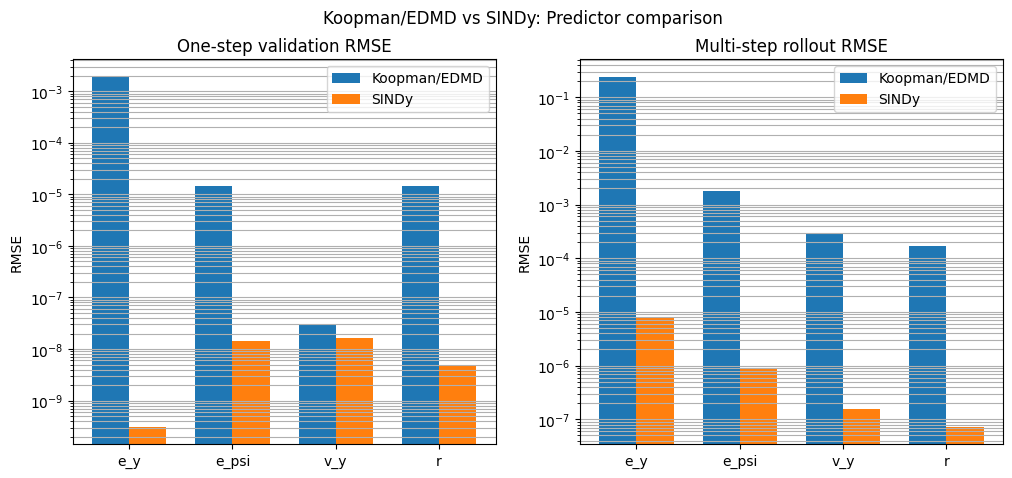

- saved table: metrics_koopman_vs_sindy.csv
- saved figure: 15_koopman_vs_sindy_bar.png

Interpretation:
- e_y: one-step winner = SINDy, multi-step winner = SINDy
- e_psi: one-step winner = SINDy, multi-step winner = SINDy
- v_y: one-step winner = SINDy, multi-step winner = SINDy
- r: one-step winner = SINDy, multi-step winner = SINDy


In [37]:
# ============================================================
# 15) Final predictor comparison: Koopman/EDMD vs SINDy
#
# Requires:
#   rmse_raw            -> Koopman 1-step validation RMSE (Section 5)
#   rmse_va             -> SINDy 1-step validation RMSE (Section 14B)
#
# Preferred:
#   rmse_mean_koopman   -> Koopman multi-step RMSE (Section 6)
#   rmse_mean_sindy     -> SINDy multi-step RMSE (Section 14C)
#
# Self-recovery:
# - if rmse_mean_koopman is missing, tries rmse_mean_koop / rmse_mean_edmd
# - if still missing, tries to recompute from edmd_model.npz and test trajectories
# - if rmse_mean_sindy is missing, tries rmse_mean
#
# Saves:
#   results/tables/metrics_koopman_vs_sindy.csv
#   results/figures/15_koopman_vs_sindy_bar.png
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 0) Sanity checks
# ----------------------------
required = ["DIRS", "save_csv", "save_fig"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required objects in kernel: {missing}")

needed_metrics = {
    "rmse_raw": "Koopman 1-step validation RMSE from Section 5",
    "rmse_va": "SINDy 1-step validation RMSE from Section 14B",
}
missing_metrics = [k for k in needed_metrics if k not in globals()]
if missing_metrics:
    msg = "\n".join([f"- {k}: {needed_metrics[k]}" for k in missing_metrics])
    raise NameError(
        "Missing required predictor-comparison metrics.\n"
        "Please run these earlier sections first:\n"
        f"{msg}"
    )

state_names = ["e_y", "e_psi", "v_y", "r"]

koopman_onestep = np.asarray(rmse_raw, dtype=float).ravel()
sindy_onestep = np.asarray(rmse_va, dtype=float).ravel()

if koopman_onestep.shape[0] != 4:
    raise ValueError(f"rmse_raw must have length 4, got shape {koopman_onestep.shape}")
if sindy_onestep.shape[0] != 4:
    raise ValueError(f"rmse_va must have length 4, got shape {sindy_onestep.shape}")

# ----------------------------
# 1) Recover Koopman multi-step RMSE
# ----------------------------
def lift_features_compare(x: np.ndarray) -> np.ndarray:
    ey, epsi, vy, r = x
    feats = [
        1.0,
        ey, epsi, vy, r,
        ey**2, epsi**2, vy**2, r**2,
        ey * epsi, ey * vy, ey * r,
        epsi * vy, epsi * r, vy * r,
        np.sin(epsi), np.cos(epsi),
    ]
    return np.array(feats, dtype=float)

def recover_koopman_multistep():
    # Preferred explicit names
    for name in ["rmse_mean_koopman", "rmse_mean_edmd", "rmse_mean_koop"]:
        if name in globals():
            arr = np.asarray(globals()[name], dtype=float).ravel()
            if arr.shape[0] == 4:
                return arr

    # Recompute if needed
    needed = ["Xs", "Us", "Ks", "test_idx"]
    if not all(name in globals() for name in needed):
        return None

    model_file = DIRS["models"] / "edmd_model.npz"
    if not model_file.exists():
        return None

    with np.load(model_file, allow_pickle=True) as m:
        A = np.asarray(m["A"], dtype=float)
        B = np.asarray(m["B"], dtype=float)
        mu_z = np.asarray(m["mu_z"], dtype=float)
        sig_z = np.asarray(m["sig_z"], dtype=float)
        mu_u = np.asarray(m["mu_u"], dtype=float)
        sig_u = np.asarray(m["sig_u"], dtype=float)
        C_sel = np.asarray(m["C_sel"] if "C_sel" in m.files else m["C"], dtype=float)

    Xs_local = list(Xs) if isinstance(Xs, np.ndarray) and Xs.dtype == object else Xs
    Us_local = list(Us) if isinstance(Us, np.ndarray) and Us.dtype == object else Us
    Ks_local = list(Ks) if isinstance(Ks, np.ndarray) and Ks.dtype == object else Ks

    def edmd_rollout_compare(x0, U_seq):
        T = U_seq.shape[0]
        Xhat = np.zeros((T + 1, 4), dtype=float)
        Xhat[0] = np.asarray(x0, dtype=float)

        z0 = lift_features_compare(x0).reshape(-1, 1)
        zs = (z0 - mu_z) / np.maximum(sig_z, 1e-12)

        for k in range(T):
            uk = U_seq[k].reshape(-1, 1)
            us = (uk - mu_u) / np.maximum(sig_u, 1e-12)
            zs = A @ zs + B @ us
            z = zs * sig_z + mu_z
            Xhat[k + 1] = (C_sel @ z).ravel()

        return Xhat

    errs = []
    horizon_steps = 200

    for idx in np.asarray(test_idx, dtype=int).ravel()[: min(3, len(test_idx))]:
        X_true_full = np.asarray(Xs_local[int(idx)], dtype=float)
        U_full = np.asarray(Us_local[int(idx)], dtype=float)
        K_full = np.asarray(Ks_local[int(idx)], dtype=float)

        if U_full.ndim == 2 and U_full.shape[1] == 1:
            U_full = U_full[:, 0]
        if K_full.ndim == 2 and K_full.shape[1] == 1:
            K_full = K_full[:, 0]

        T_full = min(X_true_full.shape[0] - 1, len(U_full), len(K_full))
        T_use = min(horizon_steps, T_full)

        X_true = X_true_full[:T_use + 1]
        U_seq = np.column_stack([U_full[:T_use], K_full[:T_use]])
        X_pred = edmd_rollout_compare(X_true[0], U_seq)

        errs.append(np.sqrt(np.mean((X_pred - X_true) ** 2, axis=0)))

    if len(errs) == 0:
        return None

    return np.mean(np.vstack(errs), axis=0)

koopman_multistep = recover_koopman_multistep()
if koopman_multistep is None:
    raise RuntimeError("Could not recover Koopman multi-step RMSE.")

# ----------------------------
# 2) Recover SINDy multi-step RMSE
# ----------------------------
def recover_sindy_multistep():
    for name in ["rmse_mean_sindy", "rmse_mean_14c"]:
        if name in globals():
            arr = np.asarray(globals()[name], dtype=float).ravel()
            if arr.shape[0] == 4:
                return arr

    # Fallback: in many runs rmse_mean belongs to 14C because it was executed later
    if "rmse_mean" in globals():
        arr = np.asarray(rmse_mean, dtype=float).ravel()
        if arr.shape[0] == 4:
            return arr

    return None

sindy_multistep = recover_sindy_multistep()
if sindy_multistep is None:
    raise RuntimeError("Could not recover SINDy multi-step RMSE.")

# ----------------------------
# 3) Build comparison table
# ----------------------------
rows = []
for i, s in enumerate(state_names):
    rows.append({
        "state": s,
        "koopman_onestep_rmse": float(koopman_onestep[i]),
        "sindy_onestep_rmse": float(sindy_onestep[i]),
        "koopman_multistep_rmse": float(koopman_multistep[i]),
        "sindy_multistep_rmse": float(sindy_multistep[i]),
    })

df_compare = pd.DataFrame(rows)
save_path_csv = save_csv(df_compare, "metrics_koopman_vs_sindy.csv")

print("Final predictor comparison table:")
display(df_compare)

# ----------------------------
# 4) Plot bar charts
# ----------------------------
x = np.arange(len(state_names))
w = 0.36

fig = plt.figure(figsize=(12, 5))

# One-step
ax1 = plt.subplot(1, 2, 1)
ax1.bar(x - w / 2, df_compare["koopman_onestep_rmse"].values, width=w, label="Koopman/EDMD")
ax1.bar(x + w / 2, df_compare["sindy_onestep_rmse"].values, width=w, label="SINDy")
ax1.set_xticks(x)
ax1.set_xticklabels(state_names)
ax1.set_title("One-step validation RMSE")
ax1.set_ylabel("RMSE")
ax1.set_yscale("log")
ax1.grid(True, axis="y", which="both")
ax1.legend()

# Multi-step
ax2 = plt.subplot(1, 2, 2)
ax2.bar(x - w / 2, df_compare["koopman_multistep_rmse"].values, width=w, label="Koopman/EDMD")
ax2.bar(x + w / 2, df_compare["sindy_multistep_rmse"].values, width=w, label="SINDy")
ax2.set_xticks(x)
ax2.set_xticklabels(state_names)
ax2.set_title("Multi-step rollout RMSE")
ax2.set_ylabel("RMSE")
ax2.set_yscale("log")
ax2.grid(True, axis="y", which="both")
ax2.legend()

plt.suptitle("Koopman/EDMD vs SINDy: Predictor comparison")
save_path_fig = save_fig(fig, "15_koopman_vs_sindy_bar.png")
plt.show()
plt.close(fig)

print(f"- saved table: {save_path_csv.name}")
print(f"- saved figure: {save_path_fig.name}")

# ----------------------------
# 5) Print concise conclusion
# ----------------------------
print("\nInterpretation:")
for s in state_names:
    row = df_compare[df_compare["state"] == s].iloc[0]
    winner_1 = "SINDy" if row["sindy_onestep_rmse"] < row["koopman_onestep_rmse"] else "Koopman/EDMD"
    winner_m = "SINDy" if row["sindy_multistep_rmse"] < row["koopman_multistep_rmse"] else "Koopman/EDMD"
    print(f"- {s}: one-step winner = {winner_1}, multi-step winner = {winner_m}")

## 16) Final Comparison Plot: Prediction Accuracy vs Control Performance

To close the notebook, we create a single **summary comparison figure** that highlights the main project takeaway:

- **SINDy** is the strongest learned **predictor**
- **Baseline feedforward + LQR** is the strongest tested **controller**
- **Koopman / EDMD** remains valuable because it enables MPC through a learned lifted linear model, even though it is not the best-performing method in final prediction accuracy or closed-loop tracking

### What this figure shows

#### Left panel: prediction comparison

We compare **Koopman/EDMD** and **SINDy** using:

- mean one-step RMSE across states
- mean multi-step rollout RMSE across states

This summarizes the final predictor-quality results.

#### Right panel: control comparison

We compare **Baseline LQR** and **Koopman-MPC** using:

- mean RMS lateral error \(e_y\)
- mean RMS heading error \(e_\psi\)

This summarizes the practical closed-loop control results from the nominal maneuver evaluation suite.

### Why this is the best final plot

This figure makes the central engineering trade-off explicit:

- the **best predictor** is not the same as the **best controller**
- **SINDy** is superior for prediction accuracy on this dataset
- **Baseline LQR** is superior among the tested controllers
- **Koopman/EDMD** is still important because it provides a controller-oriented learned model structure that can be used inside MPC

### Final takeaway

The notebook therefore ends with a clear message:

- **best predictor** \(\rightarrow\) **SINDy**
- **best tested controller** \(\rightarrow\) **Baseline LQR**
- **most useful learned model for MPC formulation** \(\rightarrow\) **Koopman/EDMD**

### Output

Saved figure:

- `results/figures/16_final_comparison_plot.png`

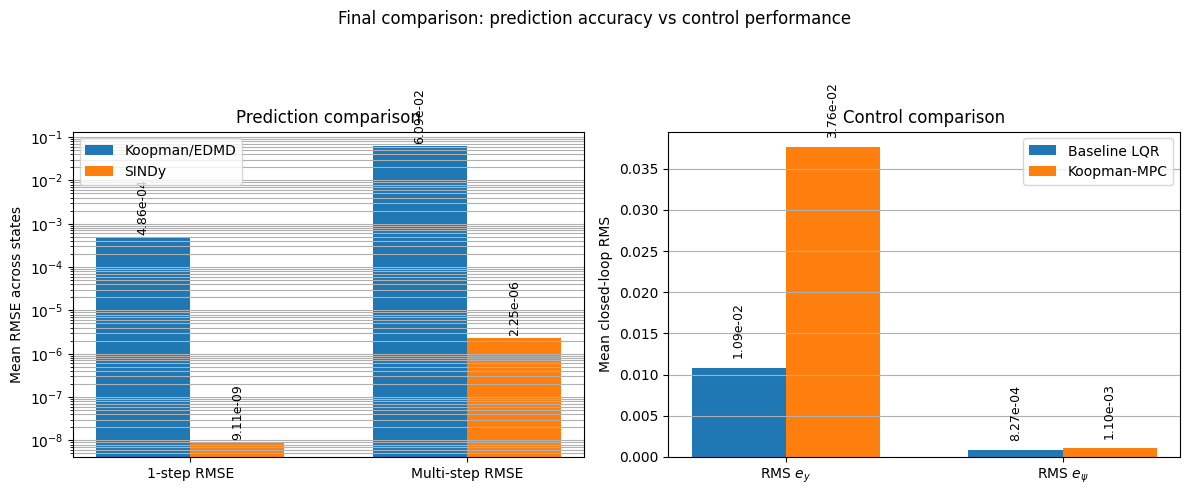

Final comparison figure created.
- saved figure: 16_final_comparison_plot.png

Takeaway:
- SINDy has lower prediction error than Koopman/EDMD.
- Baseline LQR has lower closed-loop tracking error than Koopman-MPC.
- Koopman/EDMD remains useful because it provides an MPC-friendly lifted linear model.


In [20]:
# ============================================================
# 16) Final comparison plot: prediction accuracy vs control performance
#
# This cell builds a single summary figure:
# - Left: predictor comparison (Koopman/EDMD vs SINDy)
# - Right: controller comparison (Baseline LQR vs Koopman-MPC)
#
# Saves:
#   results/figures/16_final_comparison_plot.png
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 0) Sanity checks
# ----------------------------
required = ["DIRS", "save_fig"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required objects in kernel: {missing}")

tables_dir = Path(DIRS["tables"])

pred_csv = tables_dir / "metrics_koopman_vs_sindy.csv"
ctrl_csv = tables_dir / "metrics_baseline_vs_koopman.csv"

if not pred_csv.exists():
    raise FileNotFoundError(f"Missing predictor comparison file: {pred_csv}")
if not ctrl_csv.exists():
    raise FileNotFoundError(f"Missing control comparison file: {ctrl_csv}")

df_pred = pd.read_csv(pred_csv)
df_ctrl = pd.read_csv(ctrl_csv)

# ----------------------------
# 1) Predictor summary
# ----------------------------
needed_pred = {
    "koopman_onestep_rmse",
    "sindy_onestep_rmse",
    "koopman_multistep_rmse",
    "sindy_multistep_rmse",
}
missing_pred = needed_pred - set(df_pred.columns)
if missing_pred:
    raise KeyError(f"Predictor table missing required columns: {missing_pred}")

pred_labels = ["1-step RMSE", "Multi-step RMSE"]
koopman_pred_vals = [
    float(df_pred["koopman_onestep_rmse"].mean()),
    float(df_pred["koopman_multistep_rmse"].mean()),
]
sindy_pred_vals = [
    float(df_pred["sindy_onestep_rmse"].mean()),
    float(df_pred["sindy_multistep_rmse"].mean()),
]

# ----------------------------
# 2) Controller summary
# ----------------------------
needed_ctrl = {"controller", "RMS_e_y_m", "RMS_e_psi_rad"}
missing_ctrl = needed_ctrl - set(df_ctrl.columns)
if missing_ctrl:
    raise KeyError(f"Control table missing required columns: {missing_ctrl}")

ctrl_group = df_ctrl.groupby("controller")[["RMS_e_y_m", "RMS_e_psi_rad"]].mean()

for ctrl_name in ["baseline_lqr", "koopman_mpc"]:
    if ctrl_name not in ctrl_group.index:
        raise KeyError(f"Controller {ctrl_name!r} not found in metrics_baseline_vs_koopman.csv")

control_labels = [r"RMS $e_y$", r"RMS $e_\psi$"]
baseline_ctrl_vals = [
    float(ctrl_group.loc["baseline_lqr", "RMS_e_y_m"]),
    float(ctrl_group.loc["baseline_lqr", "RMS_e_psi_rad"]),
]
koopman_ctrl_vals = [
    float(ctrl_group.loc["koopman_mpc", "RMS_e_y_m"]),
    float(ctrl_group.loc["koopman_mpc", "RMS_e_psi_rad"]),
]

# ----------------------------
# 3) Plot
# ----------------------------
fig = plt.figure(figsize=(12, 5))
w = 0.34

# Left panel: prediction comparison
ax1 = plt.subplot(1, 2, 1)
x1 = np.arange(len(pred_labels))

ax1.bar(x1 - w / 2, koopman_pred_vals, width=w, label="Koopman/EDMD")
ax1.bar(x1 + w / 2, sindy_pred_vals, width=w, label="SINDy")
ax1.set_xticks(x1)
ax1.set_xticklabels(pred_labels)
ax1.set_ylabel("Mean RMSE across states")
ax1.set_title("Prediction comparison")
ax1.set_yscale("log")
ax1.grid(True, axis="y", which="both")
ax1.legend()

for i, v in enumerate(koopman_pred_vals):
    ax1.text(i - w / 2, v * 1.15, f"{v:.2e}", ha="center", va="bottom", fontsize=9, rotation=90)
for i, v in enumerate(sindy_pred_vals):
    ax1.text(i + w / 2, v * 1.15, f"{v:.2e}", ha="center", va="bottom", fontsize=9, rotation=90)

# Right panel: control comparison
ax2 = plt.subplot(1, 2, 2)
x2 = np.arange(len(control_labels))

ax2.bar(x2 - w / 2, baseline_ctrl_vals, width=w, label="Baseline LQR")
ax2.bar(x2 + w / 2, koopman_ctrl_vals, width=w, label="Koopman-MPC")
ax2.set_xticks(x2)
ax2.set_xticklabels(control_labels)
ax2.set_ylabel("Mean closed-loop RMS")
ax2.set_title("Control comparison")
ax2.grid(True, axis="y")
ax2.legend()

offset = max(max(baseline_ctrl_vals), max(koopman_ctrl_vals)) * 0.03
for i, v in enumerate(baseline_ctrl_vals):
    ax2.text(i - w / 2, v + offset, f"{v:.2e}", ha="center", va="bottom", fontsize=9, rotation=90)
for i, v in enumerate(koopman_ctrl_vals):
    ax2.text(i + w / 2, v + offset, f"{v:.2e}", ha="center", va="bottom", fontsize=9, rotation=90)

plt.suptitle("Final comparison: prediction accuracy vs control performance")
plt.tight_layout(rect=[0, 0, 1, 0.93])
save_path = save_fig(fig, "16_final_comparison_plot.png")

if "register_artifact" in globals():
    register_artifact(save_path, "figure")

plt.show()
plt.close(fig)

print("Final comparison figure created.")
print(f"- saved figure: {save_path.name}")

print("\nTakeaway:")
print("- SINDy has lower prediction error than Koopman/EDMD.")
print("- Baseline LQR has lower closed-loop tracking error than Koopman-MPC.")
print("- Koopman/EDMD remains useful because it provides an MPC-friendly lifted linear model.")

The final summary figure makes the main conclusion of the notebook explicit. SINDy is the strongest learned predictor in both one-step and multi-step open-loop accuracy, while the baseline feedforward + LQR controller is the strongest tested controller in closed-loop tracking. Koopman/EDMD remains important because it provides a learned lifted linear model that is directly compatible with MPC design, even though it is not the best method here in either pure prediction accuracy or final control performance.

## 17) Final Results and Discussion

This notebook implemented a complete end-to-end pipeline:

**truth nonlinear vehicle model → data generation → Koopman/EDMD learning → constrained MPC → robustness evaluation → SINDy comparison**

The final results should be interpreted from three complementary viewpoints:

1. **closed-loop tracking performance**
2. **robustness across operating speeds**
3. **prediction quality of learned models**

---

### A) Closed-loop tracking performance

At the nominal operating condition, the classical **feedforward + LQR baseline** outperformed the tested Koopman-MPC controller in closed-loop tracking.

Across the evaluated nominal maneuvers, the baseline achieved lower RMS lateral error and lower RMS heading error than Koopman-MPC. Therefore, in this notebook, the learned Koopman controller did **not** surpass the classical baseline in final control performance.

This is an important engineering result: a learned model that is suitable for MPC formulation does not automatically produce better closed-loop behavior than a well-tuned classical controller.

---

### B) Generalization across speed

A robustness sweep was performed for

$$
V_x \in \{10,15,20,25\}\,\text{m/s}.
$$

The results show:

- **Baseline LQR** remained the strongest overall controller across the tested speeds and maneuvers.
- **Fixed-speed Koopman-MPC** degraded substantially as speed increased and failed badly at high speed.
- **Speed-aware Koopman-MPC** using the vx-augmented EDMD model did not solve the robustness problem and in fact performed substantially worse than baseline across the full sweep.

This highlights a key limitation of the learned controllers in this notebook:

> A model learned for prediction or local operation may not generalize reliably to broader operating conditions when used inside closed-loop control.

---

### C) Prediction capability of learned models

The learned predictors were compared in both one-step validation error and multi-step open-loop rollout error.

The main result is clear:

- **SINDy was the strongest predictor**
- **Koopman/EDMD was less accurate in pure prediction**
- **SINDy remained extremely accurate even in multi-step open-loop rollout on this deterministic simulated dataset**

Because the dataset is simulated, deterministic, noise-free, and well matched to the chosen sparse nonlinear feature library, SINDy had a strong advantage in pure prediction accuracy.

Thus, the notebook reveals an important distinction:

> the best predictor is not necessarily the best controller model.

---

### Overall findings

1. **The best tested controller was the classical feedforward + LQR baseline.**
2. **Koopman/EDMD provided a controller-friendly lifted linear model, but the resulting Koopman-MPC did not outperform baseline in this study.**
3. **The fixed-speed Koopman controller lacked robustness at higher speeds.**
4. **Adding speed as an input to EDMD was not sufficient, by itself, to obtain a robust speed-aware Koopman-MPC controller.**
5. **SINDy was the best learned predictor in both one-step and multi-step open-loop accuracy.**

---

### Main technical message

This notebook shows that **prediction accuracy**, **controller-oriented model structure**, and **closed-loop robustness** are different design objectives.

- **SINDy** was best for prediction accuracy.
- **Baseline feedforward + LQR** was best for closed-loop tracking and robustness.
- **Koopman/EDMD** remained valuable because it produced a learned lifted linear representation that could be embedded directly into MPC.

This is the central conclusion of the project:

> **best predictor** does not necessarily mean **best controller**.

---

### Future work

Promising next steps include:

- richer Koopman lifting dictionaries,
- better regularization and stabilization of learned lifted models,
- larger multi-speed training datasets,
- structured LPV or gain-scheduled Koopman models,
- and hybrid physics-informed plus data-driven learning approaches.

## 17) Final Results and Discussion

This notebook implemented a complete pipeline:

**truth nonlinear vehicle model** $\rightarrow$ **data generation** $\rightarrow$ **Koopman/EDMD model learning** $\rightarrow$ **constrained MPC design** $\rightarrow$ **robustness evaluation** $\rightarrow$ **SINDy-based model identification and comparison**.

The project therefore compared both:

- **controllers**: Baseline LQR, Koopman-MPC, and speed-aware Koopman-MPC
- **learned models**: EDMD and SINDy

---

### A) Nominal-speed closed-loop tracking

At the nominal operating condition, the classical **feedforward + LQR baseline** outperformed the tested Koopman-MPC controller.

The main tracking metric was

$$
\mathrm{RMS}(e_y)=\sqrt{\frac{1}{T}\sum_{k=0}^{T-1} e_y(k)^2}.
$$

Across the evaluated nominal maneuvers, the baseline achieved lower RMS lateral error and lower RMS heading error than Koopman-MPC. Therefore, in this study, the learned Koopman controller did **not** surpass the classical baseline in final closed-loop performance.

This is an important engineering result: a learned model that is convenient for MPC formulation does not automatically produce better closed-loop behavior than a well-tuned classical controller.

---

### B) Robustness across speed

A speed sweep was performed over

$$
V_x \in \{10,15,20,25\}\ \text{m/s}.
$$

The results showed three distinct behaviors:

- **Baseline LQR** remained the strongest overall controller across the tested speeds and maneuvers.
- **Fixed-speed Koopman-MPC** degraded substantially as speed increased and failed badly at high speed.
- **Speed-aware Koopman-MPC** using the vx-augmented EDMD model did not solve the robustness problem and in fact performed substantially worse than the baseline across the tested speed range.

This demonstrates that learned predictive controllers are highly sensitive to training coverage and model mismatch when operating conditions move away from the regime represented in the training data.

---

### C) EDMD vs SINDy for model prediction

In addition to control, we compared two data-driven modeling approaches.

#### EDMD

EDMD constructs a lifted linear predictor of the form

$$
z_{k+1}=A z_k + B u_k,
\qquad
x_k = C_{\mathrm{sel}} z_k.
$$

Its main strength is that it fits naturally into convex MPC because the prediction model is linear in lifted coordinates. This controller-friendly structure is the main reason it is attractive in the notebook.

#### SINDy

SINDy identifies a sparse nonlinear discrete-time predictor using a structured candidate library and sparse regression. In this project, SINDy was used as a **model discovery and prediction comparison tool**, not as the main controller model.

The final predictor comparison showed that:

- **SINDy achieved lower one-step validation RMSE than EDMD for all four states**
- **SINDy also achieved much lower multi-step rollout RMSE than EDMD**
- on this deterministic, noise-free simulated dataset, **SINDy was the strongest learned predictor in the notebook**

Thus, SINDy added major value by showing that the best pure predictor need not be the model that is most convenient for controller synthesis.

---

### D) Main takeaways

The main conclusions of the notebook are:

1. **The best tested controller was the classical feedforward + LQR baseline.**

2. **Koopman/EDMD provided a learned lifted linear model suitable for MPC formulation, but the resulting Koopman-MPC did not outperform the baseline controller in this study.**

3. **Generalization was the main weakness of the learned controllers.**  
   The fixed-speed Koopman controller degraded badly at high speed, and the vx-aware extension did not recover robust performance.

4. **SINDy was the strongest learned predictor** in both one-step and multi-step open-loop accuracy.

5. **Prediction accuracy, controller-friendly structure, and closed-loop robustness are different design objectives.**

---

### E) Final conclusion

This notebook shows that **data-driven vehicle lateral modeling and control** is feasible, but the best model depends on the engineering objective:

- **best predictor** $\rightarrow$ **SINDy**
- **best tested controller** $\rightarrow$ **Baseline feedforward + LQR**
- **most useful learned model structure for MPC formulation** $\rightarrow$ **Koopman/EDMD**

Overall, the project demonstrates that modern data-driven identification methods can be integrated into a complete control pipeline, while also making clear that **strong prediction accuracy alone does not guarantee the best closed-loop controller**, and that **training coverage is critical for robustness across operating conditions**.

## 20) Runtime and Solver-Time Comparison

Accuracy is not the only criterion that matters in control design. A controller may be accurate but too expensive to run online, or simple and fast but less flexible.

To make the project more practically grounded, we compare the computational cost of the main closed-loop controllers used in the notebook:

- **baseline feedforward + LQR**
- **Koopman-MPC**

### Why this section matters

This section adds an implementation-oriented perspective to the project.

The earlier sections focused on:

- tracking accuracy,
- prediction quality,
- robustness to speed variation,
- and robustness to measurement noise.

Here, we ask an additional question:

> how expensive is each control strategy to execute online?

This is especially relevant because one of the main motivations for Koopman/EDMD is that it enables an MPC formulation, while MPC typically incurs a higher computational cost than classical state-feedback control.

### What we compare

For each controller, we estimate the average per-step computation time over a representative closed-loop rollout.

We report:

- mean computation time per step,
- standard deviation across repeated runs,
- and maximum observed average step time.

### Interpretation goal

If Koopman-MPC is substantially slower than the baseline controller, then the project’s final trade-off becomes clearer:

- **baseline LQR** may remain preferable when simplicity and real-time efficiency matter most,
- while **Koopman-MPC** may still be attractive when a learned predictive model and constrained optimization framework are desired.

### Outputs

Saved artifacts:

- `results/tables/metrics_runtime_comparison.csv`
- `results/figures/20_runtime_comparison.png`

# Results & Discussion

This notebook implemented a complete end-to-end pipeline:

**truth nonlinear bicycle model** $\rightarrow$ **data generation** $\rightarrow$ **Koopman/EDMD learning** $\rightarrow$ **MPC design** $\rightarrow$ **closed-loop evaluation** $\rightarrow$ **robustness sweeps** $\rightarrow$ **SINDy identification and predictor comparison**.

The final results are best understood from four viewpoints:

1. nominal closed-loop tracking  
2. robustness across speed  
3. learned-model prediction accuracy  
4. overall engineering trade-offs  

---

## A) Nominal closed-loop tracking

The notebook compared two main controllers on the truth plant:

- **baseline feedforward + LQR**
- **Koopman-MPC**

At the nominal operating condition, the baseline controller achieved lower closed-loop tracking error than the tested Koopman-MPC controller.

Using RMS lateral error and RMS heading error as the main metrics, the results showed that:

- **Baseline LQR** produced smaller RMS($e_y$)
- **Baseline LQR** also produced competitive or smaller RMS($e_\psi$)
- **Koopman-MPC** remained feasible and constraint-aware, but it did not outperform the classical baseline

This is an important practical result. Even though Koopman/EDMD provides a learned lifted linear model suitable for MPC, that controller-friendly structure did **not** translate into the best closed-loop performance in this project.

---

## B) Robustness across speed

A speed sweep was performed over

$$
V_x \in \{10,\ 15,\ 20,\ 25\}\ \text{m/s}.
$$

The final robustness comparison showed:

- **baseline_lqr** was the best controller at **every tested speed**
- **koopman_fixed** degraded substantially as speed increased
- **koopman_vxaware** performed even worse across the sweep

This is one of the clearest conclusions of the notebook.

The fixed-speed Koopman controller was learned near a nominal operating condition, so its prediction quality and controller performance degraded when the system moved away from that training regime. The speed-aware extension, built by augmenting the EDMD input with \(V_x\), did not recover robust closed-loop performance.

Therefore, in this study:

> adding speed as an input to EDMD was **not sufficient** to produce a robust speed-aware Koopman-MPC controller.

---

## C) Prediction comparison: Koopman/EDMD vs SINDy

The notebook also compared the two learned predictors directly:

- **Koopman / EDMD**
- **SINDy**

The comparison used:

- **one-step validation RMSE**
- **multi-step open-loop rollout RMSE**

for the physical state

$$
x_k =
\begin{bmatrix}
e_y \\ e_\psi \\ v_y \\ r
\end{bmatrix}.
$$

The final predictor comparison showed that:

- **SINDy had lower one-step RMSE than Koopman/EDMD for all four states**
- **SINDy also had lower multi-step rollout RMSE for all four states**
- on this deterministic, noise-free simulated dataset, **SINDy was the strongest learned predictor in the notebook**

This result is believable because the truth model is simulated and clean, and the SINDy feature library is structurally well aligned with the underlying dynamics.

So, in pure prediction terms:

> **best predictor** = **SINDy**

---

## D) Main engineering interpretation

A central message of the notebook is that three goals are different:

1. **prediction accuracy**
2. **controller-friendly model structure**
3. **closed-loop robustness**

These goals did not align to the same method.

- **SINDy** was best for prediction accuracy
- **Baseline feedforward + LQR** was best for closed-loop tracking and robustness
- **Koopman/EDMD** remained valuable because it produced a learned lifted linear model that can be embedded directly into MPC

This distinction is important. A model that predicts best in open loop is not automatically the model that yields the best closed-loop controller.

---

## E) Final conclusions

The final conclusions of the project are:

1. **The strongest tested controller was the classical feedforward + LQR baseline.**

2. **Koopman/EDMD successfully produced a learned lifted linear model for MPC formulation, but the resulting Koopman-MPC did not outperform the baseline controller in this study.**

3. **Generalization across operating speed was the main weakness of the learned controllers.**

4. **The speed-aware EDMD extension did not solve the robustness problem and performed worse than the baseline across the tested speed range.**

5. **SINDy was the strongest learned predictor in both one-step and multi-step open-loop evaluation.**

---

## F) Final project takeaway

This notebook demonstrates that **data-driven vehicle lateral modeling and control** is feasible and informative, but the best method depends on the engineering objective:

- **best predictor** $\rightarrow$ **SINDy**
- **best tested controller** $\rightarrow$ **Baseline feedforward + LQR**
- **most useful learned model structure for MPC formulation** $\rightarrow$ **Koopman/EDMD**

So the most important final message is:

> **best predictor** does not necessarily mean **best controller**.

---

## G) Future work

Promising extensions include:

- richer Koopman lifting dictionaries,
- improved regularization and stabilization of lifted models,
- larger multi-speed datasets,
- structured LPV or gain-scheduled Koopman formulations,
- and hybrid physics-informed plus data-driven learning approaches.